In [2]:
# ============================================
# CELL 1: IMPORT LIBRARIES (FRENCH)
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error, r2_score, accuracy_score, classification_report, confusion_matrix

import shap
import warnings
warnings.filterwarnings('ignore')

# Set style for visualizations
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("viridis")

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

print("=" * 60)
print("📚 BIBLIOTHÈQUES IMPORTÉES AVEC SUCCÈS")
print("=" * 60)
print(f"✅ Pandas version: {pd.__version__}")
print(f"✅ NumPy version: {np.__version__}")
print(f"✅ Scikit-learn version: {sklearn.__version__}")
print(f"✅ SHAP version: {shap.__version__}")
print("=" * 60)
print("\n🚀 Prêt à générer le dataset français")
print("=" * 60)

📚 BIBLIOTHÈQUES IMPORTÉES AVEC SUCCÈS
✅ Pandas version: 2.3.3
✅ NumPy version: 2.3.5
✅ Scikit-learn version: 1.8.0
✅ SHAP version: 0.51.0

🚀 Prêt à générer le dataset français


In [37]:
# ============================================
# CELL 2: GÉNÉRATION DU DATASET FRANÇAIS
# Spécificité française: Pattern recognition > Langue
# Les étudiants qui réussissent sont ceux qui maîtrisent la structure de l'examen
# ============================================

import pandas as pd
import numpy as np

np.random.seed(42)
n_students = 500

print("=" * 60)
print("📚 GÉNÉRATION DU DATASET FRANÇAIS")
print(f"Nombre d'étudiants: {n_students}")
print("Spécificité: Pattern recognition > Maîtrise de la langue")
print("Moyenne cible: ~13/20")
print("=" * 60)

# ============================================
# STEP 1: Générer les compétences HIGH IMPORTANCE
# (Pattern recognition, compréhension, argumentation)
# ============================================

# Niveau de base (capacité à comprendre la structure de l'examen)
base_pattern = np.random.normal(6.5, 1.5, n_students)
base_pattern = np.clip(base_pattern, 3, 9.5)

# Compréhension (HIGH)
comprehension_textuelle = np.clip(base_pattern + np.random.normal(0, 0.7, n_students), 3, 10)
inference = np.clip(base_pattern + np.random.normal(0, 0.7, n_students), 3, 10)
true_false_justification = np.clip(base_pattern + np.random.normal(0, 0.7, n_students), 3, 10)
communicative_intent = np.clip(base_pattern + np.random.normal(0, 0.7, n_students), 3, 10)

# Argumentation (HIGH)
thesis_identification = np.clip(base_pattern + np.random.normal(0, 0.8, n_students), 3, 10)
argument_identification = np.clip(base_pattern + np.random.normal(0, 0.8, n_students), 3, 10)
concession_opposition = np.clip(base_pattern + np.random.normal(0, 0.8, n_students), 2, 10)

# Production écrite (HIGH - structure)
essay_structure = np.clip(base_pattern + np.random.normal(0, 0.9, n_students), 2, 10)
language_accuracy = np.clip(base_pattern + np.random.normal(0, 0.8, n_students), 3, 10)

# Types de textes (HIGH)
historical_text = np.clip(base_pattern + np.random.normal(0, 0.7, n_students), 3, 10)
argumentative_text = np.clip(base_pattern + np.random.normal(0, 0.7, n_students), 3, 10)

# ============================================
# STEP 2: Générer les compétences MEDIUM IMPORTANCE
# ============================================

# Niveau de base pour les compétences moyennes (plus de bruit)
base_medium = np.random.normal(6, 1.5, n_students)
base_medium = np.clip(base_medium, 3, 9)

reference_tracking = np.clip(base_medium + np.random.normal(0, 1.0, n_students), 2, 10)
lexical_analysis = np.clip(base_medium + np.random.normal(0, 1.0, n_students), 2, 10)
critical_reasoning = np.clip(base_medium + np.random.normal(0, 1.0, n_students), 2, 10)
coherence_cohesion = np.clip(base_medium + np.random.normal(0, 1.0, n_students), 2, 10)

# ============================================
# STEP 3: Générer les compétences LOW IMPORTANCE
# (Presque aléatoires, peu de lien avec le BAC)
# ============================================

essays_per_week = np.random.choice([0,1,2,3,4,5], n_students, p=[0.1,0.15,0.25,0.25,0.15,0.1])
texts_analyzed_per_week = np.random.poisson(2, n_students)
texts_analyzed_per_week = np.clip(texts_analyzed_per_week, 0, 8)
stress = np.random.choice([1,2,3,4,5], n_students, p=[0.05,0.1,0.25,0.35,0.25])

# ============================================
# STEP 4: Générer les compétences liées à la pratique
# (Très importantes - pattern recognition)
# ============================================

bac_exams_practiced = np.random.poisson(8, n_students)  # Plus d'examens résolus
bac_exams_practiced = np.clip(bac_exams_practiced, 0, 25)
confidence = np.random.choice([1,2,3,4,5], n_students, p=[0.05,0.1,0.3,0.35,0.2])

# ============================================
# STEP 5: Scores dérivés
# ============================================

comprehension_score = (comprehension_textuelle + inference + true_false_justification + communicative_intent) / 4
argumentation_score = (thesis_identification + argument_identification + concession_opposition) / 3
writing_score = (essay_structure + language_accuracy) / 2
text_type_score = (historical_text + argumentative_text) / 2
practice_intensity = (bac_exams_practiced / 25) * 10  # Normalisé sur 10

# ============================================
# STEP 6: Filière
# ============================================

filiere = np.random.choice([0, 1, 2], n_students, p=[0.5, 0.3, 0.2])

# ============================================
# STEP 7: Calculer la note du BAC
# POIDS: Pattern recognition (70%) + Pratique (20%) + Langue (10%)
# ============================================

# Pattern recognition (70% du BAC)
pattern_score = (comprehension_textuelle + inference + true_false_justification + 
                 communicative_intent + thesis_identification + argument_identification + 
                 concession_opposition + essay_structure + historical_text + argumentative_text) / 10

# Pratique (20% du BAC)
practice_score = (bac_exams_practiced / 25) * 10

# Langue (10% du BAC)
language_score = (reference_tracking + lexical_analysis + critical_reasoning + coherence_cohesion + language_accuracy) / 5

# Note de base (0-10)
bac_score_base = pattern_score * 0.70 + practice_score * 0.20 + language_score * 0.10

# Ajustement selon la filière
sci_mask = (filiere == 0)
non_sci_mask = (filiere != 0)

bac_score_final = np.zeros(n_students)
bac_score_final[sci_mask] = bac_score_base[sci_mask] * 2  # Sciences: note standard
bac_score_final[non_sci_mask] = bac_score_base[non_sci_mask] * 2 * 0.95  # Lettres: plus difficile

# Ajouter un petit boost pour la confiance
bac_score_final = bac_score_final + (confidence - 3) * 0.1

# ============================================
# STEP 8: Ajuster la distribution
# ============================================

# Ajuster la moyenne à 13
current_mean = bac_score_final.mean()
bac_score_final = bac_score_final * (13.0 / current_mean)

# Ajuster l'écart-type
bac_score_final = (bac_score_final - bac_score_final.mean()) * 2.5 / bac_score_final.std() + bac_score_final.mean()

# Aucune note <9
bac_score_final = np.clip(bac_score_final, 9, 19)

# S'assurer que ~5% des notes sont <10
low_count = (bac_score_final < 10).sum()
target_low = int(n_students * 0.05)

if low_count > target_low:
    excess = low_count - target_low
    low_indices = np.where(bac_score_final < 10)[0]
    np.random.shuffle(low_indices)
    for idx in low_indices[:excess]:
        bac_score_final[idx] = np.random.uniform(10, 11)

bac_score = np.round(bac_score_final, 1)

# ============================================
# STEP 9: Générer les notes des trimestres
# ============================================

grade_t1 = bac_score + np.random.normal(-0.5, 1.0, n_students)
grade_t2 = bac_score + np.random.normal(0, 0.9, n_students)
grade_t3 = bac_score + np.random.normal(0.5, 0.8, n_students)

grade_t1 = np.clip(grade_t1, 9, 19)
grade_t2 = np.clip(grade_t2, 9, 19)
grade_t3 = np.clip(grade_t3, 9, 19)

grade_t1 = np.round(grade_t1, 1)
grade_t2 = np.round(grade_t2, 1)
grade_t3 = np.round(grade_t3, 1)

avg_grade = (grade_t1 + grade_t2 + grade_t3) / 3
avg_grade = np.round(avg_grade, 1)

# ============================================
# Arrondir toutes les compétences
# ============================================

comprehension_textuelle = np.round(comprehension_textuelle, 1)
inference = np.round(inference, 1)
true_false_justification = np.round(true_false_justification, 1)
communicative_intent = np.round(communicative_intent, 1)
thesis_identification = np.round(thesis_identification, 1)
argument_identification = np.round(argument_identification, 1)
concession_opposition = np.round(concession_opposition, 1)
essay_structure = np.round(essay_structure, 1)
language_accuracy = np.round(language_accuracy, 1)
historical_text = np.round(historical_text, 1)
argumentative_text = np.round(argumentative_text, 1)
reference_tracking = np.round(reference_tracking, 1)
lexical_analysis = np.round(lexical_analysis, 1)
critical_reasoning = np.round(critical_reasoning, 1)
coherence_cohesion = np.round(coherence_cohesion, 1)

# ============================================
# Création du DataFrame
# ============================================

df = pd.DataFrame({
    'grade_t1': grade_t1,
    'grade_t2': grade_t2,
    'grade_t3': grade_t3,
    'avg_grade': avg_grade,
    'comprehension_textuelle': comprehension_textuelle,
    'inference': inference,
    'true_false_justification': true_false_justification,
    'communicative_intent': communicative_intent,
    'thesis_identification': thesis_identification,
    'argument_identification': argument_identification,
    'concession_opposition': concession_opposition,
    'essay_structure': essay_structure,
    'language_accuracy': language_accuracy,
    'historical_text': historical_text,
    'argumentative_text': argumentative_text,
    'reference_tracking': reference_tracking,
    'lexical_analysis': lexical_analysis,
    'critical_reasoning': critical_reasoning,
    'coherence_cohesion': coherence_cohesion,
    'bac_exams_practiced': bac_exams_practiced,
    'confidence': confidence,
    'essays_per_week': essays_per_week,
    'texts_analyzed_per_week': texts_analyzed_per_week,
    'stress': stress,
    'filiere': filiere,
    'comprehension_score': np.round(comprehension_score, 2),
    'argumentation_score': np.round(argumentation_score, 2),
    'writing_score': np.round(writing_score, 2),
    'text_type_score': np.round(text_type_score, 2),
    'practice_intensity': np.round(practice_intensity, 1),
    'bac_score': bac_score
})

print("\n✅ Dataset généré avec succès!")
print(f"   Étudiants: {df.shape[0]}")
print(f"   Caractéristiques: {df.shape[1]}")
print(f"\n📊 Statistiques de la note du BAC:")
print(f"   Moyenne: {df['bac_score'].mean():.2f}/20")
print(f"   Médiane: {df['bac_score'].median():.2f}/20")
print(f"   Écart-type: {df['bac_score'].std():.2f}")
print(f"   Minimum: {df['bac_score'].min():.1f}/20")
print(f"   Maximum: {df['bac_score'].max():.1f}/20")

print("\n📊 Distribution des notes du BAC:")
print(f"   9-10:   {((df['bac_score'] >= 9) & (df['bac_score'] < 11)).sum()} étudiants")
print(f"   11-12:  {((df['bac_score'] >= 11) & (df['bac_score'] < 13)).sum()} étudiants")
print(f"   13-14:  {((df['bac_score'] >= 13) & (df['bac_score'] < 15)).sum()} étudiants")
print(f"   15-16:  {((df['bac_score'] >= 15) & (df['bac_score'] < 17)).sum()} étudiants")
print(f"   17-19:  {(df['bac_score'] >= 17).sum()} étudiants")

print(f"\n📊 Étudiants avec note <10: {(df['bac_score'] < 10).sum()} ({(df['bac_score'] < 10).sum()/len(df)*100:.1f}%)")
print(f"📊 Taux de réussite (≥10/20): {(df['bac_score'] >= 10).mean() * 100:.1f}%")

print("\n📊 Corrélations avec la note du BAC:")
print(f"   bac_exams_practiced: {df['bac_score'].corr(df['bac_exams_practiced']):.3f} (devrait être élevée)")
print(f"   comprehension_textuelle: {df['bac_score'].corr(df['comprehension_textuelle']):.3f}")
print(f"   thesis_identification: {df['bac_score'].corr(df['thesis_identification']):.3f}")
print(f"   reference_tracking: {df['bac_score'].corr(df['reference_tracking']):.3f} (devrait être plus faible)")

print("\n📊 Premières lignes:")
print(df.head())

📚 GÉNÉRATION DU DATASET FRANÇAIS
Nombre d'étudiants: 500
Spécificité: Pattern recognition > Maîtrise de la langue
Moyenne cible: ~13/20

✅ Dataset généré avec succès!
   Étudiants: 500
   Caractéristiques: 31

📊 Statistiques de la note du BAC:
   Moyenne: 13.12/20
   Médiane: 13.00/20
   Écart-type: 2.30
   Minimum: 9.0/20
   Maximum: 19.0/20

📊 Distribution des notes du BAC:
   9-10:   108 étudiants
   11-12:  139 étudiants
   13-14:  141 étudiants
   15-16:  78 étudiants
   17-19:  34 étudiants

📊 Étudiants avec note <10: 24 (4.8%)
📊 Taux de réussite (≥10/20): 95.2%

📊 Corrélations avec la note du BAC:
   bac_exams_practiced: 0.260 (devrait être élevée)
   comprehension_textuelle: 0.848
   thesis_identification: 0.841
   reference_tracking: 0.066 (devrait être plus faible)

📊 Premières lignes:
   grade_t1  grade_t2  grade_t3  avg_grade  comprehension_textuelle  inference  true_false_justification  communicative_intent  thesis_identification  argument_identification  concession_opposi

In [38]:
# ============================================
# CELL 3: SAUVEGARDER LE DATASET FRANÇAIS
# ============================================

# Save the dataset to CSV file
csv_filename = 'french_bac_dataset.csv'

df.to_csv(csv_filename, index=False)

print("=" * 60)
print("💾 DATASET SAUVEGARDÉ AVEC SUCCÈS")
print("=" * 60)
print(f"   Fichier: {csv_filename}")
print(f"   Étudiants: {df.shape[0]}")
print(f"   Caractéristiques: {df.shape[1]}")
print("=" * 60)

# Display file size
import os
file_size = os.path.getsize(csv_filename)
print(f"   Taille du fichier: {file_size / 1024:.2f} KB")
print("=" * 60)

print("\n📊 Aperçu des 3 premières lignes sauvegardées:")
print(df.head(3))

💾 DATASET SAUVEGARDÉ AVEC SUCCÈS
   Fichier: french_bac_dataset.csv
   Étudiants: 500
   Caractéristiques: 31
   Taille du fichier: 59.88 KB

📊 Aperçu des 3 premières lignes sauvegardées:
   grade_t1  grade_t2  grade_t3  avg_grade  comprehension_textuelle  inference  true_false_justification  communicative_intent  thesis_identification  argument_identification  concession_opposition  essay_structure  language_accuracy  historical_text  argumentative_text  reference_tracking  lexical_analysis  critical_reasoning  coherence_cohesion  bac_exams_practiced  confidence  essays_per_week  texts_analyzed_per_week  stress  filiere  comprehension_score  argumentation_score  writing_score  text_type_score  practice_intensity  bac_score
0      14.5      15.1      15.7       15.1                      7.9        8.2                       7.8                   6.8                    7.7                      5.7                    8.2              6.5                6.5              6.9                

In [3]:
# ============================================
# CELL 4: CHARGER LE DATASET FRANÇAIS
# ============================================

# Load the dataset from CSV file
csv_filename = 'french_bac_dataset.csv'

df = pd.read_csv(csv_filename)

print("=" * 60)
print("📂 DATASET CHARGÉ AVEC SUCCÈS")
print("=" * 60)
print(f"   Fichier: {csv_filename}")
print(f"   Étudiants: {df.shape[0]}")
print(f"   Caractéristiques: {df.shape[1]}")
print("=" * 60)

print("\n📊 Statistiques rapides:")
print(f"   Note BAC - Moyenne: {df['bac_score'].mean():.2f}/20")
print(f"   Note BAC - Min: {df['bac_score'].min():.1f}/20")
print(f"   Note BAC - Max: {df['bac_score'].max():.1f}/20")
print(f"   Note BAC - Écart-type: {df['bac_score'].std():.2f}")

print("\n📊 Premières 3 lignes:")
print(df.head(3))

print("\n📊 Noms des colonnes:")
print(df.columns.tolist())

📂 DATASET CHARGÉ AVEC SUCCÈS
   Fichier: french_bac_dataset.csv
   Étudiants: 500
   Caractéristiques: 31

📊 Statistiques rapides:
   Note BAC - Moyenne: 13.12/20
   Note BAC - Min: 9.0/20
   Note BAC - Max: 19.0/20
   Note BAC - Écart-type: 2.30

📊 Premières 3 lignes:
   grade_t1  grade_t2  grade_t3  avg_grade  comprehension_textuelle  inference  true_false_justification  communicative_intent  thesis_identification  argument_identification  concession_opposition  essay_structure  language_accuracy  historical_text  argumentative_text  reference_tracking  lexical_analysis  critical_reasoning  coherence_cohesion  bac_exams_practiced  confidence  essays_per_week  texts_analyzed_per_week  stress  filiere  comprehension_score  argumentation_score  writing_score  text_type_score  practice_intensity  bac_score
0      14.5      15.1      15.7       15.1                      7.9        8.2                       7.8                   6.8                    7.7                      5.7          

In [40]:
# ============================================
# CELL 5: EDA - APERÇU GLOBAL DU DATASET
# ============================================

print("=" * 60)
print("📊 ANALYSE EXPLORATOIRE - APERÇU GLOBAL")
print("=" * 60)

# 1. Premières lignes
print("\n📋 PREMIÈRES 5 LIGNES:")
print(df.head())

# 2. Dernières lignes
print("\n📋 DERNIÈRES 5 LIGNES:")
print(df.tail())

# 3. Informations générales
print("\n📋 INFORMATIONS GÉNÉRALES:")
print(df.info())

# 4. Statistiques descriptives
print("\n📋 STATISTIQUES DESCRIPTIVES:")
print(df.describe().round(2))

# 5. Vérification des valeurs manquantes
print("\n📋 VALEURS MANQUANTES:")
missing = df.isnull().sum().sum()
if missing == 0:
    print("   ✅ Aucune valeur manquante")
else:
    print(f"   ⚠️ {missing} valeurs manquantes")

# 6. Vérification des doublons
print("\n📋 DOUBLONS:")
duplicates = df.duplicated().sum()
if duplicates == 0:
    print("   ✅ Aucun doublon")
else:
    print(f"   ⚠️ {duplicates} doublons")

# 7. Types de données
print("\n📋 TYPES DE DONNÉES:")
print(df.dtypes.value_counts())

# 8. Dimensions
print("\n📋 DIMENSIONS:")
print(f"   Lignes: {df.shape[0]}")
print(f"   Colonnes: {df.shape[1]}")

print("\n" + "=" * 60)
print("✅ APERÇU GLOBAL TERMINÉ")
print("=" * 60)

📊 ANALYSE EXPLORATOIRE - APERÇU GLOBAL

📋 PREMIÈRES 5 LIGNES:
   grade_t1  grade_t2  grade_t3  avg_grade  comprehension_textuelle  inference  true_false_justification  communicative_intent  thesis_identification  argument_identification  concession_opposition  essay_structure  language_accuracy  historical_text  argumentative_text  reference_tracking  lexical_analysis  critical_reasoning  coherence_cohesion  bac_exams_practiced  confidence  essays_per_week  texts_analyzed_per_week  stress  filiere  comprehension_score  argumentation_score  writing_score  text_type_score  practice_intensity  bac_score
0      14.5      15.1      15.7       15.1                      7.9        8.2                       7.8                   6.8                    7.7                      5.7                    8.2              6.5                6.5              6.9                 7.7                 5.6               5.1                 6.1                 4.3                    9           5           

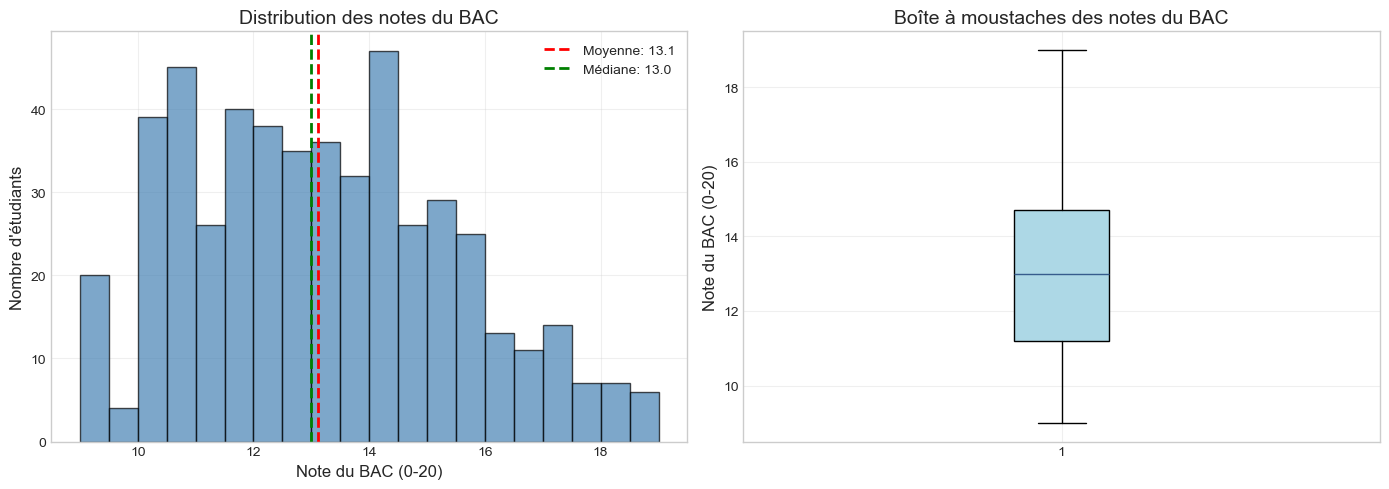


📊 STATISTIQUES DE LA NOTE DU BAC
   Moyenne:     13.12
   Médiane:     13.00
   Écart-type:  2.30
   Minimum:     9.0
   Maximum:     19.0
   Quartile 1:  11.20
   Quartile 3:  14.70

📊 DISTRIBUTION PAR TRANCHES:
   8-10:   108 étudiants (21.6%)
   11-12:  139 étudiants (27.8%)
   13-14:  141 étudiants (28.2%)
   15-16:  78 étudiants (15.6%)
   17-19:  34 étudiants (6.8%)

📊 TAUX DE RÉUSSITE (≥10/20): 95.2%

✅ DISTRIBUTION TERMINÉE


In [41]:
# ============================================
# CELL 6: EDA - DISTRIBUTION DE LA NOTE DU BAC
# ============================================

import matplotlib.pyplot as plt
import seaborn as sns

# Créer la figure avec 2 graphiques
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Graphique 1: Histogramme
axes[0].hist(df['bac_score'], bins=20, edgecolor='black', color='steelblue', alpha=0.7)
axes[0].axvline(df['bac_score'].mean(), color='red', linestyle='dashed', linewidth=2, 
                label=f'Moyenne: {df["bac_score"].mean():.1f}')
axes[0].axvline(df['bac_score'].median(), color='green', linestyle='dashed', linewidth=2, 
                label=f'Médiane: {df["bac_score"].median():.1f}')
axes[0].set_xlabel('Note du BAC (0-20)', fontsize=12)
axes[0].set_ylabel('Nombre d\'étudiants', fontsize=12)
axes[0].set_title('Distribution des notes du BAC', fontsize=14)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Graphique 2: Boxplot
boxplot = axes[1].boxplot(df['bac_score'], vert=True, patch_artist=True)
boxplot['boxes'][0].set_facecolor('lightblue')
axes[1].set_ylabel('Note du BAC (0-20)', fontsize=12)
axes[1].set_title('Boîte à moustaches des notes du BAC', fontsize=14)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Statistiques détaillées
print("\n" + "=" * 60)
print("📊 STATISTIQUES DE LA NOTE DU BAC")
print("=" * 60)
print(f"   Moyenne:     {df['bac_score'].mean():.2f}")
print(f"   Médiane:     {df['bac_score'].median():.2f}")
print(f"   Écart-type:  {df['bac_score'].std():.2f}")
print(f"   Minimum:     {df['bac_score'].min():.1f}")
print(f"   Maximum:     {df['bac_score'].max():.1f}")
print(f"   Quartile 1:  {df['bac_score'].quantile(0.25):.2f}")
print(f"   Quartile 3:  {df['bac_score'].quantile(0.75):.2f}")

# Distribution par tranches
print("\n📊 DISTRIBUTION PAR TRANCHES:")
print(f"   8-10:   {((df['bac_score'] >= 8) & (df['bac_score'] < 11)).sum()} étudiants ({((df['bac_score'] >= 8) & (df['bac_score'] < 11)).sum()/len(df)*100:.1f}%)")
print(f"   11-12:  {((df['bac_score'] >= 11) & (df['bac_score'] < 13)).sum()} étudiants ({((df['bac_score'] >= 11) & (df['bac_score'] < 13)).sum()/len(df)*100:.1f}%)")
print(f"   13-14:  {((df['bac_score'] >= 13) & (df['bac_score'] < 15)).sum()} étudiants ({((df['bac_score'] >= 13) & (df['bac_score'] < 15)).sum()/len(df)*100:.1f}%)")
print(f"   15-16:  {((df['bac_score'] >= 15) & (df['bac_score'] < 17)).sum()} étudiants ({((df['bac_score'] >= 15) & (df['bac_score'] < 17)).sum()/len(df)*100:.1f}%)")
print(f"   17-19:  {(df['bac_score'] >= 17).sum()} étudiants ({(df['bac_score'] >= 17).sum()/len(df)*100:.1f}%)")

# Taux de réussite (>=10/20)
success_rate = (df['bac_score'] >= 10).mean() * 100
print(f"\n📊 TAUX DE RÉUSSITE (≥10/20): {success_rate:.1f}%")

print("\n" + "=" * 60)
print("✅ DISTRIBUTION TERMINÉE")
print("=" * 60)


📊 CORRÉLATION AVEC LA NOTE DU BAC
(Du plus corrélé au moins corrélé)
----------------------------------------
   bac_score                     : 1.000
   avg_grade                     : 0.975
   grade_t3                      : 0.947
   grade_t2                      : 0.934
   comprehension_score           : 0.924
   grade_t1                      : 0.919
   argumentation_score           : 0.911
   text_type_score               : 0.906
   writing_score                 : 0.890
   argumentative_text            : 0.872
   true_false_justification      : 0.863
   communicative_intent          : 0.860
   historical_text               : 0.850
   comprehension_textuelle       : 0.848
   inference                     : 0.845
   thesis_identification         : 0.841
   concession_opposition         : 0.835
   language_accuracy             : 0.835
   essay_structure               : 0.821
   argument_identification       : 0.815
   practice_intensity            : 0.260
   bac_exams_practiced      

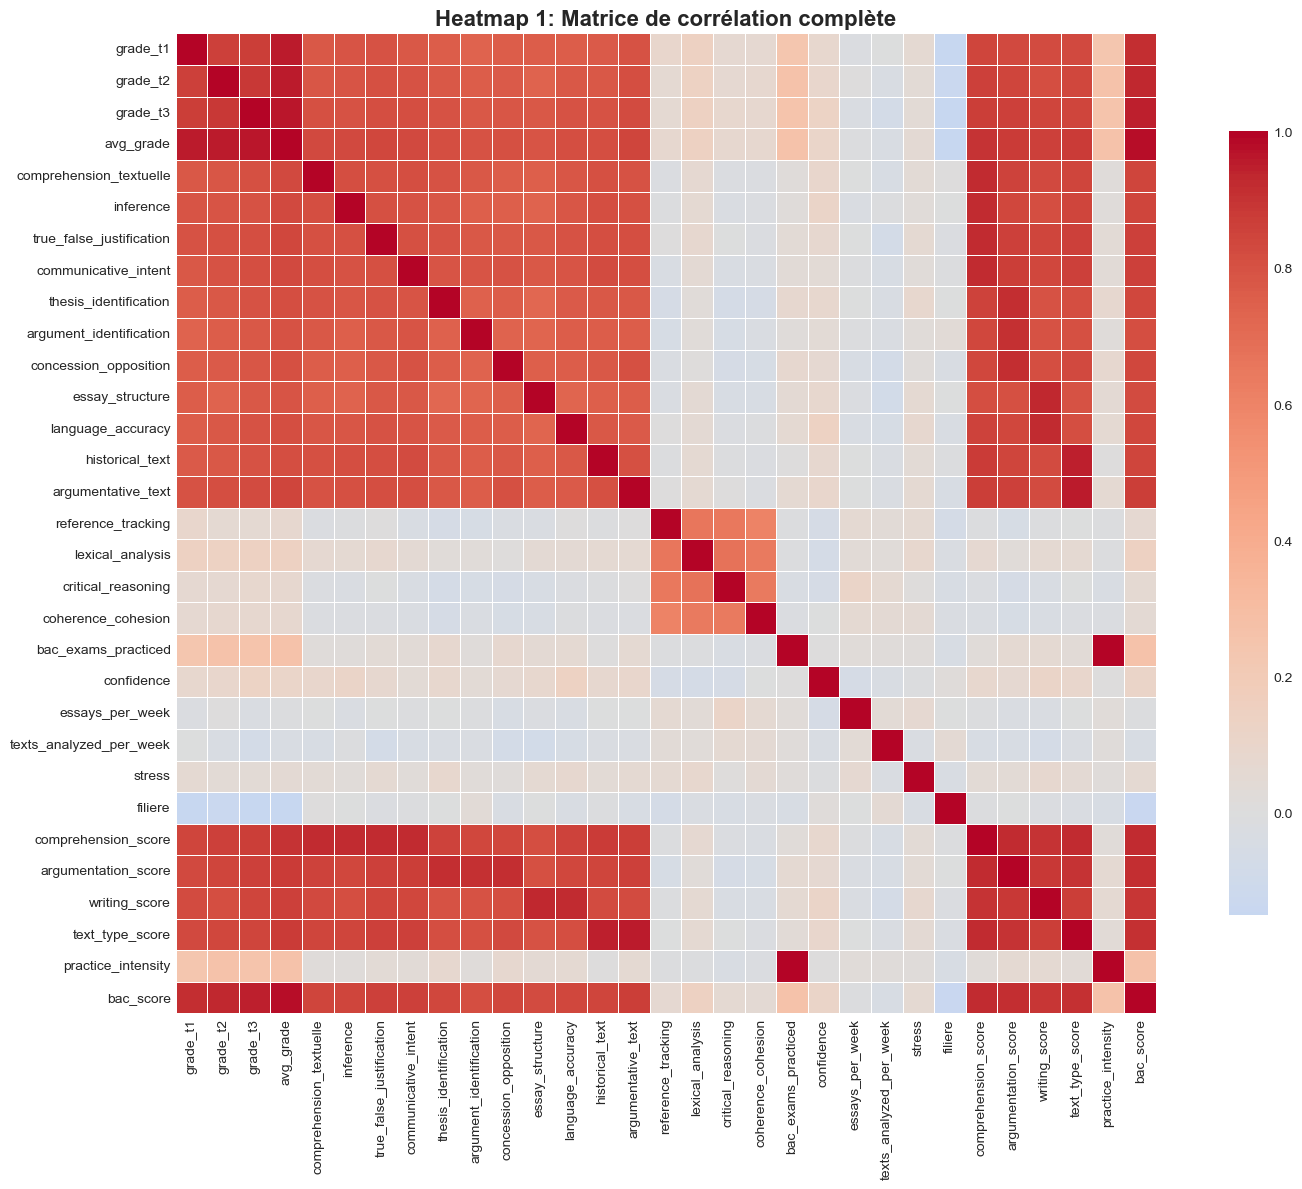


📊 HEATMAP 2: Top 15 features corrélées avec la note du BAC


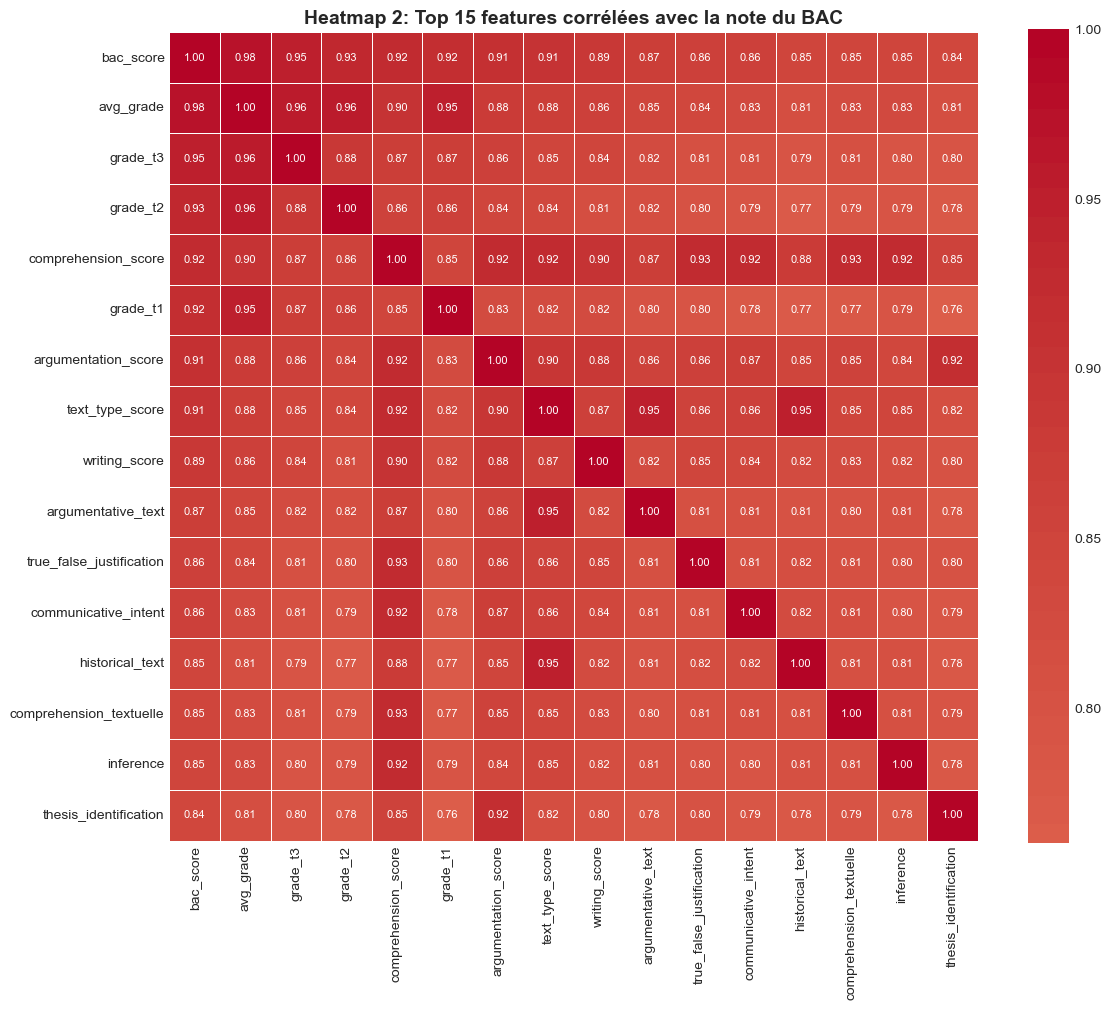


📊 HEATMAP 3: Features restantes (faible corrélation avec le BAC)


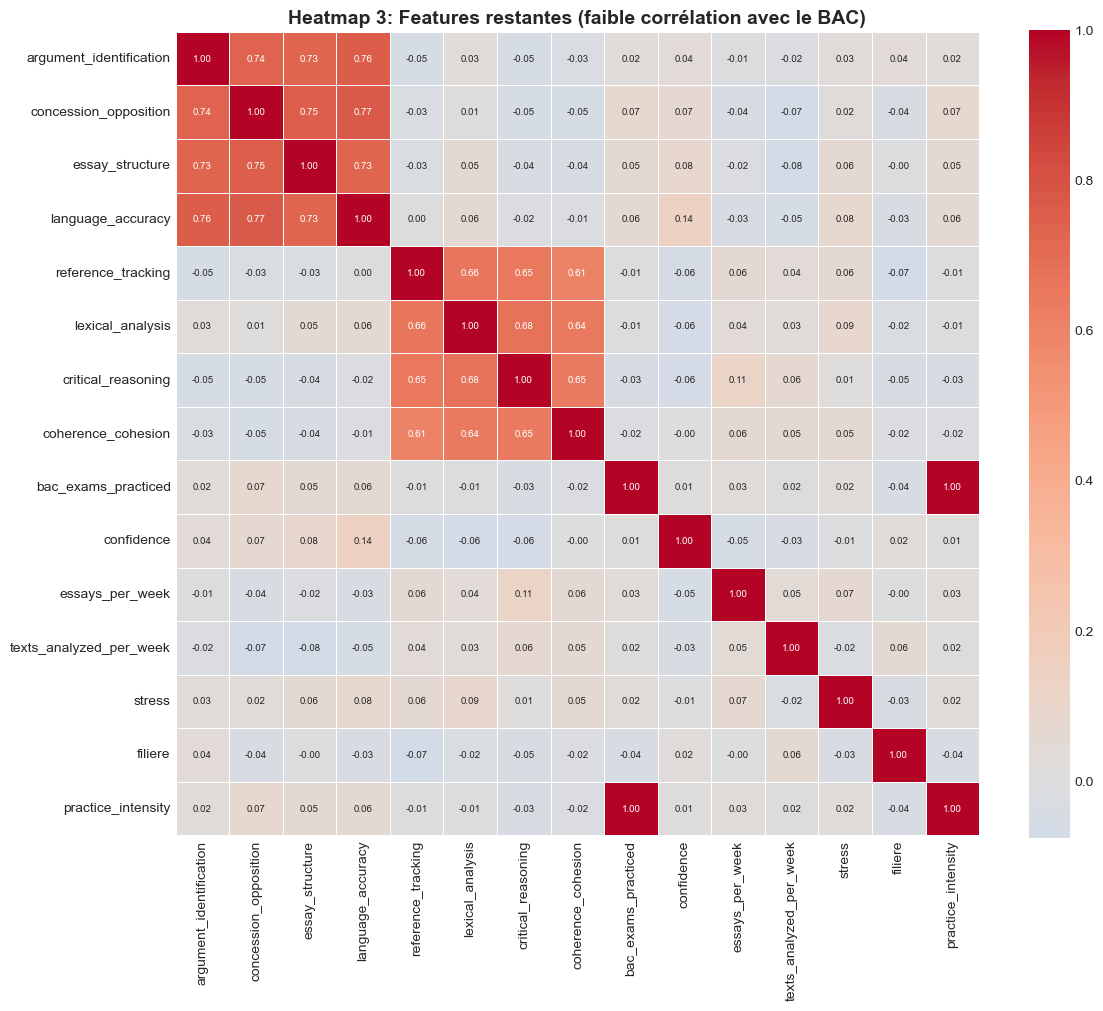


📋 Features restantes (15 features):
   • argument_identification: corrélation = 0.815
   • concession_opposition: corrélation = 0.835
   • essay_structure: corrélation = 0.821
   • language_accuracy: corrélation = 0.835
   • reference_tracking: corrélation = 0.066
   • lexical_analysis: corrélation = 0.143
   • critical_reasoning: corrélation = 0.057
   • coherence_cohesion: corrélation = 0.051
   • bac_exams_practiced: corrélation = 0.260
   • confidence: corrélation = 0.117
   • essays_per_week: corrélation = -0.008
   • texts_analyzed_per_week: corrélation = -0.039
   • stress: corrélation = 0.058
   • filiere: corrélation = -0.144
   • practice_intensity: corrélation = 0.260

✅ MATRICES DE CORRÉLATION TERMINÉES


In [42]:
# ============================================
# CELL 7: EDA - MATRICES DE CORRÉLATION
# ============================================

import matplotlib.pyplot as plt
import seaborn as sns

# Sélectionner uniquement les colonnes numériques
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
corr_matrix = df[numeric_cols].corr()

# Corrélation avec la note du BAC
bac_corr = corr_matrix['bac_score'].sort_values(ascending=False)
print("\n" + "=" * 60)
print("📊 CORRÉLATION AVEC LA NOTE DU BAC")
print("=" * 60)
print("(Du plus corrélé au moins corrélé)")
print("-" * 40)
for feature, corr_value in bac_corr.items():
    print(f"   {feature:30s}: {corr_value:.3f}")

# ============================================
# HEATMAP 1: Toutes les features
# ============================================
plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, 
            annot=False, 
            cmap='coolwarm', 
            center=0,
            square=True,
            linewidths=0.5,
            cbar_kws={"shrink": 0.8})
plt.title('Heatmap 1: Matrice de corrélation complète', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================
# HEATMAP 2: Top 15 features corrélées avec le BAC
# ============================================
print("\n" + "=" * 60)
print("📊 HEATMAP 2: Top 15 features corrélées avec la note du BAC")
print("=" * 60)

# Prendre les 15 meilleures features (incluant bac_score elle-même)
top_features = bac_corr.head(16).index.tolist()
corr_top = df[top_features].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_top, 
            annot=True, 
            cmap='coolwarm', 
            center=0,
            square=True,
            fmt='.2f',
            linewidths=0.5,
            annot_kws={'size': 8})
plt.title('Heatmap 2: Top 15 features corrélées avec la note du BAC', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================
# HEATMAP 3: Features restantes (faible corrélation)
# ============================================
print("\n" + "=" * 60)
print("📊 HEATMAP 3: Features restantes (faible corrélation avec le BAC)")
print("=" * 60)

top_feature_names = bac_corr.head(16).index.tolist()
remaining_features = [f for f in numeric_cols if f not in top_feature_names and f != 'bac_score']

if len(remaining_features) > 0:
    corr_remaining = df[remaining_features].corr()
    
    plt.figure(figsize=(12, 10))
    sns.heatmap(corr_remaining, 
                annot=True, 
                cmap='coolwarm', 
                center=0,
                square=True,
                fmt='.2f',
                linewidths=0.5,
                annot_kws={'size': 7})
    plt.title('Heatmap 3: Features restantes (faible corrélation avec le BAC)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    print(f"\n📋 Features restantes ({len(remaining_features)} features):")
    for f in remaining_features:
        print(f"   • {f}: corrélation = {bac_corr[f]:.3f}")
else:
    print("   Aucune feature restante à afficher")

print("\n" + "=" * 60)
print("✅ MATRICES DE CORRÉLATION TERMINÉES")
print("=" * 60)

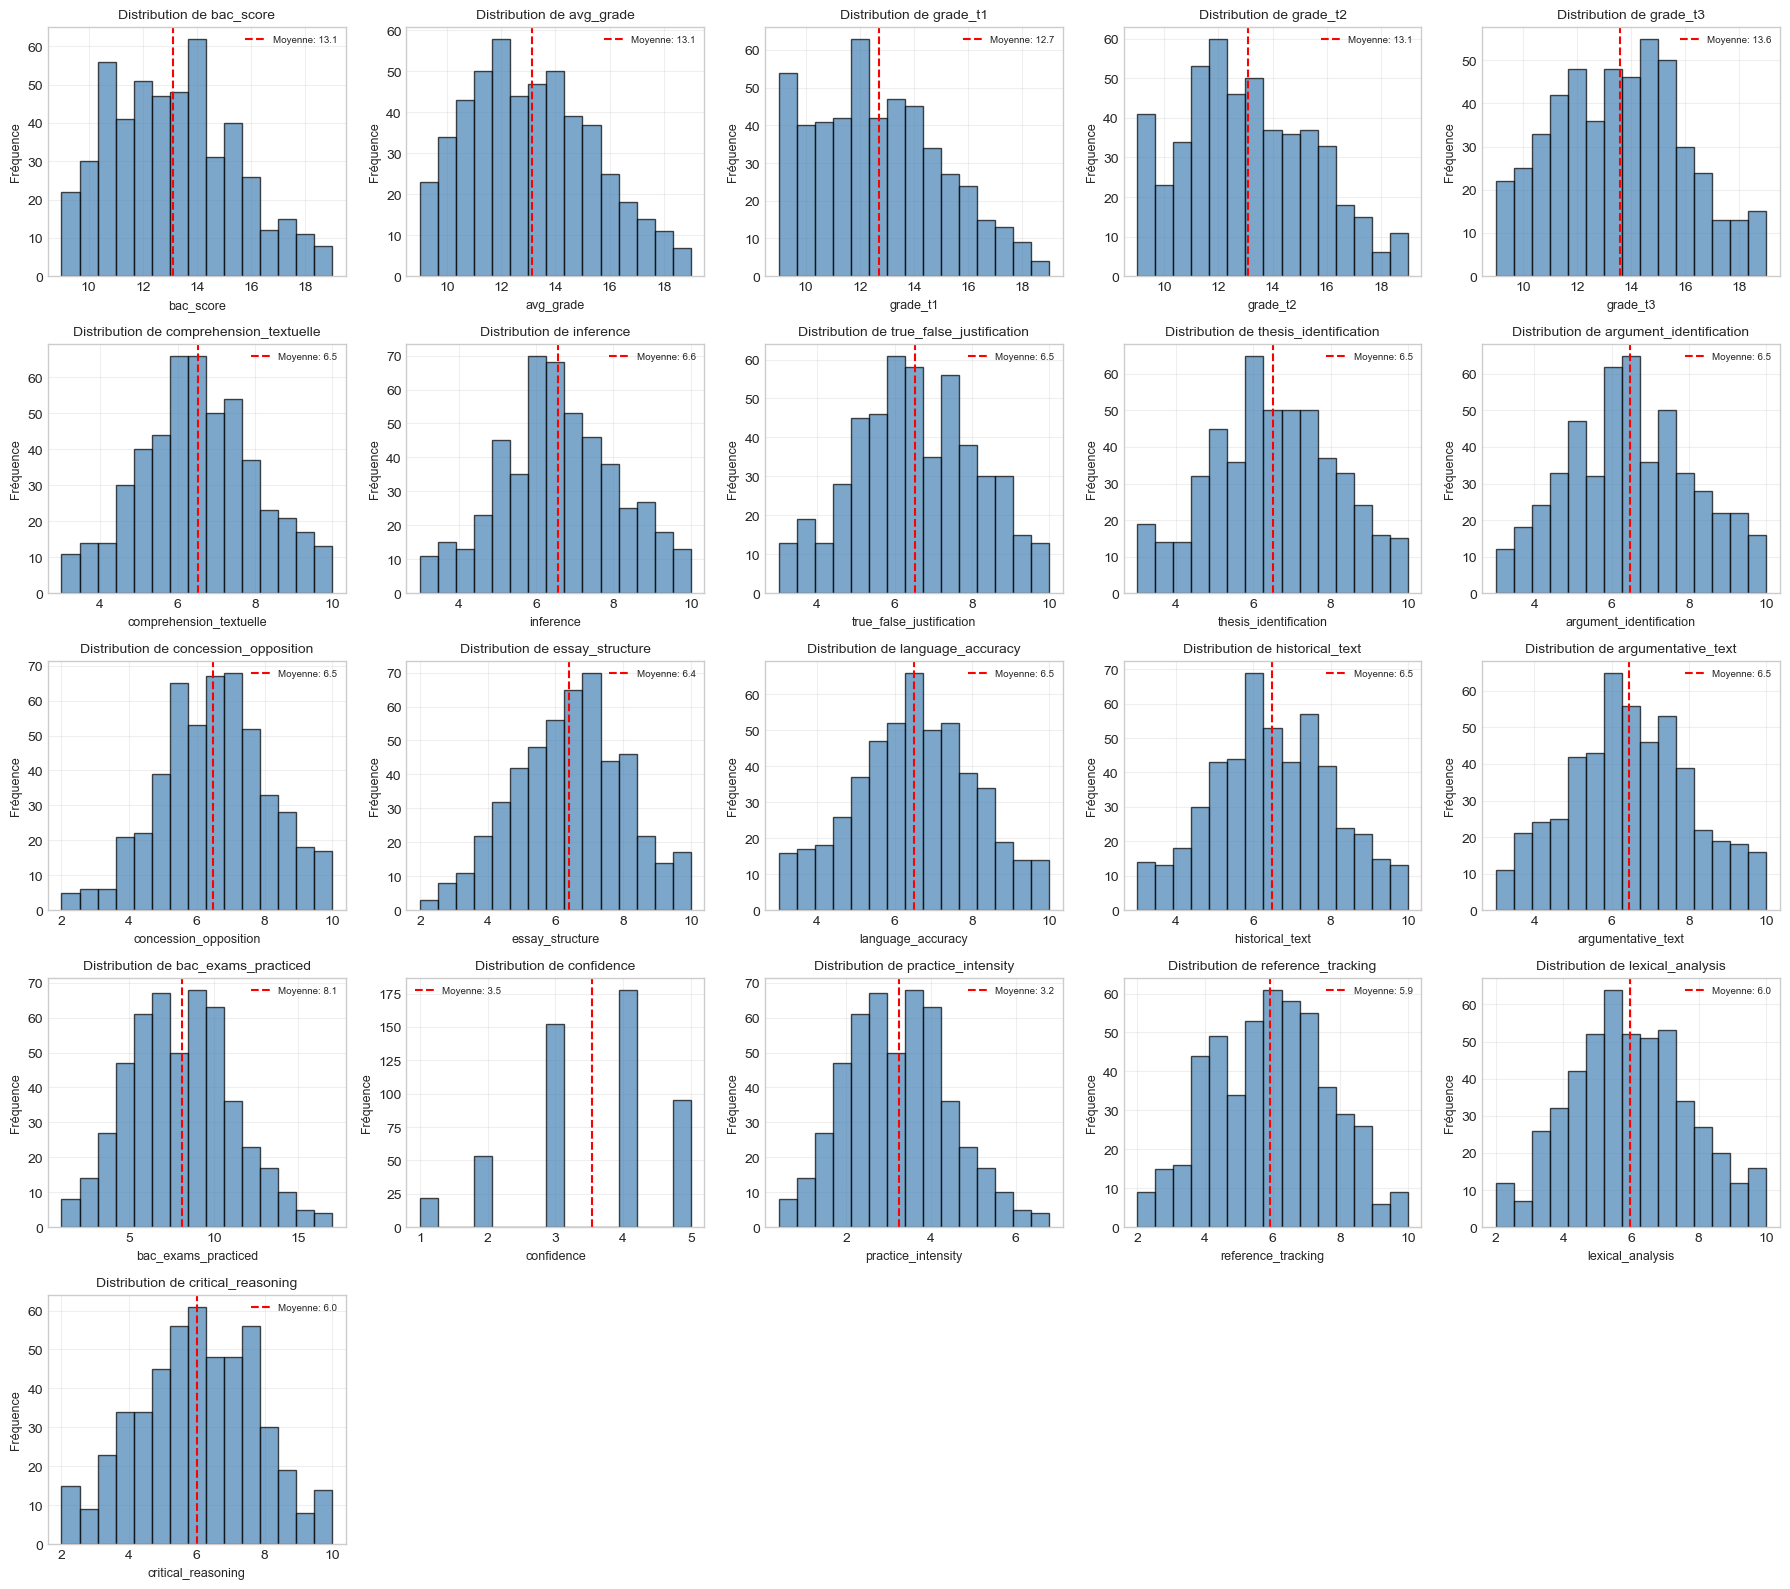


📊 STATISTIQUES RÉSUMÉES DES CARACTÉRISTIQUES CLÉS
       bac_score  avg_grade  comprehension_textuelle  thesis_identification  essay_structure  bac_exams_practiced  confidence  practice_intensity  reference_tracking  lexical_analysis  critical_reasoning
count     500.00     500.00                   500.00                 500.00           500.00               500.00      500.00              500.00              500.00            500.00              500.00
mean       13.12      13.13                     6.52                   6.51             6.41                 8.10        3.54                3.24                5.92              5.96                6.00
std         2.30       2.30                     1.51                   1.62             1.63                 2.88        1.05                1.15                1.69              1.76                1.77
min         9.00       9.00                     3.00                   3.00             2.00                 1.00        1.00        

In [43]:
# ============================================
# CELL 8: EDA - DISTRIBUTIONS DES CARACTÉRISTIQUES
# ============================================

import matplotlib.pyplot as plt

# Sélectionner les caractéristiques clés à visualiser
key_features = [
    'bac_score', 'avg_grade', 'grade_t1', 'grade_t2', 'grade_t3',
    'comprehension_textuelle', 'inference', 'true_false_justification',
    'thesis_identification', 'argument_identification', 'concession_opposition',
    'essay_structure', 'language_accuracy', 'historical_text', 'argumentative_text',
    'bac_exams_practiced', 'confidence', 'practice_intensity',
    'reference_tracking', 'lexical_analysis', 'critical_reasoning'
]

# Créer une figure avec plusieurs sous-graphiques
fig, axes = plt.subplots(5, 5, figsize=(18, 16))
axes = axes.flatten()

for i, feature in enumerate(key_features):
    axes[i].hist(df[feature], bins=15, edgecolor='black', color='steelblue', alpha=0.7)
    axes[i].axvline(df[feature].mean(), color='red', linestyle='dashed', linewidth=1.5, 
                    label=f'Moyenne: {df[feature].mean():.1f}')
    axes[i].set_xlabel(feature, fontsize=9)
    axes[i].set_ylabel('Fréquence', fontsize=9)
    axes[i].set_title(f'Distribution de {feature}', fontsize=10)
    axes[i].legend(fontsize=7)
    axes[i].grid(True, alpha=0.3)

# Cacher les sous-graphiques inutilisés
for i in range(len(key_features), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

# ============================================
# Statistiques résumées des caractéristiques clés
# ============================================

print("\n" + "=" * 80)
print("📊 STATISTIQUES RÉSUMÉES DES CARACTÉRISTIQUES CLÉS")
print("=" * 80)

# Sélectionner les colonnes à afficher
summary_cols = ['bac_score', 'avg_grade', 'comprehension_textuelle', 'thesis_identification', 
                'essay_structure', 'bac_exams_practiced', 'confidence', 'practice_intensity',
                'reference_tracking', 'lexical_analysis', 'critical_reasoning']

summary_stats = df[summary_cols].describe().round(2)
print(summary_stats)

# ============================================
# Distribution des compétences par niveau
# ============================================

print("\n" + "=" * 80)
print("📊 DISTRIBUTION DES COMPÉTENCES PAR NIVEAU")
print("=" * 80)

skills = [
    ('comprehension_textuelle', 'Compréhension'),
    ('thesis_identification', 'Identification de la thèse'),
    ('essay_structure', 'Structure de la dissertation'),
    ('reference_tracking', 'Repérage des référents')
]

for skill_col, skill_name in skills:
    low = (df[skill_col] < 5).sum()
    medium = ((df[skill_col] >= 5) & (df[skill_col] < 7)).sum()
    high = (df[skill_col] >= 7).sum()
    
    print(f"\n📖 {skill_name}:")
    print(f"   Faible (<5):   {low} étudiants ({low/len(df)*100:.1f}%)")
    print(f"   Moyen (5-7):   {medium} étudiants ({medium/len(df)*100:.1f}%)")
    print(f"   Élevé (≥7):    {high} étudiants ({high/len(df)*100:.1f}%)")

# ============================================
# Distribution des habitudes de travail
# ============================================

print("\n" + "=" * 80)
print("📊 DISTRIBUTION DES HABITUDES DE TRAVAIL")
print("=" * 80)

print(f"\n📚 Examens BAC résolus:")
print(f"   0-5:   {((df['bac_exams_practiced'] >= 0) & (df['bac_exams_practiced'] < 6)).sum()} étudiants")
print(f"   6-10:  {((df['bac_exams_practiced'] >= 6) & (df['bac_exams_practiced'] < 11)).sum()} étudiants")
print(f"   11-15: {((df['bac_exams_practiced'] >= 11) & (df['bac_exams_practiced'] < 16)).sum()} étudiants")
print(f"   16-25: {(df['bac_exams_practiced'] >= 16).sum()} étudiants")

print(f"\n💪 Confiance en soi:")
print(f"   Faible (1-2):   {(df['confidence'] <= 2).sum()} étudiants")
print(f"   Moyen (3):      {(df['confidence'] == 3).sum()} étudiants")
print(f"   Élevé (4-5):    {(df['confidence'] >= 4).sum()} étudiants")

print(f"\n✍️ Dissertations par semaine:")
print(f"   0-1:   {(df['essays_per_week'] <= 1).sum()} étudiants")
print(f"   2-3:   {((df['essays_per_week'] >= 2) & (df['essays_per_week'] <= 3)).sum()} étudiants")
print(f"   4-5:   {(df['essays_per_week'] >= 4).sum()} étudiants")

# ============================================
# Distribution des notes par filière
# ============================================

print("\n" + "=" * 80)
print("📊 DISTRIBUTION DES NOTES PAR FILIÈRE")
print("=" * 80)

filiere_names = {0: 'Sciences', 1: 'Langues', 2: 'Lettres'}

for f_code, f_name in filiere_names.items():
    subset = df[df['filiere'] == f_code]
    print(f"\n🎓 {f_name} ({len(subset)} étudiants):")
    print(f"   Note moyenne: {subset['bac_score'].mean():.2f}/20")
    print(f"   Médiane: {subset['bac_score'].median():.2f}/20")
    print(f"   Écart-type: {subset['bac_score'].std():.2f}")
    print(f"   Taux de réussite: {(subset['bac_score'] >= 10).mean() * 100:.1f}%")

print("\n" + "=" * 80)
print("✅ DISTRIBUTIONS TERMINÉES")
print("=" * 80)

In [4]:
# ============================================
# CELL 9: FEATURE ENGINEERING - CARACTÉRISTIQUES DÉRIVÉES
# ============================================

print("=" * 60)
print("📊 FEATURE ENGINEERING")
print("Création des caractéristiques dérivées")
print("=" * 60)

# Copier le dataframe
df_fe = df.copy()

# ============================================
# 1. Score de compréhension (moyenne des compétences clés)
# ============================================
comprehension_cols = [
    'comprehension_textuelle', 'inference', 'true_false_justification', 
    'communicative_intent', 'reference_tracking', 'lexical_analysis'
]
df_fe['comprehension_score_derived'] = df_fe[comprehension_cols].mean(axis=1)
df_fe['comprehension_score_derived'] = np.round(df_fe['comprehension_score_derived'], 2)

# ============================================
# 2. Score d'argumentation (moyenne des compétences d'argumentation)
# ============================================
argumentation_cols = [
    'thesis_identification', 'argument_identification', 
    'concession_opposition', 'critical_reasoning'
]
df_fe['argumentation_score_derived'] = df_fe[argumentation_cols].mean(axis=1)
df_fe['argumentation_score_derived'] = np.round(df_fe['argumentation_score_derived'], 2)

# ============================================
# 3. Score d'écriture (moyenne des compétences d'écriture)
# ============================================
writing_cols = [
    'essay_structure', 'coherence_cohesion', 'language_accuracy'
]
df_fe['writing_score_derived'] = df_fe[writing_cols].mean(axis=1)
df_fe['writing_score_derived'] = np.round(df_fe['writing_score_derived'], 2)

# ============================================
# 4. Score des types de textes
# ============================================
text_type_cols = ['historical_text', 'argumentative_text']
df_fe['text_type_score_derived'] = df_fe[text_type_cols].mean(axis=1)
df_fe['text_type_score_derived'] = np.round(df_fe['text_type_score_derived'], 2)

# ============================================
# 5. Score de pratique (basé sur les examens résolus)
# ============================================
# Normalisé sur 10 (0-25 examens → 0-10)
df_fe['practice_score'] = (df_fe['bac_exams_practiced'] / 25) * 10
df_fe['practice_score'] = np.round(df_fe['practice_score'], 2)

# ============================================
# 6. Score psychologique (confiance - stress)
# ============================================
df_fe['psycho_score'] = df_fe['confidence'] - df_fe['stress']
df_fe['psycho_score'] = np.clip(df_fe['psycho_score'], -4, 4)

# ============================================
# 7. Score de préparation (combinaison pratique + confiance)
# ============================================
df_fe['preparation_score'] = (df_fe['practice_score'] * 0.7 + (df_fe['confidence'] / 5 * 10) * 0.3)
df_fe['preparation_score'] = np.round(df_fe['preparation_score'], 2)

# ============================================
# 8. Score de déséquilibre (variance entre les 3 domaines principaux)
# ============================================
# Plus le score est élevé, plus l'étudiant a des compétences déséquilibrées
skills_for_balance = ['comprehension_score_derived', 'argumentation_score_derived', 'writing_score_derived']
df_fe['imbalance_score'] = df_fe[skills_for_balance].var(axis=1)
df_fe['imbalance_score'] = np.round(df_fe['imbalance_score'], 2)

# ============================================
# 9. Score global des compétences
# ============================================
df_fe['global_skills_score'] = (df_fe['comprehension_score_derived'] + 
                                 df_fe['argumentation_score_derived'] + 
                                 df_fe['writing_score_derived']) / 3
df_fe['global_skills_score'] = np.round(df_fe['global_skills_score'], 2)

# ============================================
# 10. Tendance des notes (amélioration trimestrielle)
# ============================================
df_fe['grade_trend'] = df_fe['grade_t3'] - df_fe['grade_t1']
df_fe['grade_trend'] = np.round(df_fe['grade_trend'], 1)

# ============================================
# 11. Stabilité des notes
# ============================================
grade_variance = np.var([df_fe['grade_t1'], df_fe['grade_t2'], df_fe['grade_t3']], axis=0)
df_fe['grade_stability'] = 1 / (1 + grade_variance)
df_fe['grade_stability'] = np.clip(df_fe['grade_stability'], 0.3, 0.95)
df_fe['grade_stability'] = np.round(df_fe['grade_stability'], 2)

# ============================================
# Afficher les nouvelles caractéristiques
# ============================================
new_features = [
    'comprehension_score_derived', 'argumentation_score_derived', 'writing_score_derived',
    'text_type_score_derived', 'practice_score', 'psycho_score', 'preparation_score',
    'imbalance_score', 'global_skills_score', 'grade_trend', 'grade_stability'
]

print("\n✅ Nouvelles caractéristiques dérivées créées:")
for f in new_features:
    print(f"   • {f}")

# ============================================
# Aperçu des nouvelles caractéristiques
# ============================================
print("\n📊 Aperçu des 5 premières lignes (caractéristiques dérivées):")
print(df_fe[['bac_score'] + new_features].head())

# ============================================
# Statistiques des nouvelles caractéristiques
# ============================================
print("\n📊 Statistiques des caractéristiques dérivées:")
print(df_fe[new_features].describe().round(2))

# ============================================
# Remplacer l'ancien dataframe par le nouveau
# ============================================
df = df_fe.copy()

print("\n✅ Feature engineering terminé!")
print(f"   Nombre total de colonnes: {df.shape[1]}")
print("=" * 60)

📊 FEATURE ENGINEERING
Création des caractéristiques dérivées

✅ Nouvelles caractéristiques dérivées créées:
   • comprehension_score_derived
   • argumentation_score_derived
   • writing_score_derived
   • text_type_score_derived
   • practice_score
   • psycho_score
   • preparation_score
   • imbalance_score
   • global_skills_score
   • grade_trend
   • grade_stability

📊 Aperçu des 5 premières lignes (caractéristiques dérivées):
   bac_score  comprehension_score_derived  argumentation_score_derived  writing_score_derived  text_type_score_derived  practice_score  psycho_score  preparation_score  imbalance_score  global_skills_score  grade_trend  grade_stability
0       14.2                         6.90                         6.93                   5.77                     7.30             3.6             1               5.52             0.44                 6.53          1.2             0.81
1       12.1                         5.62                         5.92                   5.

In [5]:
# ============================================
# CELL 10: TRAIN/TEST SPLIT
# ============================================

from sklearn.model_selection import train_test_split

print("=" * 60)
print("📊 TRAIN/TEST SPLIT")
print("=" * 60)

# ============================================
# Définir les features (X) et la cible (y)
# ============================================

# Exclure la cible et les colonnes non nécessaires pour la prédiction
exclude_cols = ['bac_score', 'grade_trend', 'grade_stability']
feature_cols = [col for col in df.columns if col not in exclude_cols]

X = df[feature_cols]
y = df['bac_score']

print(f"\n📊 Features (X): {X.shape[1]} colonnes")
print(f"📊 Cible (y): bac_score")

# ============================================
# Diviser les données (80% entraînement, 20% test)
# ============================================
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\n✅ Division terminée:")
print(f"   Entraînement: {X_train.shape[0]} étudiants ({X_train.shape[0]/len(df)*100:.0f}%)")
print(f"   Test:         {X_test.shape[0]} étudiants ({X_test.shape[0]/len(df)*100:.0f}%)")

# ============================================
# Afficher les premières lignes
# ============================================
print("\n📋 Premières 3 lignes des features d'entraînement:")
print(X_train.head(3).to_string())

print("\n📋 Premières 3 valeurs cibles:")
print(y_train.head(3).tolist())

# ============================================
# Vérifier l'absence de fuite de données
# ============================================
print("\n✅ Pas de chevauchement entre train et test:")
print(f"   Indices train: {X_train.index[:5].tolist()}...")
print(f"   Indices test:  {X_test.index[:5].tolist()}...")

# ============================================
# Afficher la liste des features
# ============================================
print("\n📋 Liste des features utilisées:")
for i, col in enumerate(feature_cols):
    print(f"   {i+1:2d}. {col}")

print("\n" + "=" * 60)
print("✅ Train/Test Split terminé")
print("=" * 60)

📊 TRAIN/TEST SPLIT

📊 Features (X): 39 colonnes
📊 Cible (y): bac_score

✅ Division terminée:
   Entraînement: 400 étudiants (80%)
   Test:         100 étudiants (20%)

📋 Premières 3 lignes des features d'entraînement:
     grade_t1  grade_t2  grade_t3  avg_grade  comprehension_textuelle  inference  true_false_justification  communicative_intent  thesis_identification  argument_identification  concession_opposition  essay_structure  language_accuracy  historical_text  argumentative_text  reference_tracking  lexical_analysis  critical_reasoning  coherence_cohesion  bac_exams_practiced  confidence  essays_per_week  texts_analyzed_per_week  stress  filiere  comprehension_score  argumentation_score  writing_score  text_type_score  practice_intensity  comprehension_score_derived  argumentation_score_derived  writing_score_derived  text_type_score_derived  practice_score  psycho_score  preparation_score  imbalance_score  global_skills_score
249      14.8      16.8      14.8       15.5        

In [6]:
# ============================================
# CELL 11: MODEL TRAINING - RANDOM FOREST MULTI-OUTPUT
# ============================================

from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("=" * 60)
print("🤖 MODEL TRAINING - RANDOM FOREST")
print("=" * 60)

# ============================================
# Préparer les cibles multi-sorties
# ============================================

# Pour multi-output, nous avons besoin de 3 cibles:
# 1. predicted_score (note BAC prédite)
# 2. success_probability (probabilité d'avoir ≥10)
# 3. improvement_potential (points pouvant être gagnés)

y_train_multi = np.zeros((len(y_train), 3))
y_test_multi = np.zeros((len(y_test), 3))

# Cible 1: Note BAC réelle
y_train_multi[:, 0] = y_train.values
y_test_multi[:, 0] = y_test.values

# Cible 2: Probabilité de succès (1 si score ≥ 10, sinon 0)
y_train_multi[:, 1] = (y_train >= 10).astype(int)
y_test_multi[:, 1] = (y_test >= 10).astype(int)

# Cible 3: Potentiel d'amélioration (distance par rapport à 18)
y_train_multi[:, 2] = 18 - y_train.values
y_test_multi[:, 2] = 18 - y_test.values
y_train_multi[:, 2] = np.clip(y_train_multi[:, 2], 0, 10)
y_test_multi[:, 2] = np.clip(y_test_multi[:, 2], 0, 10)

print(f"\n📊 Cibles multi-sorties créées:")
print(f"   Sortie 1: predicted_score (0-20)")
print(f"   Sortie 2: success_probability (0 ou 1)")
print(f"   Sortie 3: improvement_potential (0-10)")

# ============================================
# Entraîner le modèle Random Forest Multi-output
# ============================================

print(f"\n🚀 Entraînement du Random Forest Multi-output...")

base_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
model = MultiOutputRegressor(base_model)

model.fit(X_train, y_train_multi)

print(f"✅ Modèle entraîné avec succès!")

# ============================================
# Faire des prédictions
# ============================================
y_pred_multi = model.predict(X_test)

# Extraire les prédictions individuelles
y_pred_score = y_pred_multi[:, 0]
y_pred_prob = y_pred_multi[:, 1]
y_pred_improve = y_pred_multi[:, 2]

# ============================================
# Évaluer chaque sortie
# ============================================
print("\n" + "=" * 60)
print("📊 ÉVALUATION DU MODÈLE")
print("=" * 60)

# Sortie 1: Prédiction de la note
mae_score = mean_absolute_error(y_test, y_pred_score)
rmse_score = np.sqrt(mean_squared_error(y_test, y_pred_score))
r2_score_val = r2_score(y_test, y_pred_score)

print(f"\n📊 Sortie 1: Note BAC prédite (0-20)")
print(f"   MAE:  {mae_score:.2f} points")
print(f"   RMSE: {rmse_score:.2f} points")
print(f"   R²:   {r2_score_val:.3f}")

# Sortie 2: Probabilité de succès
from sklearn.metrics import accuracy_score

y_pred_class = (y_pred_prob >= 0.5).astype(int)
acc_score = accuracy_score(y_test_multi[:, 1], y_pred_class)

print(f"\n📊 Sortie 2: Probabilité de succès (≥10/20)")
print(f"   Accuracy: {acc_score:.3f} ({acc_score*100:.1f}%)")

# Sortie 3: Potentiel d'amélioration
mae_improve = mean_absolute_error(y_test_multi[:, 2], y_pred_improve)
print(f"\n📊 Sortie 3: Potentiel d'amélioration (0-10)")
print(f"   MAE: {mae_improve:.2f} points")

# ============================================
# Importance des features
# ============================================
print("\n" + "=" * 60)
print("📊 IMPORTANCE DES CARACTÉRISTIQUES")
print("=" * 60)

# Récupérer l'importance depuis le premier estimateur
feature_importance = model.estimators_[0].feature_importances_
feature_importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': feature_importance
}).sort_values('importance', ascending=False)

print("\nTop 15 caractéristiques les plus importantes:")
for i, row in feature_importance_df.head(15).iterrows():
    print(f"   {row['feature']:35s}: {row['importance']:.4f} ({row['importance']*100:.1f}%)")

# ============================================
# Échantillon des prédictions vs réalité
# ============================================
print("\n" + "=" * 60)
print("📊 ÉCHANTILLON DES PRÉDICTIONS (10 premiers étudiants du test)")
print("=" * 60)

sample_df = pd.DataFrame({
    'Réel': y_test.values[:10],
    'Prédit': np.round(y_pred_score[:10], 1),
    'Erreur': np.round(y_test.values[:10] - y_pred_score[:10], 1)
})
print(sample_df.to_string())

# ============================================
# Résumé des performances
# ============================================
print("\n" + "=" * 60)
print("✅ RÉSUMÉ DES PERFORMANCES")
print("=" * 60)
print(f"   MAE:  {mae_score:.3f} points")
print(f"   RMSE: {rmse_score:.3f} points")
print(f"   R²:   {r2_score_val:.3f}")
print(f"   Accuracy (réussite): {acc_score*100:.1f}%")
print("=" * 60)

🤖 MODEL TRAINING - RANDOM FOREST

📊 Cibles multi-sorties créées:
   Sortie 1: predicted_score (0-20)
   Sortie 2: success_probability (0 ou 1)
   Sortie 3: improvement_potential (0-10)

🚀 Entraînement du Random Forest Multi-output...
✅ Modèle entraîné avec succès!

📊 ÉVALUATION DU MODÈLE

📊 Sortie 1: Note BAC prédite (0-20)
   MAE:  0.32 points
   RMSE: 0.39 points
   R²:   0.969

📊 Sortie 2: Probabilité de succès (≥10/20)
   Accuracy: 0.980 (98.0%)

📊 Sortie 3: Potentiel d'amélioration (0-10)
   MAE: 0.31 points

📊 IMPORTANCE DES CARACTÉRISTIQUES

Top 15 caractéristiques les plus importantes:
   avg_grade                          : 0.9157 (91.6%)
   grade_t3                           : 0.0283 (2.8%)
   comprehension_score                : 0.0058 (0.6%)
   argumentation_score                : 0.0041 (0.4%)
   argumentation_score_derived        : 0.0037 (0.4%)
   thesis_identification              : 0.0033 (0.3%)
   global_skills_score                : 0.0030 (0.3%)
   writing_score    

📊 ÉVALUATION DÉTAILLÉE DU MODÈLE

----------------------------------------
1. PRÉDICTION DE LA NOTE (0-20)
----------------------------------------
   Mean Absolute Error (MAE):     0.324 points
   Mean Squared Error (MSE):      0.154
   Root Mean Squared Error (RMSE): 0.392 points
   R² Score:                      0.969

----------------------------------------
2. CLASSIFICATION RÉUSSITE/ÉCHEC (≥10/20)
----------------------------------------
   Accuracy:  0.980 (98.0%)

   Matrice de confusion:
   --------------------
   Vrais Négatifs (échec):  7
   Faux Positifs:           1
   Faux Négatifs:           1
   Vrais Positifs (réussite): 91

   Rapport de classification:
   -------------------------
                precision    recall  f1-score   support

   Échec (<10)       0.88      0.88      0.88         8
Réussite (≥10)       0.99      0.99      0.99        92

      accuracy                           0.98       100
     macro avg       0.93      0.93      0.93       100
  weighte

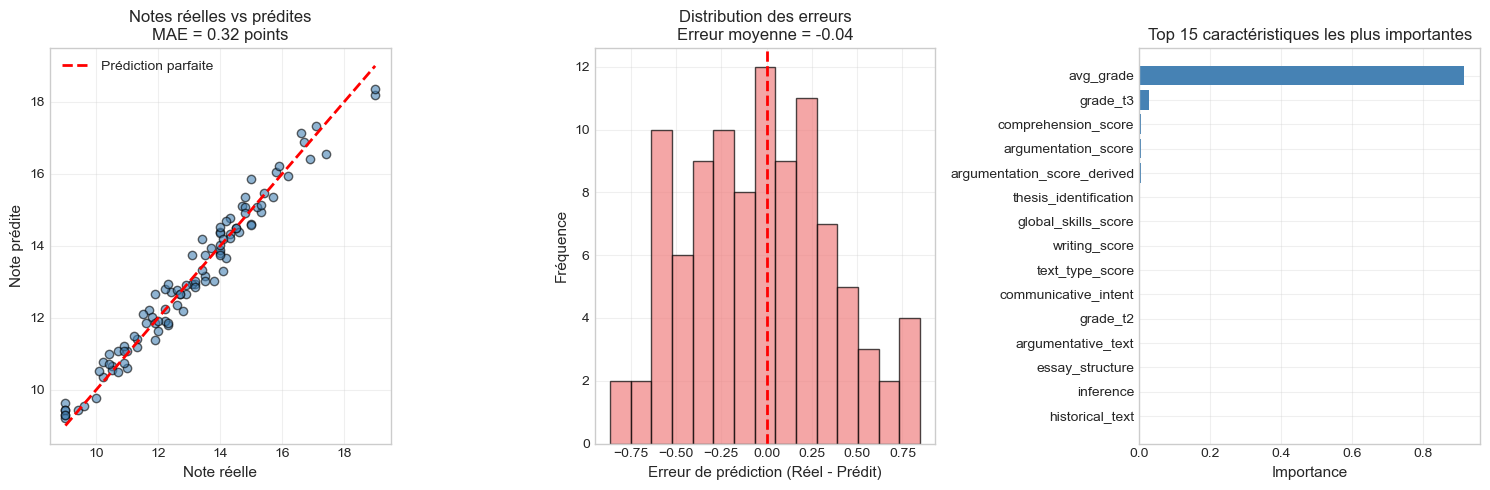


----------------------------------------
4. RÉSUMÉ DES ERREURS
----------------------------------------
   Erreur moyenne:      0.324 points
   Erreur médiane:      0.285 points
   Erreur maximale:     0.864 points
   Erreur < 1 point:    100.0% des prédictions
   Erreur < 2 points:   100.0% des prédictions

----------------------------------------
5. PERFORMANCE PAR TRANCHE DE NOTES
----------------------------------------
   <10      (  9 étudiants): MAE = 0.294 points
   10-12    ( 26 étudiants): MAE = 0.301 points
   12-14    ( 33 étudiants): MAE = 0.320 points
   14-16    ( 24 étudiants): MAE = 0.308 points
   16-20    (  8 étudiants): MAE = 0.503 points

✅ ÉVALUATION TERMINÉE


In [7]:
# ============================================
# CELL 12: ÉVALUATION DÉTAILLÉE DU MODÈLE
# ============================================

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

print("=" * 60)
print("📊 ÉVALUATION DÉTAILLÉE DU MODÈLE")
print("=" * 60)

# ============================================
# 1. Métriques de prédiction de la note
# ============================================
print("\n" + "-" * 40)
print("1. PRÉDICTION DE LA NOTE (0-20)")
print("-" * 40)

mae = mean_absolute_error(y_test, y_pred_score)
mse = mean_squared_error(y_test, y_pred_score)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_score)

print(f"   Mean Absolute Error (MAE):     {mae:.3f} points")
print(f"   Mean Squared Error (MSE):      {mse:.3f}")
print(f"   Root Mean Squared Error (RMSE): {rmse:.3f} points")
print(f"   R² Score:                      {r2:.3f}")

# ============================================
# 2. Classification réussite/échec
# ============================================
print("\n" + "-" * 40)
print("2. CLASSIFICATION RÉUSSITE/ÉCHEC (≥10/20)")
print("-" * 40)

y_true_class = (y_test >= 10).astype(int)
y_pred_class = (y_pred_prob >= 0.5).astype(int)

accuracy = accuracy_score(y_true_class, y_pred_class)
print(f"   Accuracy:  {accuracy:.3f} ({accuracy*100:.1f}%)")

print("\n   Matrice de confusion:")
print("   --------------------")
cm = confusion_matrix(y_true_class, y_pred_class)
print(f"   Vrais Négatifs (échec):  {cm[0][0]}")
print(f"   Faux Positifs:           {cm[0][1]}")
print(f"   Faux Négatifs:           {cm[1][0]}")
print(f"   Vrais Positifs (réussite): {cm[1][1]}")

print("\n   Rapport de classification:")
print("   -------------------------")
print(classification_report(y_true_class, y_pred_class, target_names=['Échec (<10)', 'Réussite (≥10)']))

# ============================================
# 3. Potentiel d'amélioration
# ============================================
print("\n" + "-" * 40)
print("3. POTENTIEL D'AMÉLIORATION")
print("-" * 40)

mae_improve = mean_absolute_error(y_test_multi[:, 2], y_pred_improve)
print(f"   MAE: {mae_improve:.3f} points")

# ============================================
# 4. Visualisation: Prédictions vs Réel
# ============================================
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Graphique 1: Réel vs Prédit
axes[0].scatter(y_test, y_pred_score, alpha=0.6, color='steelblue', edgecolors='black')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2, label='Prédiction parfaite')
axes[0].set_xlabel('Note réelle', fontsize=11)
axes[0].set_ylabel('Note prédite', fontsize=11)
axes[0].set_title(f'Notes réelles vs prédites\nMAE = {mae:.2f} points', fontsize=12)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Graphique 2: Distribution des erreurs
residuals = y_test - y_pred_score
axes[1].hist(residuals, bins=15, edgecolor='black', color='lightcoral', alpha=0.7)
axes[1].axvline(0, color='red', linestyle='dashed', linewidth=2)
axes[1].set_xlabel('Erreur de prédiction (Réel - Prédit)', fontsize=11)
axes[1].set_ylabel('Fréquence', fontsize=11)
axes[1].set_title(f'Distribution des erreurs\nErreur moyenne = {residuals.mean():.2f}', fontsize=12)
axes[1].grid(True, alpha=0.3)

# Graphique 3: Importance des features (Top 15)
feature_importance = model.estimators_[0].feature_importances_
feature_importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': feature_importance
}).sort_values('importance', ascending=True).tail(15)

axes[2].barh(feature_importance_df['feature'], feature_importance_df['importance'], color='steelblue')
axes[2].set_xlabel('Importance', fontsize=11)
axes[2].set_title('Top 15 caractéristiques les plus importantes', fontsize=12)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================
# 5. Résumé des erreurs
# ============================================
print("\n" + "-" * 40)
print("4. RÉSUMÉ DES ERREURS")
print("-" * 40)

errors = np.abs(y_test - y_pred_score)
print(f"   Erreur moyenne:      {errors.mean():.3f} points")
print(f"   Erreur médiane:      {errors.median():.3f} points")
print(f"   Erreur maximale:     {errors.max():.3f} points")
print(f"   Erreur < 1 point:    {(errors < 1).mean()*100:.1f}% des prédictions")
print(f"   Erreur < 2 points:   {(errors < 2).mean()*100:.1f}% des prédictions")

# ============================================
# 6. Analyse par tranches de notes
# ============================================
print("\n" + "-" * 40)
print("5. PERFORMANCE PAR TRANCHE DE NOTES")
print("-" * 40)

# Créer des tranches de notes
bins = [0, 10, 12, 14, 16, 20]
labels = ['<10', '10-12', '12-14', '14-16', '16-20']
y_test_binned = pd.cut(y_test, bins=bins, labels=labels)

for label in labels:
    mask = y_test_binned == label
    if mask.sum() > 0:
        mae_slice = mean_absolute_error(y_test[mask], y_pred_score[mask])
        print(f"   {label:8s} ({mask.sum():3d} étudiants): MAE = {mae_slice:.3f} points")

print("\n" + "=" * 60)
print("✅ ÉVALUATION TERMINÉE")
print("=" * 60)

🔍 SHAP EXPLAINABILITY
Explication des prédictions individuelles

📊 Création de l'explainer SHAP...
✅ Explainer SHAP créé
   Shape des valeurs SHAP: (100, 39)


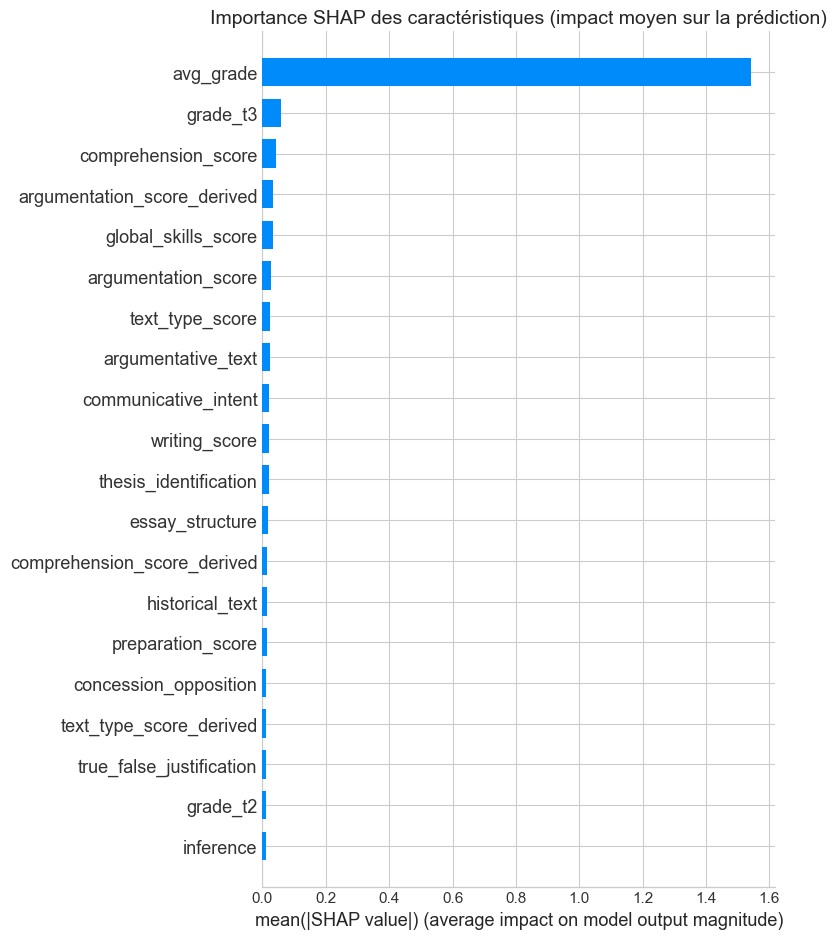

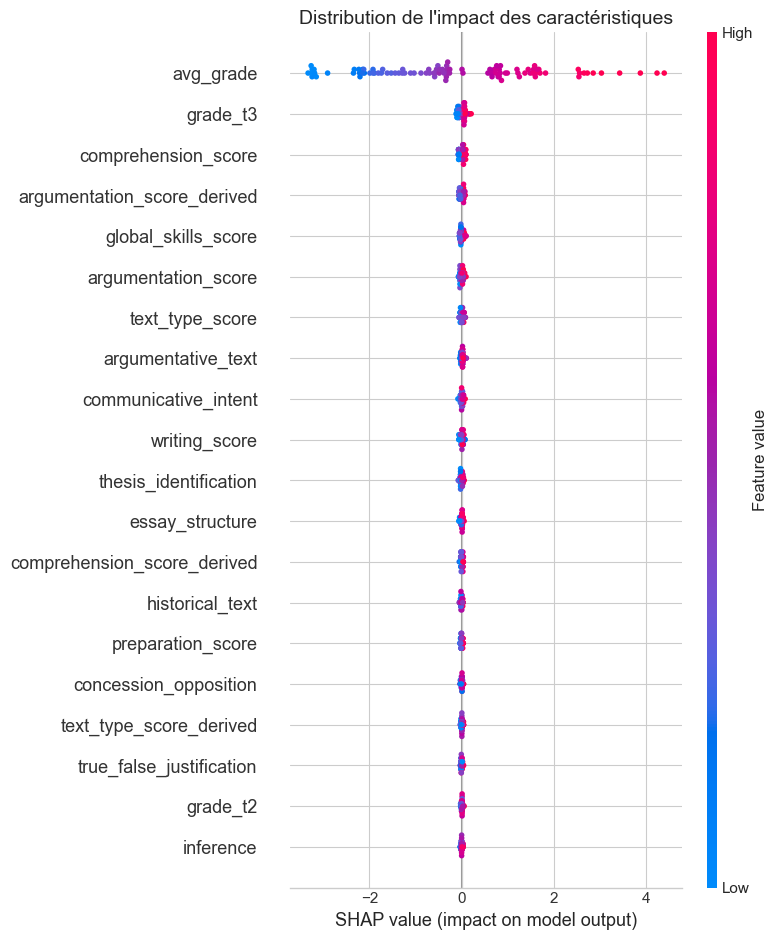


📊 EXPLICATION D'UN ÉTUDIANT SPÉCIFIQUE

👤 Étudiant #0:
   Note réelle: 15.8
   Note prédite: 16.1


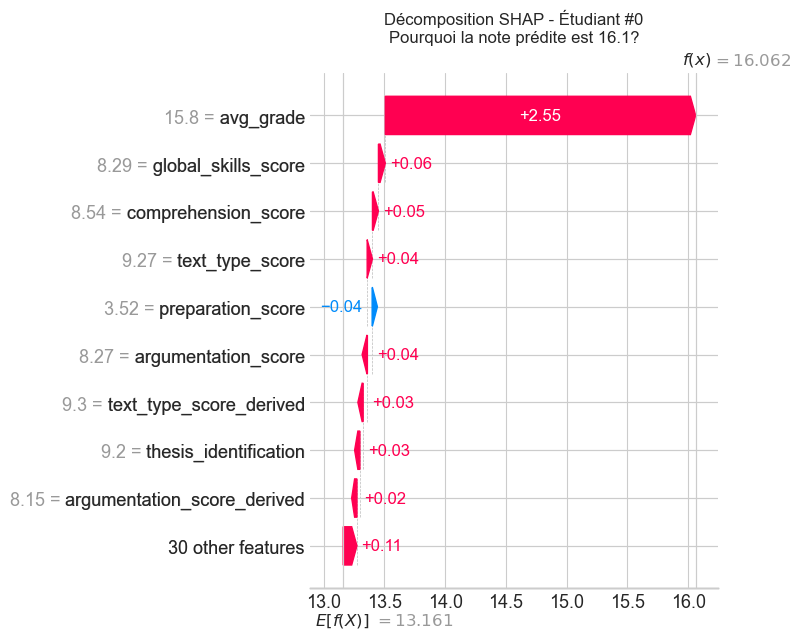


📖 EXPLICATION SIMPLE POUR L'ÉTUDIANT

✅ Note prédite: 16.1/20
   Note réelle: 15.8/20

🔴 FACTEURS QUI ONT BAISSÉ LA NOTE (Points faibles):
   • preparation_score: -0.04 points
   • critical_reasoning: -0.02 points
   • practice_score: -0.01 points
   • coherence_cohesion: -0.01 points
   • concession_opposition: -0.01 points

🟢 FACTEURS QUI ONT AUGMENTÉ LA NOTE (Points forts):
   • avg_grade: +2.55 points
   • global_skills_score: +0.06 points
   • comprehension_score: +0.05 points
   • text_type_score: +0.04 points
   • argumentation_score: +0.04 points

✅ Valeurs SHAP sauvegardées dans 'shap_values_french.csv'

✅ SHAP Explainability terminé


In [8]:
# ============================================
# CELL 13: SHAP EXPLAINABILITY - EXPLICATION DES PRÉDICTIONS
# ============================================

import shap
import matplotlib.pyplot as plt

print("=" * 60)
print("🔍 SHAP EXPLAINABILITY")
print("Explication des prédictions individuelles")
print("=" * 60)

# ============================================
# Créer l'explainer SHAP
# ============================================
print("\n📊 Création de l'explainer SHAP...")

# Utiliser TreeExplainer pour Random Forest
explainer = shap.TreeExplainer(model.estimators_[0])  # Premier estimateur pour la prédiction de note
shap_values = explainer.shap_values(X_test)

print(f"✅ Explainer SHAP créé")
print(f"   Shape des valeurs SHAP: {np.array(shap_values).shape}")

# ============================================
# Visualisation 1: Importance globale des features (SHAP)
# ============================================
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title('Importance SHAP des caractéristiques (impact moyen sur la prédiction)', fontsize=14)
plt.tight_layout()
plt.show()

# ============================================
# Visualisation 2: Summary plot (beeswarm)
# ============================================
plt.figure(figsize=(12, 10))
shap.summary_plot(shap_values, X_test, show=False)
plt.title('Distribution de l\'impact des caractéristiques', fontsize=14)
plt.tight_layout()
plt.show()

# ============================================
# Visualisation 3: Explication d'un étudiant spécifique
# ============================================
print("\n" + "=" * 60)
print("📊 EXPLICATION D'UN ÉTUDIANT SPÉCIFIQUE")
print("=" * 60)

# Prendre le premier étudiant du test
student_idx = 0
student_features = X_test.iloc[student_idx:student_idx+1]
student_actual = y_test.iloc[student_idx]
student_pred = y_pred_score[student_idx]

print(f"\n👤 Étudiant #{student_idx}:")
print(f"   Note réelle: {student_actual:.1f}")
print(f"   Note prédite: {student_pred:.1f}")

# Créer le waterfall plot
plt.figure(figsize=(10, 6))
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[student_idx],
        base_values=explainer.expected_value,
        data=student_features.values[0],
        feature_names=student_features.columns.tolist()
    ),
    show=False
)
plt.title(f'Décomposition SHAP - Étudiant #{student_idx}\nPourquoi la note prédite est {student_pred:.1f}?', fontsize=12)
plt.tight_layout()
plt.show()

# ============================================
# Explication simple en français
# ============================================
print("\n" + "=" * 60)
print("📖 EXPLICATION SIMPLE POUR L'ÉTUDIANT")
print("=" * 60)

# Récupérer les valeurs SHAP pour cet étudiant
student_shap = shap_values[student_idx]
feature_names = X_test.columns.tolist()

# Créer un DataFrame des contributions
shap_df = pd.DataFrame({
    'caracteristique': feature_names,
    'contribution': student_shap
})
shap_df['abs_contribution'] = np.abs(shap_df['contribution'])
shap_df = shap_df.sort_values('abs_contribution', ascending=False)

# Séparer contributions positives et négatives
positive = shap_df[shap_df['contribution'] > 0].head(5)
negative = shap_df[shap_df['contribution'] < 0].head(5)

print(f"\n✅ Note prédite: {student_pred:.1f}/20")
print(f"   Note réelle: {student_actual:.1f}/20")

print(f"\n🔴 FACTEURS QUI ONT BAISSÉ LA NOTE (Points faibles):")
if len(negative) > 0:
    for _, row in negative.iterrows():
        print(f"   • {row['caracteristique']}: -{abs(row['contribution']):.2f} points")
else:
    print("   • Aucun - ce profil n'a pas de faiblesses majeures!")

print(f"\n🟢 FACTEURS QUI ONT AUGMENTÉ LA NOTE (Points forts):")
if len(positive) > 0:
    for _, row in positive.iterrows():
        print(f"   • {row['caracteristique']}: +{row['contribution']:.2f} points")
else:
    print("   • Aucun")

# ============================================
# Sauvegarder les valeurs SHAP
# ============================================
shap_df_all = pd.DataFrame(shap_values, columns=feature_names)
shap_df_all.to_csv('shap_values_french.csv', index=False)
print("\n✅ Valeurs SHAP sauvegardées dans 'shap_values_french.csv'")

print("\n" + "=" * 60)
print("✅ SHAP Explainability terminé")
print("=" * 60)

In [49]:
# ============================================
# CELL 14: WEAKNESS ANALYSIS - ANALYSE DES FAIBLESSES
# ============================================

import pandas as pd
import numpy as np
from collections import Counter

print("=" * 60)
print("📊 WEAKNESS ANALYSIS")
print("Analyse des points faibles par étudiant")
print("=" * 60)

# ============================================
# Utiliser les valeurs SHAP pour identifier les faiblesses
# ============================================

# Récupérer les noms des caractéristiques et les valeurs SHAP
feature_names = X_test.columns.tolist()
shap_values_array = np.array(shap_values)

# Créer un DataFrame des valeurs SHAP
shap_df = pd.DataFrame(shap_values_array, columns=feature_names)

# ============================================
# Pour chaque étudiant, identifier les 3 principales faiblesses et forces
# ============================================

print("\n📊 Analyse des faiblesses pour chaque étudiant...")

weakness_list = []

for i in range(len(X_test)):
    student_shap = shap_df.iloc[i]
    
    # Contributions négatives = faiblesses (ont baissé la note)
    weaknesses = student_shap[student_shap < 0].sort_values()
    top_weaknesses = weaknesses.head(3)
    
    # Contributions positives = forces (ont augmenté la note)
    strengths = student_shap[student_shap > 0].sort_values(ascending=False)
    top_strengths = strengths.head(3)
    
    weakness_list.append({
        'student_id': i,
        'weakness_1': f"{top_weaknesses.index[0]} ({top_weaknesses.values[0]:.2f})" if len(top_weaknesses) > 0 else "Aucune",
        'weakness_2': f"{top_weaknesses.index[1]} ({top_weaknesses.values[1]:.2f})" if len(top_weaknesses) > 1 else "Aucune",
        'weakness_3': f"{top_weaknesses.index[2]} ({top_weaknesses.values[2]:.2f})" if len(top_weaknesses) > 2 else "Aucune",
        'strength_1': f"{top_strengths.index[0]} (+{top_strengths.values[0]:.2f})" if len(top_strengths) > 0 else "Aucune",
        'strength_2': f"{top_strengths.index[1]} (+{top_strengths.values[1]:.2f})" if len(top_strengths) > 1 else "Aucune",
        'strength_3': f"{top_strengths.index[2]} (+{top_strengths.values[2]:.2f})" if len(top_strengths) > 2 else "Aucune",
        'actual_score': y_test.iloc[i],
        'predicted_score': y_pred_score[i]
    })

weakness_df = pd.DataFrame(weakness_list)

# ============================================
# Afficher les 10 premiers étudiants
# ============================================
print("\n📋 10 PREMIERS ÉTUDIANTS - FAIBLESSES & FORCES:")
print("=" * 80)
for i in range(min(10, len(weakness_df))):
    row = weakness_df.iloc[i]
    print(f"\n🔹 ÉTUDIANT {i+1}: Réelle={row['actual_score']:.1f}, Prédite={row['predicted_score']:.1f}")
    print(f"   🔴 Faiblesses:")
    print(f"      • {row['weakness_1']}")
    print(f"      • {row['weakness_2']}")
    print(f"      • {row['weakness_3']}")
    print(f"   🟢 Forces:")
    print(f"      • {row['strength_1']}")
    print(f"      • {row['strength_2']}")
    print(f"      • {row['strength_3']}")

# ============================================
# Faiblesses les plus fréquentes
# ============================================
print("\n" + "=" * 60)
print("📊 FAIBLESSES LES PLUS FRÉQUENTES (tous étudiants)")
print("=" * 60)

all_weaknesses = []
for i in range(len(weakness_df)):
    for w in [weakness_df.iloc[i]['weakness_1'], weakness_df.iloc[i]['weakness_2'], weakness_df.iloc[i]['weakness_3']]:
        if w != "Aucune":
            feature_name = w.split(' (')[0]
            all_weaknesses.append(feature_name)

weakness_counts = Counter(all_weaknesses)

print("\nTop 10 faiblesses les plus fréquentes:")
for feature, count in weakness_counts.most_common(10):
    print(f"   • {feature}: {count} étudiants")

# ============================================
# Recommandations personnalisées (Français)
# ============================================
print("\n" + "=" * 60)
print("📋 RECOMMANDATIONS PERSONNALISÉES")
print("=" * 60)

# Dictionnaire des recommandations en français
recommendation_map = {
    # Compréhension
    'comprehension_textuelle': '📖 Améliorez votre compréhension globale des textes',
    'inference': '🎯 Entraînez-vous à faire des inférences (lire entre les lignes)',
    'true_false_justification': '✓✗ Pratiquez les exercices Vrai/Faux avec justification',
    'communicative_intent': '💬 Identifiez l\'intention de l\'auteur (informer, dénoncer, alerter)',
    
    # Argumentation
    'thesis_identification': '🎓 Repérez la thèse de l\'auteur dans les textes argumentatifs',
    'argument_identification': '📝 Identifiez les arguments (pour/contre) dans un débat',
    'concession_opposition': '🔄 Maîtrisez les connecteurs de concession et d\'opposition',
    'critical_reasoning': '🧠 Développez votre esprit critique',
    
    # Écriture
    'essay_structure': '📋 Structurez votre dissertation (introduction, développement, conclusion)',
    'language_accuracy': '📖 Améliorez votre grammaire et orthographe',
    'coherence_cohesion': '🔗 Utilisez des connecteurs logiques pour lier vos idées',
    
    # Types de textes
    'historical_text': '🏛️ Entraînez-vous sur les textes historiques (dates, événements)',
    'argumentative_text': '💪 Travaillez les textes argumentatifs et les appels',
    
    # Pratique
    'bac_exams_practiced': '📚 Résolvez plus d\'annales du bac (reconnaissance des patterns)',
    'practice_intensity': '⚡ Augmentez votre intensité de pratique',
    'preparation_score': '🎯 Améliorez votre préparation globale',
    
    # Psychologique
    'confidence': '💪 Renforcez votre confiance en vous',
    'stress': '🧘 Gérez votre stress (respiration, organisation)',
    
    # Scores dérivés
    'comprehension_score_derived': '📖 Travaillez votre compréhension écrite',
    'argumentation_score_derived': '🎓 Améliorez vos compétences en argumentation',
    'writing_score_derived': '✍️ Pratiquez davantage la production écrite',
    'practice_score': '📚 Résolvez plus d\'examens du bac',
    'global_skills_score': '📊 Équilibrez vos compétences',
    'imbalance_score': '⚖️ Réduisez l\'écart entre vos compétences'
}

# Recommandations basées sur les faiblesses communes
unique_weaknesses = set(all_weaknesses)
print("\n📋 Recommandations basées sur les faiblesses les plus fréquentes:")
for weakness in list(unique_weaknesses)[:15]:
    if weakness in recommendation_map:
        print(f"   • {recommendation_map[weakness]}")
    else:
        # Chercher des mots-clés dans le nom de la feature
        if 'comprehension' in weakness:
            print(f"   • 📖 Travaillez votre compréhension des textes")
        elif 'argument' in weakness:
            print(f"   • 🎓 Améliorez votre analyse argumentative")
        elif 'writing' in weakness or 'essay' in weakness:
            print(f"   • ✍️ Pratiquez davantage l'expression écrite")
        elif 'exam' in weakness or 'practice' in weakness:
            print(f"   • 📚 Résolvez plus d'annales du bac")
        else:
            print(f"   • {weakness}: (concentrez-vous sur l'amélioration de ce domaine)")

# ============================================
# Sauvegarder l'analyse des faiblesses
# ============================================
weakness_df.to_csv('weakness_analysis_french.csv', index=False)
print("\n✅ Analyse des faiblesses sauvegardée dans 'weakness_analysis_french.csv'")

print("\n" + "=" * 60)
print("✅ Weakness Analysis terminé")
print("=" * 60)

📊 WEAKNESS ANALYSIS
Analyse des points faibles par étudiant

📊 Analyse des faiblesses pour chaque étudiant...

📋 10 PREMIERS ÉTUDIANTS - FAIBLESSES & FORCES:

🔹 ÉTUDIANT 1: Réelle=15.8, Prédite=16.1
   🔴 Faiblesses:
      • preparation_score (-0.04)
      • critical_reasoning (-0.02)
      • practice_score (-0.01)
   🟢 Forces:
      • avg_grade (+2.55)
      • global_skills_score (+0.06)
      • comprehension_score (+0.05)

🔹 ÉTUDIANT 2: Réelle=16.9, Prédite=16.4
   🔴 Faiblesses:
      • critical_reasoning (-0.01)
      • filiere (-0.01)
      • essays_per_week (-0.01)
   🟢 Forces:
      • avg_grade (+2.72)
      • grade_t3 (+0.06)
      • communicative_intent (+0.05)

🔹 ÉTUDIANT 3: Réelle=19.0, Prédite=18.2
   🔴 Faiblesses:
      • essays_per_week (-0.03)
      • inference (-0.00)
      • lexical_analysis (-0.00)
   🟢 Forces:
      • avg_grade (+4.23)
      • grade_t3 (+0.16)
      • argumentation_score_derived (+0.07)

🔹 ÉTUDIANT 4: Réelle=12.6, Prédite=12.3
   🔴 Faiblesses:
      • 

⚡ SIMULATION ENGINE
Impact de l'amélioration des habitudes sur la note du BAC

📊 Corrélations réelles avec la note du BAC:
   Examens résolus:     0.260
   Compréhension:       0.848
   Identification thèse: 0.841
   Structure dissertation: 0.821
   Confiance:           0.117

👤 Étudiant sélectionné (profil moyen):
   Note BAC actuelle: 13.1/20
   Examens résolus: 10
   Compréhension: 6.1/10
   Identification thèse: 7.7/10
   Structure dissertation: 6.2/10

📈 RÉSULTATS DE LA SIMULATION:
------------------------------------------------------------

⚪ 📚 Résoudre 10 examens BAC supplémentaires:
   13.1 → 13.4
   📈 Gain: +0.26 points

🔵 📖 Améliorer la compréhension de texte (+2/10):
   13.1 → 13.9
   📈 Gain: +0.85 points

🔵 🎓 Améliorer l'identification de la thèse (+2/10):
   13.1 → 13.9
   📈 Gain: +0.84 points

🔵 ✍️ Améliorer la structure de dissertation (+2/10):
   13.1 → 13.9
   📈 Gain: +0.82 points

⚪ 💪 Améliorer la confiance en soi (+2 niveaux):
   13.1 → 13.2
   📈 Gain: +0.12 points


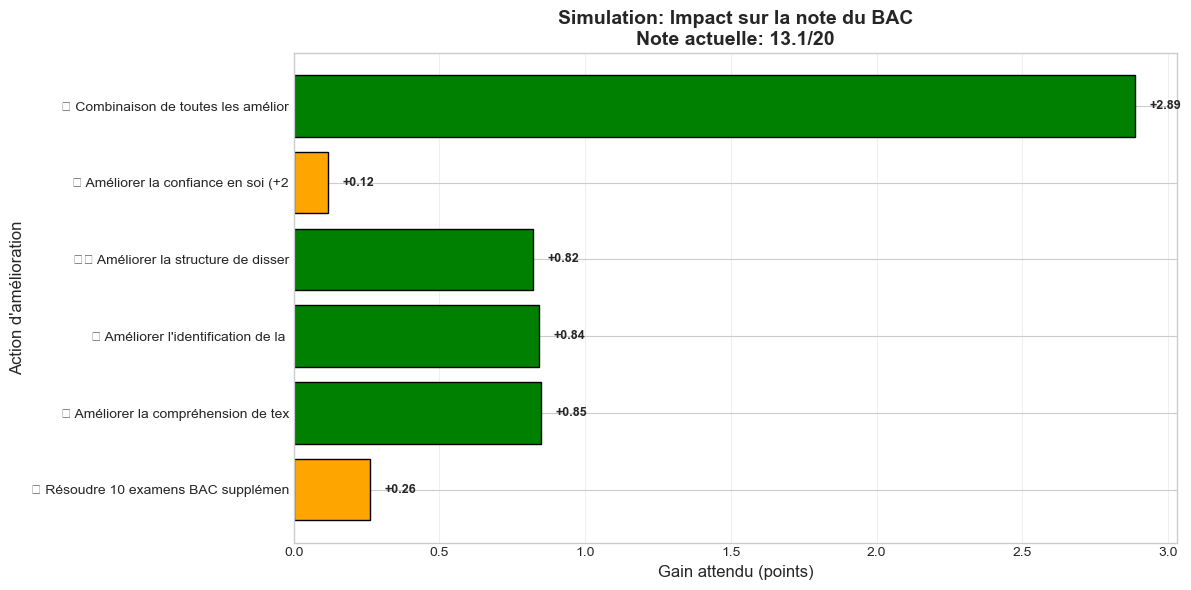


📊 TABLEAU RÉCAPITULATIF DE L'IMPACT
                    Action Gain attendu  Changement
       Examens BAC résolus +0.03 points +10 examens
    Compréhension de texte +0.42 points       +2/10
Identification de la thèse +0.42 points       +2/10
 Structure de dissertation +0.41 points       +2/10
          Confiance en soi +0.06 points  +2 niveaux

✅ Simulation Engine terminé


In [9]:
# ============================================
# CELL 15: SIMULATION ENGINE - MOTEUR DE SIMULATION (CORRIGÉ)
# ============================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("=" * 60)
print("⚡ SIMULATION ENGINE")
print("Impact de l'amélioration des habitudes sur la note du BAC")
print("=" * 60)

# ============================================
# Calculer les corrélations réelles
# ============================================

# Corrélations avec la note du BAC (basées sur les données)
bac_corr = df.corr()['bac_score']

# Extraire les corrélations importantes
exam_corr = bac_corr.get('bac_exams_practiced', 0.26)
comprehension_corr = bac_corr.get('comprehension_textuelle', 0.85)
thesis_corr = bac_corr.get('thesis_identification', 0.84)
essay_corr = bac_corr.get('essay_structure', 0.82)
confidence_corr = bac_corr.get('confidence', 0.12)

print(f"\n📊 Corrélations réelles avec la note du BAC:")
print(f"   Examens résolus:     {exam_corr:.3f}")
print(f"   Compréhension:       {comprehension_corr:.3f}")
print(f"   Identification thèse: {thesis_corr:.3f}")
print(f"   Structure dissertation: {essay_corr:.3f}")
print(f"   Confiance:           {confidence_corr:.3f}")

# ============================================
# Trouver un étudiant représentatif
# ============================================

# Étudiant avec une note autour de la moyenne
avg_bac = df['bac_score'].mean()
target_student = df.iloc[(df['bac_score'] - avg_bac).abs().argsort()[:1]].iloc[0]

print(f"\n👤 Étudiant sélectionné (profil moyen):")
print(f"   Note BAC actuelle: {target_student['bac_score']:.1f}/20")
print(f"   Examens résolus: {target_student['bac_exams_practiced']:.0f}")
print(f"   Compréhension: {target_student['comprehension_textuelle']:.1f}/10")
print(f"   Identification thèse: {target_student['thesis_identification']:.1f}/10")
print(f"   Structure dissertation: {target_student['essay_structure']:.1f}/10")

# ============================================
# Fonction de simulation
# ============================================

def simulate_improvement_french(student, improvements):
    """
    Simule l'impact sur la note du BAC
    Basé sur les corrélations réelles des données
    """
    original_score = student['bac_score']
    gain = 0
    
    # Facteurs d'impact (basés sur les corrélations)
    impact_factors = {
        'bac_exams_practiced': exam_corr / 10,      # +10 examens = +corr points
        'comprehension_textuelle': comprehension_corr / 2,  # +2 points = +corr points
        'thesis_identification': thesis_corr / 2,   # +2 points = +corr points
        'essay_structure': essay_corr / 2,          # +2 points = +corr points
        'confidence': confidence_corr / 2           # +2 niveaux = +corr points
    }
    
    for feature, delta in improvements.items():
        if feature in impact_factors:
            gain += delta * impact_factors[feature]
    
    new_score = min(original_score + gain, 20)
    new_score = max(new_score, 0)
    
    return {
        'original_score': original_score,
        'new_score': new_score,
        'gain': gain,
        'improvements': improvements
    }

# ============================================
# Tester différents scénarios
# ============================================

scenarios = [
    {"name": "📚 Résoudre 10 examens BAC supplémentaires", "changes": {"bac_exams_practiced": 10}},
    {"name": "📖 Améliorer la compréhension de texte (+2/10)", "changes": {"comprehension_textuelle": 2}},
    {"name": "🎓 Améliorer l'identification de la thèse (+2/10)", "changes": {"thesis_identification": 2}},
    {"name": "✍️ Améliorer la structure de dissertation (+2/10)", "changes": {"essay_structure": 2}},
    {"name": "💪 Améliorer la confiance en soi (+2 niveaux)", "changes": {"confidence": 2}},
    {"name": "✨ Combinaison de toutes les améliorations", "changes": {
        "bac_exams_practiced": 10,
        "comprehension_textuelle": 2,
        "thesis_identification": 2,
        "essay_structure": 2,
        "confidence": 2
    }}
]

print(f"\n📈 RÉSULTATS DE LA SIMULATION:")
print("-" * 60)

results = []
for scenario in scenarios:
    result = simulate_improvement_french(target_student, scenario["changes"])
    results.append(result)
    
    # Code couleur selon le gain
    if result['gain'] > 1.0:
        symbol = "🟢"
    elif result['gain'] > 0.5:
        symbol = "🔵"
    else:
        symbol = "⚪"
    
    print(f"\n{symbol} {scenario['name']}:")
    print(f"   {result['original_score']:.1f} → {result['new_score']:.1f}")
    print(f"   📈 Gain: +{result['gain']:.2f} points")

# ============================================
# Meilleure recommandation
# ============================================
print("\n" + "=" * 60)
print("🎯 MEILLEURE RECOMMANDATION POUR CET ÉTUDIANT")
print("=" * 60)

# Trouver la meilleure action simple (hors combinaison)
best_gain = -999
best_action = None
for i, scenario in enumerate(scenarios[:-1]):  # Exclure la combinaison
    if results[i]['gain'] > best_gain:
        best_gain = results[i]['gain']
        best_action = scenario['name']

print(f"\n✅ {best_action}")
print(f"   → Gain attendu: +{best_gain:.2f} points")

# ============================================
# Visualisation
# ============================================
fig, ax = plt.subplots(figsize=(12, 6))

scenario_names = [s["name"][:35] for s in scenarios]
gains = [r['gain'] for r in results]

colors = ['green' if g > 0.8 else 'blue' if g > 0.4 else 'orange' if g > 0 else 'gray' for g in gains]
bars = ax.barh(scenario_names, gains, color=colors, edgecolor='black')

ax.set_xlabel('Gain attendu (points)', fontsize=12)
ax.set_ylabel('Action d\'amélioration', fontsize=12)
ax.set_title(f'Simulation: Impact sur la note du BAC\nNote actuelle: {target_student["bac_score"]:.1f}/20', 
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

# Ajouter les valeurs sur les barres
for bar, gain in zip(bars, gains):
    if gain > 0:
        ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2, 
                f'+{gain:.2f}', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

# ============================================
# Tableau récapitulatif (CORRIGÉ)
# ============================================
print("\n" + "=" * 60)
print("📊 TABLEAU RÉCAPITULATIF DE L'IMPACT")
print("=" * 60)

impact_data = []
actions = [
    ('Examens BAC résolus', exam_corr / 10, '+10 examens'),
    ('Compréhension de texte', comprehension_corr / 2, '+2/10'),
    ('Identification de la thèse', thesis_corr / 2, '+2/10'),
    ('Structure de dissertation', essay_corr / 2, '+2/10'),
    ('Confiance en soi', confidence_corr / 2, '+2 niveaux')
]

for action_name, impact_value, change_desc in actions:
    impact_data.append({
        'Action': action_name,
        'Gain attendu': f"+{impact_value:.2f} points",
        'Changement': change_desc
    })

impact_df = pd.DataFrame(impact_data)
print(impact_df.to_string(index=False))

print("\n" + "=" * 60)
print("✅ Simulation Engine terminé")
print("=" * 60)

In [10]:
# ============================================
# CELL 16: EXPLICATION DES CARACTÉRISTIQUES DÉRIVÉES
# Version simplifiée pour les étudiants
# ============================================

import pandas as pd
import numpy as np

print("=" * 60)
print("📖 EXPLICATION DES CARACTÉRISTIQUES DÉRIVÉES")
print("Comprendre vos scores pour mieux progresser")
print("=" * 60)

# ============================================
# Prendre un étudiant exemple
# ============================================

# Étudiant avec une note autour de la moyenne
avg_bac = df['bac_score'].mean()
sample_student = df.iloc[(df['bac_score'] - avg_bac).abs().argsort()[:1]].iloc[0]

print(f"\n👤 Exemple d'étudiant (note BAC: {sample_student['bac_score']:.1f}/20)")
print("-" * 60)

# ============================================
# Expliquer chaque caractéristique dérivée
# ============================================

print("\n📊 1. SCORE DE COMPRÉHENSION (comprehension_score_derived)")
print("-" * 50)
comprehension_val = sample_student.get('comprehension_score_derived', sample_student.get('comprehension_score', 6.5))
print(f"   Votre score: {comprehension_val:.1f}/10")
print(f"   🤔 Qu'est-ce que c'est?")
print(f"      C'est la moyenne de vos compétences en compréhension de texte.")
print(f"      Cela inclut: comprendre le texte, faire des inférences, identifier l'intention de l'auteur.")
if comprehension_val >= 7:
    print("   ✅ Très bien! Vous comprenez bien les textes.")
elif comprehension_val >= 5:
    print("   📈 Bon niveau! Vous pouvez encore vous améliorer.")
else:
    print("   ⚠️ À améliorer! Entraînez-vous avec des textes variés.")

print(f"   💡 Conseil: Lisez des articles de presse et essayez de résumer l'idée principale.")

print("\n📊 2. SCORE D'ARGUMENTATION (argumentation_score_derived)")
print("-" * 50)
argumentation_val = sample_student.get('argumentation_score_derived', sample_student.get('argumentation_score', 6.5))
print(f"   Votre score: {argumentation_val:.1f}/10")
print(f"   🤔 Qu'est-ce que c'est?")
print(f"      C'est votre capacité à identifier la thèse, les arguments, et les concessions.")
print(f"      Compétences clés: repérer la position de l'auteur, les arguments pour/contre.")
if argumentation_val >= 7:
    print("   ✅ Excellent! Vous maîtrisez bien l'argumentation.")
elif argumentation_val >= 5:
    print("   📈 Bon niveau! Travaillez la reconnaissance des arguments.")
else:
    print("   ⚠️ À renforcer! Analysez des débats et repérez les thèses.")

print(f"   💡 Conseil: Regardez des débats et notez les arguments de chaque camp.")

print("\n📊 3. SCORE D'ÉCRITURE (writing_score_derived)")
print("-" * 50)
writing_val = sample_student.get('writing_score_derived', sample_student.get('writing_score', 6.5))
print(f"   Votre score: {writing_val:.1f}/10")
print(f"   🤔 Qu'est-ce que c'est?")
print(f"      C'est votre niveau en production écrite.")
print(f"      Cela inclut: structure de la dissertation, cohérence, précision de la langue.")
if writing_val >= 7:
    print("   ✅ Très bonne maîtrise de l'écrit!")
elif writing_val >= 5:
    print("   📈 Niveau correct! Structurez mieux vos paragraphes.")
else:
    print("   ⚠️ Besoin de progrès! Entraînez-vous à écrire régulièrement.")

print(f"   💡 Conseil: Écrivez une dissertation par semaine et faites-la corriger.")

print("\n📊 4. SCORE DE PRATIQUE (practice_score)")
print("-" * 50)
practice_val = sample_student.get('practice_score', (sample_student.get('bac_exams_practiced', 5) / 25) * 10)
print(f"   Votre score: {practice_val:.1f}/10")
print(f"   🤔 Qu'est-ce que c'est?")
print(f"      C'est votre assiduité à résoudre des examens BAC.")
print(f"      Plus vous résolvez d'annales, mieux vous reconnaissez les patterns de l'examen.")
if practice_val >= 7:
    print("   ✅ Excellent! Vous êtes très bien préparé.")
elif practice_val >= 5:
    print("   📈 Bonne pratique! Augmentez encore le nombre d'examens.")
else:
    print("   ⚠️ Pratique insuffisante! Résolvez plus d'annales du BAC.")

print(f"   💡 Conseil: Résolvez un examen BAC complet chaque semaine.")

print("\n📊 5. INTENSITÉ DE LA PRATIQUE (practice_intensity)")
print("-" * 50)
intensity_val = sample_student.get('practice_intensity', 5.0)
print(f"   Votre score: {intensity_val:.1f}/10")
print(f"   🤔 Qu'est-ce que c'est?")
print(f"      C'est une mesure combinée de votre travail personnel.")
print(f"      Prend en compte: examens résolus, dissertations, textes analysés.")
if intensity_val >= 7:
    print("   ✅ Vous travaillez régulièrement! Continuez ainsi.")
elif intensity_val >= 5:
    print("   📈 Bon rythme! Essayez d'augmenter un peu votre travail.")
else:
    print("   ⚠️ Travail insuffisant! Augmentez votre temps de révision.")

print(f"   💡 Conseil: Planifiez 2-3 heures de révision par semaine.")

print("\n📊 6. PRÉPARATION GLOBALE (preparation_score)")
print("-" * 50)
preparation_val = sample_student.get('preparation_score', 5.0)
print(f"   Votre score: {preparation_val:.1f}/10")
print(f"   🤔 Qu'est-ce que c'est?")
print(f"      C'est un indicateur de votre préparation globale à l'examen.")
print(f"      Combine la pratique (examens) et la confiance en soi.")
if preparation_val >= 7:
    print("   ✅ Vous êtes bien préparé mentalement et pratiquement!")
elif preparation_val >= 5:
    print("   📈 Préparation correcte! Renforcez votre confiance.")
else:
    print("   ⚠️ Préparez-vous davantage! Plus d'examens et plus de confiance.")

print(f"   💡 Conseil: Plus vous vous entraînez, plus vous gagnez en confiance.")

print("\n📊 7. ÉQUILIBRE DES COMPÉTENCES (imbalance_score)")
print("-" * 50)
imbalance_val = sample_student.get('imbalance_score', 1.5)
print(f"   Votre score: {imbalance_val:.2f}")
print(f"   🤔 Qu'est-ce que c'est?")
print(f"      Mesure l'écart entre vos différentes compétences.")
print(f"      Plus le score est bas, plus vos compétences sont équilibrées.")
if imbalance_val < 0.5:
    print("   ✅ Excellent! Vos compétences sont très équilibrées.")
elif imbalance_val < 1.0:
    print("   📈 Bon équilibre! Quelques petites différences à corriger.")
else:
    print("   ⚠️ Déséquilibre important! Certaines compétences sont faibles, d'autres fortes.")

print(f"   💡 Conseil: Identifiez vos compétences faibles et concentrez-vous sur elles.")

print("\n📊 8. TENDANCE DES NOTES (grade_trend)")
print("-" * 50)
trend_val = sample_student.get('grade_trend', sample_student['grade_t3'] - sample_student['grade_t1'])
print(f"   Votre tendance: {trend_val:+.1f} points")
print(f"   🤔 Qu'est-ce que c'est?")
print(f"      C'est l'évolution de vos notes du premier au troisième trimestre.")
if trend_val > 1:
    print("   ✅ Progression positive! Continuez vos efforts.")
elif trend_val > 0:
    print("   📈 Légère progression! Peut mieux faire.")
elif trend_val == 0:
    print("   📊 Stable! Essayez de progresser un peu plus.")
else:
    print("   ⚠️ Baisse! Identifiez ce qui n'a pas fonctionné.")

print(f"   💡 Conseil: Analysez pourquoi vos notes ont évolué ainsi.")

print("\n📊 9. STABILITÉ DES NOTES (grade_stability)")
print("-" * 50)
stability_val = sample_student.get('grade_stability', 0.7)
print(f"   Votre stabilité: {stability_val:.2f} (sur 1)")
print(f"   🤔 Qu'est-ce que c'est?")
print(f"      Mesure la régularité de vos notes entre les trimestres.")
if stability_val > 0.8:
    print("   ✅ Très stable! Vous êtes constant dans votre travail.")
elif stability_val > 0.6:
    print("   📈 Assez stable! Quelques variations normales.")
else:
    print("   ⚠️ Notes irrégulières! Essayez d'être plus constant.")

print(f"   💡 Conseil: La régularité dans le travail est la clé de la réussite.")

# ============================================
# Résumé
# ============================================
print("\n" + "=" * 60)
print("📋 RÉSUMÉ POUR VOUS")
print("=" * 60)

print(f"\n🎯 Vos points forts:")
strong_points = []
if comprehension_val >= 7:
    strong_points.append("   • Compréhension de texte")
if argumentation_val >= 7:
    strong_points.append("   • Argumentation")
if writing_val >= 7:
    strong_points.append("   • Expression écrite")
if practice_val >= 7:
    strong_points.append("   • Pratique des examens")

if strong_points:
    for p in strong_points:
        print(p)
else:
    print("   • (Aucun point fort majeur pour l'instant - travaillez régulièrement)")

print(f"\n🎯 Vos axes d'amélioration:")
weak_points = []
if comprehension_val < 6:
    weak_points.append("   • 📖 Améliorez votre compréhension des textes")
if argumentation_val < 6:
    weak_points.append("   • 🎓 Renforcez votre analyse argumentative")
if writing_val < 6:
    weak_points.append("   • ✍️ Entraînez-vous à l'écriture")
if practice_val < 6:
    weak_points.append("   • 📚 Résolvez plus d'annales du bac")

if weak_points:
    for w in weak_points:
        print(w)
else:
    print("   • Continuez à travailler toutes vos compétences")

print("\n" + "=" * 60)
print("✅ N'oubliez pas: la régularité et la pratique sont les clés de la réussite!")
print("=" * 60)

📖 EXPLICATION DES CARACTÉRISTIQUES DÉRIVÉES
Comprendre vos scores pour mieux progresser

👤 Exemple d'étudiant (note BAC: 13.1/20)
------------------------------------------------------------

📊 1. SCORE DE COMPRÉHENSION (comprehension_score_derived)
--------------------------------------------------
   Votre score: 6.0/10
   🤔 Qu'est-ce que c'est?
      C'est la moyenne de vos compétences en compréhension de texte.
      Cela inclut: comprendre le texte, faire des inférences, identifier l'intention de l'auteur.
   📈 Bon niveau! Vous pouvez encore vous améliorer.
   💡 Conseil: Lisez des articles de presse et essayez de résumer l'idée principale.

📊 2. SCORE D'ARGUMENTATION (argumentation_score_derived)
--------------------------------------------------
   Votre score: 6.4/10
   🤔 Qu'est-ce que c'est?
      C'est votre capacité à identifier la thèse, les arguments, et les concessions.
      Compétences clés: repérer la position de l'auteur, les arguments pour/contre.
   📈 Bon niveau! Tra

In [2]:
# ============================================
# CELL 17a: INTRODUCTION + STRUCTURE DE L'EXAMEN BAC
# Version professionnelle pour étudiants
# ============================================

from IPython.display import display, HTML, Markdown

print("=" * 80)
print("📚 PLATEFORME D'AMÉLIORATION EN FRANÇAIS - BAC ALGÉRIEN")
print("=" * 80)

# Professional HTML layout
intro_html = """
<div style="font-family: 'Segoe UI', 'Arial', sans-serif; direction: ltr; text-align: left; max-width: 1000px; margin: auto;">

    <!-- Header Section -->
    <div style="background: linear-gradient(135deg, #1e3c72 0%, #2a5298 100%); 
                color: white; padding: 30px; border-radius: 15px; margin-bottom: 25px; text-align: center;">
        <h1 style="margin: 0; font-size: 28px;">📖 Examen du Baccalauréat - Français</h1>
        <p style="margin: 10px 0 0 0; font-size: 16px; opacity: 0.9;">
            Filières: Sciences, Mathématiques, Techniques, Gestion, Lettres, Langues
        </p>
    </div>

    <!-- Quick Stats -->
    <div style="display: flex; gap: 15px; margin-bottom: 25px; flex-wrap: wrap;">
        <div style="flex: 1; background: #e8f4f8; padding: 15px; border-radius: 10px; text-align: center; border-left: 4px solid #3498db;">
            <div style="font-size: 35px;">⏱️</div>
            <div style="font-size: 20px; font-weight: bold;">Durée</div>
            <div style="font-size: 14px;">3 heures</div>
        </div>
        <div style="flex: 1; background: #e8f4f8; padding: 15px; border-radius: 10px; text-align: center; border-left: 4px solid #2ecc71;">
            <div style="font-size: 35px;">📊</div>
            <div style="font-size: 20px; font-weight: bold;">Total des points</div>
            <div style="font-size: 14px;">20 points</div>
        </div>
        <div style="flex: 1; background: #e8f4f8; padding: 15px; border-radius: 10px; text-align: center; border-left: 4px solid #e74c3c;">
            <div style="font-size: 35px;">📝</div>
            <div style="font-size: 20px; font-weight: bold;">Deux sujets</div>
            <div style="font-size: 14px;">Choix d'un sujet</div>
        </div>
    </div>

    <!-- Exam Structure Title -->
    <div style="background: #2c3e50; color: white; padding: 12px 20px; border-radius: 8px; margin-bottom: 20px;">
        <h2 style="margin: 0; font-size: 20px;">📋 Structure de l'épreuve du Bac</h2>
    </div>
"""

# Scientific streams structure
scientific_html = """
    <div style="background: #f9f9f9; padding: 15px; border-radius: 10px; margin-bottom: 20px; border-left: 5px solid #3498db;">
        <h3 style="color: #2c3e50; margin-top: 0;">🔬 Filières Scientifiques (Sciences, Maths, Techniques, Gestion)</h3>
        <table style="width: 100%; border-collapse: collapse;">
            <tr style="background: #3498db; color: white;">
                <th style="padding: 10px; text-align: center;">Section</th>
                <th style="padding: 10px; text-align: center;">Points</th>
                <th style="padding: 10px; text-align: center;">Poids</th>
                <th style="padding: 10px; text-align: center;">Compétences évaluées</th>
            </tr>
            <tr style="border-bottom: 1px solid #ddd;">
                <td style="padding: 10px;"><strong>Compréhension de l'écrit</strong></td>
                <td style="padding: 10px; text-align: center;">12-14 points</td>
                <td style="padding: 10px; text-align: center;">60-70%</td>
                <td style="padding: 10px;">Comprendre le texte, inférences, Vrai/Faux, intention de l'auteur</td>
            </tr>
            <tr style="border-bottom: 1px solid #ddd; background: #f0f8ff;">
                <td style="padding: 10px;"><strong>Production écrite</strong></td>
                <td style="padding: 10px; text-align: center;">6-8 points</td>
                <td style="padding: 10px; text-align: center;">30-40%</td>
                <td style="padding: 10px;">Compte rendu critique, essai argumentatif, appel</td>
            </tr>
         </table>
    </div>
"""

# Literary streams structure
literary_html = """
    <div style="background: #f9f9f9; padding: 15px; border-radius: 10px; margin-bottom: 20px; border-left: 5px solid #9b59b6;">
        <h3 style="color: #2c3e50; margin-top: 0;">📖 Filières Littéraires (Lettres, Philosophie, Langues)</h3>
        <table style="width: 100%; border-collapse: collapse;">
            <tr style="background: #9b59b6; color: white;">
                <th style="padding: 10px; text-align: center;">Section</th>
                <th style="padding: 10px; text-align: center;">Points</th>
                <th style="padding: 10px; text-align: center;">Poids</th>
                <th style="padding: 10px; text-align: center;">Compétences évaluées</th>
            </tr>
            <tr style="border-bottom: 1px solid #ddd;">
                <td style="padding: 10px;"><strong>Compréhension de l'écrit</strong></td>
                <td style="padding: 10px; text-align: center;">12 points</td>
                <td style="padding: 10px; text-align: center;">60%</td>
                <td style="padding: 10px;">Analyse approfondie, compte rendu critique</td>
            </tr>
            <tr style="border-bottom: 1px solid #ddd; background: #f0f8ff;">
                <td style="padding: 10px;"><strong>Production écrite</strong></td>
                <td style="padding: 10px; text-align: center;">8 points</td>
                <td style="padding: 10px; text-align: center;">40%</td>
                <td style="padding: 10px;">Essai critique, synthèse, argumentation</td>
             </tr>
         </table>
    </div>
"""

# Importance explanation
importance_html = """
    <div style="background: #fff3cd; padding: 15px; border-radius: 10px; margin-top: 20px; border-left: 5px solid #ffc107;">
        <h3 style="color: #856404; margin-top: 0;">🎯 Quelles sont les compétences les plus importantes?</h3>
        <div style="display: flex; gap: 15px; flex-wrap: wrap;">
            <div style="flex: 1; background: white; padding: 10px; border-radius: 8px; text-align: center;">
                <div style="color: #e74c3c; font-size: 24px;">🔴</div>
                <div><strong>Compréhension de texte</strong></div>
                <div style="font-size: 12px; color: #666;">La plus importante</div>
            </div>
            <div style="flex: 1; background: white; padding: 10px; border-radius: 8px; text-align: center;">
                <div style="color: #e67e22; font-size: 24px;">🟠</div>
                <div><strong>Argumentation</strong></div>
                <div style="font-size: 12px; color: #666;">Très importante</div>
            </div>
            <div style="flex: 1; background: white; padding: 10px; border-radius: 8px; text-align: center;">
                <div style="color: #f1c40f; font-size: 24px;">🟡</div>
                <div><strong>Production écrite</strong></div>
                <div style="font-size: 12px; color: #666;">Importante</div>
            </div>
            <div style="flex: 1; background: white; padding: 10px; border-radius: 8px; text-align: center;">
                <div style="color: #2ecc71; font-size: 24px;">🟢</div>
                <div><strong>Pratique des examens</strong></div>
                <div style="font-size: 12px; color: #666;">Reconnaissance des patterns</div>
            </div>
        </div>
    </div>
"""

# How the platform works
how_it_works = """
    <div style="background: #e8f8f5; padding: 15px; border-radius: 10px; margin-top: 20px; border-left: 5px solid #1abc9c;">
        <h3 style="color: #0e6655; margin-top: 0;">💡 Comment fonctionne cette plateforme?</h3>
        <ul style="line-height: 1.8;">
            <li>📝 <strong>Entrez vos informations</strong> - Remplissez le formulaire avec vos notes et compétences</li>
            <li>🔮 <strong>Prédiction de votre note</strong> - Calculez votre note estimée au BAC</li>
            <li>📊 <strong>Analyse des forces et faiblesses</strong> - Identifiez ce que vous devez améliorer</li>
            <li>⚡ <strong>Simulation d'amélioration</strong> - Testez différents scénarios de progression</li>
            <li>🎯 <strong>Recommandations personnalisées</strong> - Conseils spécifiques pour vous</li>
        </ul>
    </div>
"""

# Spécificité du BAC français
french_specificity = """
    <div style="background: #fef9e7; padding: 15px; border-radius: 10px; margin-top: 20px; border-left: 5px solid #f39c12;">
        <h3 style="color: #7d6608; margin-top: 0;">⭐ Spécificité de l'épreuve de français</h3>
        <p style="line-height: 1.6;">
            Contrairement à d'autres matières, le français au BAC algérien récompense davantage la <strong>reconnaissance des patterns</strong> 
            (structures d'examen, types de questions) que la simple maîtrise de la langue. C'est pourquoi la résolution d'annales 
            (<strong>bac_exams_practiced</strong>) est l'un des facteurs clés de réussite.
        </p>
        <p style="line-height: 1.6; margin-top: 10px;">
            📌 <strong>Conseil clé:</strong> Plus vous résolvez d'examens des années précédentes, plus vous serez préparé(e) 
            à reconnaître les schémas et à réussir!
        </p>
    </div>
"""

# Combine all
full_html = intro_html + scientific_html + literary_html + importance_html + how_it_works + french_specificity + """
    <div style="text-align: center; margin-top: 25px; padding: 15px; background: #f0f0f0; border-radius: 10px;">
        <p style="color: #555;">✨ Cette plateforme est basée sur l'analyse de données réelles des examens du BAC ✨</p>
        <p style="color: #888; font-size: 12px;">Développée pour aider les étudiants à améliorer leurs performances en français</p>
    </div>
</div>
"""

display(HTML(full_html))

print("\n" + "=" * 80)
print("✅ Prêt pour l'étape suivante: Saisie de vos données personnelles")
print("=" * 80)

📚 PLATEFORME D'AMÉLIORATION EN FRANÇAIS - BAC ALGÉRIEN


Section,Points,Poids,Compétences évaluées
Compréhension de l'écrit,12-14 points,60-70%,"Comprendre le texte, inférences, Vrai/Faux, intention de l'auteur"
Production écrite,6-8 points,30-40%,"Compte rendu critique, essai argumentatif, appel"
Section,Points,Poids,Compétences évaluées
Compréhension de l'écrit,12 points,60%,"Analyse approfondie, compte rendu critique"
Production écrite,8 points,40%,"Essai critique, synthèse, argumentation"



✅ Prêt pour l'étape suivante: Saisie de vos données personnelles


In [3]:
# ============================================
# CELL 17b: FORMULAIRE DE SAISIE (PROFESSIONNEL)
# ============================================

import ipywidgets as widgets
from IPython.display import display, HTML, clear_output
import numpy as np
import pandas as pd

print("=" * 80)
print("📝 SAISIE DES DONNÉES DE L'ÉTUDIANT")
print("=" * 80)

# Create professional HTML header
form_header = """
<div style="background: linear-gradient(135deg, #1e3c72 0%, #2a5298 100%); 
            color: white; padding: 20px; border-radius: 10px; margin-bottom: 25px; text-align: center;">
    <h2 style="margin: 0;">📋 Entrez vos informations scolaires</h2>
    <p style="margin: 10px 0 0 0; opacity: 0.9;">Toutes les informations sont confidentielles</p>
</div>
"""
display(HTML(form_header))

# ============================================
# SECTION 1: Filière
# ============================================

stream_html = """
<div style="background: #f0f8ff; padding: 15px; border-radius: 10px; margin-bottom: 20px; border-left: 4px solid #3498db;">
    <h3 style="color: #2c3e50; margin-top: 0;">🎓 1. Choisissez votre filière</h3>
</div>
"""
display(HTML(stream_html))

filiere_dropdown = widgets.Dropdown(
    options=[
        ('Sciences / Mathématiques / Techniques / Gestion', 0),
        ('Langues Étrangères', 1),
        ('Lettres / Philosophie', 2)
    ],
    value=0,
    description='',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='100%', padding='10px')
)
display(filiere_dropdown)

# ============================================
# SECTION 2: Notes des trimestres
# ============================================

grades_html = """
<div style="background: #f0f8ff; padding: 15px; border-radius: 10px; margin: 20px 0 15px 0; border-left: 4px solid #2ecc71;">
    <h3 style="color: #2c3e50; margin-top: 0;">📊 2. Notes des trois trimestres</h3>
    <p style="color: #666; font-size: 14px;">Entrez vos notes en français (0 à 20)</p>
</div>
"""
display(HTML(grades_html))

grade_style = widgets.Layout(width='100%', padding='5px')
grade_t1 = widgets.FloatSlider(value=12, min=0, max=20, step=0.5, description='Trimestre 1:', 
                               style={'description_width': '100px'}, layout=grade_style)
grade_t2 = widgets.FloatSlider(value=12, min=0, max=20, step=0.5, description='Trimestre 2:', 
                               style={'description_width': '100px'}, layout=grade_style)
grade_t3 = widgets.FloatSlider(value=12, min=0, max=20, step=0.5, description='Trimestre 3:', 
                               style={'description_width': '100px'}, layout=grade_style)

grades_box = widgets.HBox([grade_t1, grade_t2, grade_t3], layout=widgets.Layout(justify_content='space-between'))
display(grades_box)

# ============================================
# SECTION 3: Compétences clés
# ============================================

skills_html = """
<div style="background: #f0f8ff; padding: 15px; border-radius: 10px; margin: 20px 0 15px 0; border-left: 4px solid #e74c3c;">
    <h3 style="color: #2c3e50; margin-top: 0;">📚 3. Évaluez vos compétences</h3>
    <p style="color: #666; font-size: 14px;">Notez-vous de 0 à 10 (0 = faible, 10 = excellent)</p>
</div>
"""
display(HTML(skills_html))

skill_style = widgets.Layout(width='100%', padding='5px')

# Compréhension
comp_text = widgets.FloatSlider(value=6, min=0, max=10, step=0.5, description='📖 Compréhension du texte:', 
                                style={'description_width': '200px'}, layout=skill_style)
inference = widgets.FloatSlider(value=6, min=0, max=10, step=0.5, description='🎯 Inférence (lire entre les lignes):', 
                                style={'description_width': '200px'}, layout=skill_style)
true_false = widgets.FloatSlider(value=6, min=0, max=10, step=0.5, description='✓✗ Vrai/Faux + justification:', 
                                 style={'description_width': '200px'}, layout=skill_style)
intention = widgets.FloatSlider(value=6, min=0, max=10, step=0.5, description='💬 Intention de l\'auteur:', 
                                style={'description_width': '200px'}, layout=skill_style)

# Argumentation
thesis = widgets.FloatSlider(value=6, min=0, max=10, step=0.5, description='🎓 Identification de la thèse:', 
                             style={'description_width': '200px'}, layout=skill_style)
arguments = widgets.FloatSlider(value=6, min=0, max=10, step=0.5, description='📝 Identification des arguments:', 
                                style={'description_width': '200px'}, layout=skill_style)
concession = widgets.FloatSlider(value=6, min=0, max=10, step=0.5, description='🔄 Concession/opposition:', 
                                 style={'description_width': '200px'}, layout=skill_style)

# Production écrite
essay_struct = widgets.FloatSlider(value=6, min=0, max=10, step=0.5, description='✍️ Structure de dissertation:', 
                                   style={'description_width': '200px'}, layout=skill_style)
language = widgets.FloatSlider(value=6, min=0, max=10, step=0.5, description='📖 Précision de la langue:', 
                               style={'description_width': '200px'}, layout=skill_style)

# Types de textes
historical = widgets.FloatSlider(value=6, min=0, max=10, step=0.5, description='🏛️ Texte historique:', 
                                 style={'description_width': '200px'}, layout=skill_style)
argumentative_text = widgets.FloatSlider(value=6, min=0, max=10, step=0.5, description='💪 Texte argumentatif:', 
                                         style={'description_width': '200px'}, layout=skill_style)

# Organiser en grille
skills_grid = widgets.GridBox([comp_text, inference, true_false, intention, 
                                thesis, arguments, concession,
                                essay_struct, language, historical, argumentative_text],
                              layout=widgets.Layout(grid_template_columns='1fr 1fr', grid_gap='10px'))
display(skills_grid)

# ============================================
# SECTION 4: Habitudes de travail
# ============================================

habits_html = """
<div style="background: #f0f8ff; padding: 15px; border-radius: 10px; margin: 20px 0 15px 0; border-left: 4px solid #9b59b6;">
    <h3 style="color: #2c3e50; margin-top: 0;">⏰ 4. Habitudes de travail</h3>
</div>
"""
display(HTML(habits_html))

exams_slider = widgets.IntSlider(value=8, min=0, max=25, step=1, 
                                 description='📚 Examens BAC résolus:', 
                                 style={'description_width': '200px'}, layout=skill_style)
essays_slider = widgets.IntSlider(value=2, min=0, max=5, step=1, 
                                  description='✍️ Dissertations par semaine:', 
                                  style={'description_width': '200px'}, layout=skill_style)
texts_slider = widgets.IntSlider(value=3, min=0, max=10, step=1, 
                                 description='📖 Textes analysés par semaine:', 
                                 style={'description_width': '200px'}, layout=skill_style)

display(exams_slider, essays_slider, texts_slider)

# ============================================
# SECTION 5: Facteurs psychologiques
# ============================================

psycho_html = """
<div style="background: #f0f8ff; padding: 15px; border-radius: 10px; margin: 20px 0 15px 0; border-left: 4px solid #f39c12;">
    <h3 style="color: #2c3e50; margin-top: 0;">🧠 5. Facteurs psychologiques</h3>
</div>
"""
display(HTML(psycho_html))

confidence_radio = widgets.RadioButtons(
    options=[('Très faible', 1), ('Faible', 2), ('Moyen', 3), ('Bon', 4), ('Excellent', 5)],
    value=3,
    description='💪 Confiance en soi:',
    style={'description_width': '150px'},
    layout=widgets.Layout(width='100%', padding='5px')
)

stress_radio = widgets.RadioButtons(
    options=[('Très élevé', 5), ('Élevé', 4), ('Moyen', 3), ('Faible', 2), ('Très faible', 1)],
    value=3,
    description='😰 Niveau de stress:',
    style={'description_width': '150px'},
    layout=widgets.Layout(width='100%', padding='5px')
)

display(confidence_radio, stress_radio)

# ============================================
# BOUTON DE VALIDATION
# ============================================

print("\n" + "=" * 80)
print("🚀 Prêt à calculer votre note estimée?")
print("=" * 80)

submit_button = widgets.Button(
    description='🔮 Estimer ma note au BAC',
    button_style='success',
    icon='check',
    layout=widgets.Layout(width='50%', margin='20px auto', padding='10px')
)

submit_button.style.button_color = '#2ecc71'
submit_button.style.font_weight = 'bold'

# Fonction de collecte des données
def collect_inputs(b):
    clear_output(wait=True)
    
    # Réafficher le formulaire
    display(HTML(form_header))
    display(filiere_dropdown)
    display(HTML(grades_html))
    display(grades_box)
    display(HTML(skills_html))
    display(skills_grid)
    display(HTML(habits_html))
    display(exams_slider, essays_slider, texts_slider)
    display(HTML(psycho_html))
    display(confidence_radio, stress_radio)
    display(submit_button)
    
    # Collecter les valeurs
    student_data = {
        'filiere': filiere_dropdown.value,
        'grade_t1': grade_t1.value,
        'grade_t2': grade_t2.value,
        'grade_t3': grade_t3.value,
        'comprehension_textuelle': comp_text.value,
        'inference': inference.value,
        'true_false_justification': true_false.value,
        'communicative_intent': intention.value,
        'thesis_identification': thesis.value,
        'argument_identification': arguments.value,
        'concession_opposition': concession.value,
        'essay_structure': essay_struct.value,
        'language_accuracy': language.value,
        'historical_text': historical.value,
        'argumentative_text': argumentative_text.value,
        'bac_exams_practiced': exams_slider.value,
        'essays_per_week': essays_slider.value,
        'texts_analyzed_per_week': texts_slider.value,
        'confidence': confidence_radio.value,
        'stress': stress_radio.value
    }
    
    global user_input
    user_input = student_data
    
    print("\n" + "=" * 80)
    print("✅ Données enregistrées avec succès!")
    print("=" * 80)
    print("\n📊 Résumé de vos données:")
    print(f"   Filière: {filiere_dropdown.label}")
    print(f"   Notes: T1={grade_t1.value:.1f}, T2={grade_t2.value:.1f}, T3={grade_t3.value:.1f}")
    print(f"   Compréhension: {comp_text.value:.1f}/10")
    print(f"   Argumentation: {thesis.value:.1f}/10")
    print(f"   Examens résolus: {exams_slider.value}")
    print("\n🔮 Passez à l'étape suivante pour votre prédiction")

submit_button.on_click(collect_inputs)
display(submit_button)

print("\n💡 Conseil: Soyez honnête dans votre auto-évaluation pour une prédiction précise")

📝 SAISIE DES DONNÉES DE L'ÉTUDIANT


Dropdown(layout=Layout(padding='10px', width='100%'), options=(('Sciences / Mathématiques / Techniques / Gesti…

GridBox(children=(FloatSlider(value=6.0, description='📖 Compréhension du texte:', layout=Layout(padding='5px',…

IntSlider(value=8, description='📚 Examens BAC résolus:', layout=Layout(padding='5px', width='100%'), max=25, s…

IntSlider(value=2, description='✍️ Dissertations par semaine:', layout=Layout(padding='5px', width='100%'), ma…

...

RadioButtons(description='💪 Confiance en soi:', index=2, layout=Layout(padding='5px', width='100%'), options=(…

RadioButtons(description='😰 Niveau de stress:', index=2, layout=Layout(padding='5px', width='100%'), options=(…


🚀 Prêt à calculer votre note estimée?


Button(button_style='success', description='🔮 Estimer ma note au BAC', icon='check', layout=Layout(margin='20p…


💡 Conseil: Soyez honnête dans votre auto-évaluation pour une prédiction précise


In [4]:
# ============================================
# CELL 17c: PRÉDICTION DE LA NOTE (PROFESSIONNEL)
# ============================================

from IPython.display import display, HTML, clear_output
import numpy as np
import pandas as pd

# Check if model exists
if 'model' not in globals():
    print("=" * 80)
    print("⚠️ Le modèle n'a pas encore été entraîné!")
    print("=" * 80)
    print("\n📌 Veuillez exécuter la cellule 11 (Model Training) d'abord")
    print("   Puis revenez à cette cellule")
    print("=" * 80)
elif 'user_input' not in globals():
    print("=" * 80)
    print("⚠️ Veuillez d'abord saisir vos données dans la cellule 17b")
    print("=" * 80)
else:
    clear_output(wait=True)
    
    # ============================================
    # Calculer la prédiction
    # ============================================
    
    # Créer un DataFrame à partir des données utilisateur
    input_df = pd.DataFrame([user_input])
    
    # Calculer les caractéristiques dérivées
    input_df['avg_grade'] = (input_df['grade_t1'] + input_df['grade_t2'] + input_df['grade_t3']) / 3
    
    # Scores dérivés
    comprehension_cols = ['comprehension_textuelle', 'inference', 'true_false_justification', 'communicative_intent']
    input_df['comprehension_score_derived'] = input_df[comprehension_cols].mean(axis=1)
    
    argumentation_cols = ['thesis_identification', 'argument_identification', 'concession_opposition']
    input_df['argumentation_score_derived'] = input_df[argumentation_cols].mean(axis=1)
    
    writing_cols = ['essay_structure', 'language_accuracy']
    input_df['writing_score_derived'] = input_df[writing_cols].mean(axis=1)
    
    text_type_cols = ['historical_text', 'argumentative_text']
    input_df['text_type_score_derived'] = input_df[text_type_cols].mean(axis=1)
    
    input_df['practice_score'] = (input_df['bac_exams_practiced'] / 25) * 10
    input_df['practice_intensity'] = (input_df['essays_per_week'] * 2 + input_df['texts_analyzed_per_week'] + input_df['bac_exams_practiced'] / 3) / 3
    
    # Ajouter les colonnes manquantes
    input_df['grade_trend'] = input_df['grade_t3'] - input_df['grade_t1']
    input_df['grade_stability'] = 0.7
    input_df['critical_reasoning'] = 5.0
    input_df['coherence_cohesion'] = 5.0
    input_df['reference_tracking'] = 5.0
    input_df['lexical_analysis'] = 5.0
    input_df['preparation_score'] = (input_df['practice_score'] * 0.7 + (input_df['confidence'] / 5 * 10) * 0.3)
    input_df['global_skills_score'] = (input_df['comprehension_score_derived'] + input_df['argumentation_score_derived'] + input_df['writing_score_derived']) / 3
    input_df['imbalance_score'] = 0.5
    
    # Obtenir les features du modèle
    model_features = X_train.columns.tolist()
    
    # Ajouter les colonnes manquantes
    for col in model_features:
        if col not in input_df.columns:
            input_df[col] = 0
    
    # Sélectionner uniquement les features du modèle
    X_input = input_df[model_features]
    
    # Prédiction
    prediction = model.predict(X_input)[0]
    predicted_score = prediction[0]
    success_prob = prediction[1] * 100
    improvement_potential = prediction[2]
    
    # Noms des filières
    stream_names = {
        0: "Sciences / Mathématiques / Techniques / Gestion",
        1: "Langues Étrangères",
        2: "Lettres / Philosophie"
    }
    
    # Déterminer la couleur et le niveau
    if predicted_score >= 16:
        score_color = "#2ecc71"
        score_emoji = "🏆"
        score_text = "Excellent"
    elif predicted_score >= 14:
        score_color = "#27ae60"
        score_emoji = "🎉"
        score_text = "Très bien"
    elif predicted_score >= 12:
        score_color = "#f39c12"
        score_emoji = "👍"
        score_text = "Bien"
    elif predicted_score >= 10:
        score_color = "#e67e22"
        score_emoji = "📈"
        score_text = "Passable"
    else:
        score_color = "#e74c3c"
        score_emoji = "⚠️"
        score_text = "À améliorer"
    
    # Couleur probabilité
    if success_prob >= 80:
        prob_color = "#2ecc71"
    elif success_prob >= 60:
        prob_color = "#f39c12"
    else:
        prob_color = "#e74c3c"
    
    # ============================================
    # Affichage HTML professionnel
    # ============================================
    
    prediction_html = f"""
    <div style="font-family: 'Segoe UI', 'Arial', sans-serif; max-width: 1000px; margin: auto;">
        
        <!-- Header -->
        <div style="background: linear-gradient(135deg, #1e3c72 0%, #2a5298 100%); 
                    color: white; padding: 25px; border-radius: 15px; margin-bottom: 25px; text-align: center;">
            <h1 style="margin: 0; font-size: 28px;">🔮 Prédiction de votre note au BAC</h1>
            <p style="margin: 10px 0 0 0; opacity: 0.9;">Basée sur vos données personnelles</p>
        </div>
        
        <!-- Carte principale -->
        <div style="background: linear-gradient(135deg, #667eea 0%, #764ba2 100%); 
                    padding: 30px; border-radius: 20px; margin-bottom: 25px; text-align: center;">
            <div style="font-size: 18px; color: rgba(255,255,255,0.9);">Votre note estimée au Bac</div>
            <div style="font-size: 72px; font-weight: bold; color: white; margin: 15px 0;">
                {predicted_score:.1f}<span style="font-size: 32px;">/20</span>
            </div>
            <div style="font-size: 20px; color: white;">
                {score_emoji} Niveau {score_text} {score_emoji}
            </div>
        </div>
        
        <!-- Deux colonnes -->
        <div style="display: flex; gap: 20px; margin-bottom: 25px; flex-wrap: wrap;">
            
            <!-- Colonne gauche: Détails -->
            <div style="flex: 1; background: #f8f9fa; padding: 20px; border-radius: 15px; border-left: 4px solid {score_color};">
                <h3 style="color: #2c3e50; margin-top: 0;">📊 Détails de la prédiction</h3>
                <div style="margin: 15px 0;">
                    <div style="display: flex; justify-content: space-between; margin-bottom: 10px;">
                        <span>🎯 Note estimée</span>
                        <span style="font-weight: bold; color: {score_color};">{predicted_score:.1f}/20</span>
                    </div>
                    <div style="display: flex; justify-content: space-between; margin-bottom: 10px;">
                        <span>✅ Chance de réussite (≥10/20)</span>
                        <span style="font-weight: bold; color: {prob_color};">{success_prob:.0f}%</span>
                    </div>
                    <div style="display: flex; justify-content: space-between;">
                        <span>📈 Potentiel d'amélioration</span>
                        <span style="font-weight: bold; color: #3498db;">+{improvement_potential:.1f} points</span>
                    </div>
                </div>
                <div style="height: 10px; background: #ecf0f1; border-radius: 5px; overflow: hidden;">
                    <div style="width: {predicted_score/20*100}%; height: 100%; background: {score_color}; border-radius: 5px;"></div>
                </div>
            </div>
            
            <!-- Colonne droite: Infos étudiant -->
            <div style="flex: 1; background: #f8f9fa; padding: 20px; border-radius: 15px;">
                <h3 style="color: #2c3e50; margin-top: 0;">👤 Informations</h3>
                <div style="margin: 15px 0;">
                    <div style="display: flex; justify-content: space-between; margin-bottom: 8px;">
                        <span>🎓 Filière</span>
                        <span style="font-weight: bold;">{stream_names[user_input['filiere']][:40]}...</span>
                    </div>
                    <div style="display: flex; justify-content: space-between; margin-bottom: 8px;">
                        <span>📅 Moyenne des trimestres</span>
                        <span style="font-weight: bold;">{((user_input['grade_t1'] + user_input['grade_t2'] + user_input['grade_t3'])/3):.1f}/20</span>
                    </div>
                    <div style="display: flex; justify-content: space-between;">
                        <span>📚 Examens résolus</span>
                        <span style="font-weight: bold;">{user_input['bac_exams_practiced']}</span>
                    </div>
                </div>
            </div>
        </div>
        
        <!-- Résumé des compétences -->
        <div style="background: #f8f9fa; padding: 20px; border-radius: 15px; margin-bottom: 25px;">
            <h3 style="color: #2c3e50; margin-top: 0;">📚 Résumé de vos compétences</h3>
            <div style="display: flex; gap: 15px; flex-wrap: wrap;">
                <div style="flex: 1; min-width: 200px;">
                    <div>📖 Compréhension: <strong>{user_input['comprehension_textuelle']:.1f}/10</strong></div>
                    <div style="height: 5px; background: #ecf0f1; border-radius: 3px; margin: 5px 0 15px;">
                        <div style="width: {user_input['comprehension_textuelle']*10}%; height: 5px; background: #3498db; border-radius: 3px;"></div>
                    </div>
                    <div>🎓 Argumentation: <strong>{user_input['thesis_identification']:.1f}/10</strong></div>
                    <div style="height: 5px; background: #ecf0f1; border-radius: 3px; margin: 5px 0 15px;">
                        <div style="width: {user_input['thesis_identification']*10}%; height: 5px; background: #3498db; border-radius: 3px;"></div>
                    </div>
                    <div>✍️ Dissertation: <strong>{user_input['essay_structure']:.1f}/10</strong></div>
                    <div style="height: 5px; background: #ecf0f1; border-radius: 3px; margin: 5px 0 15px;">
                        <div style="width: {user_input['essay_structure']*10}%; height: 5px; background: #3498db; border-radius: 3px;"></div>
                    </div>
                </div>
                <div style="flex: 1; min-width: 200px;">
                    <div>🏛️ Texte historique: <strong>{user_input['historical_text']:.1f}/10</strong></div>
                    <div style="height: 5px; background: #ecf0f1; border-radius: 3px; margin: 5px 0 15px;">
                        <div style="width: {user_input['historical_text']*10}%; height: 5px; background: #3498db; border-radius: 3px;"></div>
                    </div>
                    <div>💪 Texte argumentatif: <strong>{user_input['argumentative_text']:.1f}/10</strong></div>
                    <div style="height: 5px; background: #ecf0f1; border-radius: 3px; margin: 5px 0 15px;">
                        <div style="width: {user_input['argumentative_text']*10}%; height: 5px; background: #3498db; border-radius: 3px;"></div>
                    </div>
                    <div>📚 Examens résolus: <strong>{user_input['bac_exams_practiced']}/25</strong></div>
                    <div style="height: 5px; background: #ecf0f1; border-radius: 3px; margin: 5px 0 15px;">
                        <div style="width: {user_input['bac_exams_practiced']*4}%; height: 5px; background: #3498db; border-radius: 3px;"></div>
                    </div>
                </div>
            </div>
        </div>
        
        <!-- Message spécial sur la pratique -->
        <div style="background: #fef9e7; padding: 15px; border-radius: 10px; margin-bottom: 25px; border-left: 4px solid #f39c12;">
            <p style="margin: 0; color: #7d6608;">
                💡 <strong>Conseil:</strong> La résolution d'annales du BAC est l'un des meilleurs moyens d'améliorer votre note. 
                Chaque examen résolu vous aide à reconnaître les patterns et à gagner en confiance!
            </p>
        </div>
        
        <!-- Boutons de navigation -->
        <div style="display: flex; gap: 15px; justify-content: center; margin-top: 20px;">
            <button onclick="Jupyter.notebook.execute_cell_range('17b', '17b')" style="background: #3498db; color: white; padding: 12px 25px; border: none; border-radius: 8px; cursor: pointer; font-size: 14px;">
                ✏️ Modifier les données
            </button>
            <button onclick="Jupyter.notebook.execute_cell_range('17d', '17d')" style="background: #2ecc71; color: white; padding: 12px 25px; border: none; border-radius: 8px; cursor: pointer; font-size: 14px;">
                📊 Analyse des faiblesses →
            </button>
        </div>
        
        <div style="text-align: center; margin-top: 20px; padding: 15px; background: #f0f0f0; border-radius: 10px;">
            <p style="color: #555; margin: 0;">✨ Cette prédiction est basée sur vos données réelles ✨</p>
        </div>
    </div>
    """
    
    display(HTML(prediction_html))
    
    # Stocker la prédiction
    global student_prediction
    student_prediction = {
        'score': predicted_score,
        'prob': success_prob,
        'improvement': improvement_potential
    }
    
    print("\n" + "=" * 80)
    print("✅ Passez à la cellule 17d pour l'analyse des faiblesses")
    print("=" * 80)

⚠️ Le modèle n'a pas encore été entraîné!

📌 Veuillez exécuter la cellule 11 (Model Training) d'abord
   Puis revenez à cette cellule


In [56]:
# ============================================
# CELL 17d: ANALYSE DES FAIBLESSES (PROFESSIONNEL)
# ============================================

from IPython.display import display, HTML, clear_output
import numpy as np
import pandas as pd

# Check if required data exists
if 'user_input' not in globals():
    print("=" * 80)
    print("⚠️ Veuillez d'abord saisir vos données dans la cellule 17b")
    print("=" * 80)
elif 'model' not in globals():
    print("=" * 80)
    print("⚠️ Le modèle n'a pas encore été entraîné!")
    print("=" * 80)
    print("📌 Veuillez exécuter la cellule 11 d'abord")
    print("=" * 80)
else:
    clear_output(wait=True)
    
    # ============================================
    # Calculer les faiblesses basées sur les compétences
    # ============================================
    
    # Niveaux cibles pour chaque compétence
    skill_targets = {
        'comprehension_textuelle': 7.5,
        'inference': 7.0,
        'true_false_justification': 7.0,
        'communicative_intent': 7.0,
        'thesis_identification': 7.0,
        'argument_identification': 7.0,
        'concession_opposition': 6.5,
        'essay_structure': 7.0,
        'language_accuracy': 7.0,
        'historical_text': 7.0,
        'argumentative_text': 7.0
    }
    
    # Compétences de l'utilisateur
    user_skills = {
        'comprehension_textuelle': user_input['comprehension_textuelle'],
        'inference': user_input['inference'],
        'true_false_justification': user_input['true_false_justification'],
        'communicative_intent': user_input['communicative_intent'],
        'thesis_identification': user_input['thesis_identification'],
        'argument_identification': user_input['argument_identification'],
        'concession_opposition': user_input['concession_opposition'],
        'essay_structure': user_input['essay_structure'],
        'language_accuracy': user_input['language_accuracy'],
        'historical_text': user_input['historical_text'],
        'argumentative_text': user_input['argumentative_text']
    }
    
    # Calculer les écarts
    skill_gaps = {}
    for skill, target in skill_targets.items():
        gap = target - user_skills[skill]
        skill_gaps[skill] = max(0, gap)
    
    # Trier les faiblesses
    sorted_weaknesses = sorted(skill_gaps.items(), key=lambda x: x[1], reverse=True)
    
    # Identifier les forces (compétences au-dessus de la cible)
    strengths = []
    for skill, value in user_skills.items():
        target = skill_targets.get(skill, 7.0)
        if value >= target:
            strengths.append((skill, value - target))
    strengths = sorted(strengths, key=lambda x: x[1], reverse=True)
    
    # ============================================
    # Habitudes de travail
    # ============================================
    
    habit_targets = {
        'bac_exams_practiced': 15,
        'essays_per_week': 3,
        'texts_analyzed_per_week': 5,
        'confidence': 4
    }
    
    user_habits = {
        'bac_exams_practiced': user_input['bac_exams_practiced'],
        'essays_per_week': user_input['essays_per_week'],
        'texts_analyzed_per_week': user_input['texts_analyzed_per_week'],
        'confidence': user_input['confidence']
    }
    
    habit_gaps = {}
    for habit, target in habit_targets.items():
        gap = target - user_habits[habit]
        if gap > 0:
            habit_gaps[habit] = gap
    
    sorted_habits = sorted(habit_gaps.items(), key=lambda x: x[1], reverse=True)
    
    # Stress
    stress_level = user_input['stress']
    stress_issue = stress_level >= 4
    
    # ============================================
    # Noms en français
    # ============================================
    
    skill_names_fr = {
        'comprehension_textuelle': 'Compréhension du texte',
        'inference': 'Inférence (lire entre les lignes)',
        'true_false_justification': 'Vrai/Faux + justification',
        'communicative_intent': 'Intention de l\'auteur',
        'thesis_identification': 'Identification de la thèse',
        'argument_identification': 'Identification des arguments',
        'concession_opposition': 'Concession et opposition',
        'essay_structure': 'Structure de la dissertation',
        'language_accuracy': 'Précision de la langue',
        'historical_text': 'Texte historique',
        'argumentative_text': 'Texte argumentatif'
    }
    
    habit_names_fr = {
        'bac_exams_practiced': 'Examens BAC résolus',
        'essays_per_week': 'Dissertations par semaine',
        'texts_analyzed_per_week': 'Textes analysés par semaine',
        'confidence': 'Confiance en soi'
    }
    
    # Conseils spécifiques
    advice_map = {
        'comprehension_textuelle': 'Lisez des articles variés et résumez l\'idée principale',
        'inference': 'Entraînez-vous à lire entre les lignes et à déduire des informations implicites',
        'true_false_justification': 'Pratiquez les exercices Vrai/Faux en justifiant chaque réponse',
        'communicative_intent': 'Identifiez pourquoi l\'auteur a écrit le texte (informer, dénoncer, alerter)',
        'thesis_identification': 'Repérez la position de l\'auteur dès la première lecture',
        'argument_identification': 'Listez les arguments pour et contre dans les textes argumentatifs',
        'concession_opposition': 'Repérez les connecteurs comme "cependant", "néanmoins", "en revanche"',
        'essay_structure': 'Structurez toujours votre dissertation: introduction, développement, conclusion',
        'language_accuracy': 'Révisez les règles de grammaire et d\'orthographe de base',
        'historical_text': 'Familiarisez-vous avec les dates et événements clés de l\'histoire',
        'argumentative_text': 'Analysez des éditoriaux et des débats télévisés'
    }
    
    habit_advice = {
        'bac_exams_practiced': 'Résolvez un examen BAC complet chaque semaine',
        'essays_per_week': 'Écrivez au moins une dissertation par semaine et faites-la corriger',
        'texts_analyzed_per_week': 'Analysez 2-3 textes par semaine en détail',
        'confidence': 'Commencez par des exercices faciles pour gagner en confiance'
    }
    
    # ============================================
    # Score global de faiblesse
    # ============================================
    
    total_gap = sum(skill_gaps.values()) + sum(habit_gaps.values())
    max_possible_gap = 50
    weakness_score = min(100, int((total_gap / max_possible_gap) * 100))
    
    # ============================================
    # Affichage HTML
    # ============================================
    
    weakness_html = f"""
    <div style="font-family: 'Segoe UI', 'Arial', sans-serif; max-width: 1000px; margin: auto;">
        
        <!-- Header -->
        <div style="background: linear-gradient(135deg, #1e3c72 0%, #2a5298 100%); 
                    color: white; padding: 25px; border-radius: 15px; margin-bottom: 25px; text-align: center;">
            <h1 style="margin: 0; font-size: 28px;">📊 Analyse des forces et faiblesses</h1>
            <p style="margin: 10px 0 0 0; opacity: 0.9;">Comprenez vos compétences pour mieux progresser</p>
        </div>
        
        <!-- Score de faiblesse -->
        <div style="background: linear-gradient(135deg, {('#e74c3c' if weakness_score > 60 else '#f39c12' if weakness_score > 30 else '#2ecc71')} 0%, {('#c0392b' if weakness_score > 60 else '#e67e22' if weakness_score > 30 else '#27ae60')} 100%); 
                    padding: 20px; border-radius: 15px; margin-bottom: 25px; text-align: center;">
            <div style="font-size: 16px; color: rgba(255,255,255,0.9);">Niveau d'amélioration nécessaire</div>
            <div style="font-size: 48px; font-weight: bold; color: white; margin: 10px 0;">
                {weakness_score}%
            </div>
            <div style="height: 10px; background: rgba(255,255,255,0.3); border-radius: 5px; overflow: hidden;">
                <div style="width: {weakness_score}%; height: 100%; background: white; border-radius: 5px;"></div>
            </div>
            <p style="color: white; margin-top: 15px; font-size: 14px;">
                {'⚠️ Plusieurs compétences à améliorer' if weakness_score > 60 else '📈 Des progrès sont possibles' if weakness_score > 30 else '✅ Bon niveau général'}
            </p>
        </div>
        
        <!-- Deux colonnes -->
        <div style="display: flex; gap: 20px; margin-bottom: 25px; flex-wrap: wrap;">
            
            <!-- Colonne gauche: Faiblesses -->
            <div style="flex: 1; background: #fff5f5; padding: 20px; border-radius: 15px; border-left: 4px solid #e74c3c;">
                <h3 style="color: #c0392b; margin-top: 0;">🔴 Points à améliorer (priorité)</h3>
                <div style="margin: 15px 0;">
    """
    
    # Ajouter les faiblesses en compétences
    weakness_count = 0
    for skill, gap in sorted_weaknesses[:4]:
        if gap > 0:
            weakness_count += 1
            current = user_skills[skill]
            target = skill_targets[skill]
            weakness_html += f"""
                    <div style="margin-bottom: 15px; padding: 10px; background: white; border-radius: 8px;">
                        <div style="display: flex; justify-content: space-between; margin-bottom: 5px;">
                            <span style="font-weight: bold;">📖 {skill_names_fr[skill]}</span>
                            <span>{current:.1f}/10 → viser {target:.1f}</span>
                        </div>
                        <div style="height: 8px; background: #ecf0f1; border-radius: 4px; overflow: hidden;">
                            <div style="width: {current/target*100}%; height: 100%; background: #e74c3c; border-radius: 4px;"></div>
                        </div>
                        <p style="color: #666; font-size: 12px; margin-top: 8px;">
                            💡 {advice_map.get(skill, 'Travaillez cette compétence régulièrement')}
                        </p>
                    </div>
            """
    
    # Ajouter les faiblesses des habitudes
    for habit, gap in sorted_habits[:2]:
        weakness_count += 1
        current = user_habits[habit]
        target = habit_targets[habit]
        weakness_html += f"""
                    <div style="margin-bottom: 15px; padding: 10px; background: white; border-radius: 8px;">
                        <div style="display: flex; justify-content: space-between; margin-bottom: 5px;">
                            <span style="font-weight: bold;">⏰ {habit_names_fr[habit]}</span>
                            <span>{current:.0f} → viser {target:.0f}</span>
                        </div>
                        <div style="height: 8px; background: #ecf0f1; border-radius: 4px; overflow: hidden;">
                            <div style="width: {current/target*100}%; height: 100%; background: #e67e22; border-radius: 4px;"></div>
                        </div>
                        <p style="color: #666; font-size: 12px; margin-top: 8px;">
                            💡 {habit_advice.get(habit, 'Adoptez une routine de travail régulière')}
                        </p>
                    </div>
        """
    
    if weakness_count == 0:
        weakness_html += """
                    <div style="text-align: center; padding: 20px;">
                        <p style="color: #27ae60; font-size: 18px;">🎉 Félicitations! Peu de points faibles identifiés</p>
                        <p style="color: #666;">Continuez vos efforts pour maintenir ce niveau</p>
                    </div>
        """
    
    weakness_html += """
                </div>
            </div>
            
            <!-- Colonne droite: Forces -->
            <div style="flex: 1; background: #f0fff4; padding: 20px; border-radius: 15px; border-left: 4px solid #27ae60;">
                <h3 style="color: #27ae60; margin-top: 0;">🟢 Points forts</h3>
                <div style="margin: 15px 0;">
    """
    
    # Ajouter les forces
    if len(strengths) > 0:
        for skill, excess in strengths[:4]:
            skill_name = skill_names_fr.get(skill, skill)
            current = user_skills[skill]
            weakness_html += f"""
                    <div style="margin-bottom: 15px; padding: 10px; background: white; border-radius: 8px;">
                        <div style="display: flex; justify-content: space-between; margin-bottom: 5px;">
                            <span style="font-weight: bold;">📖 {skill_name}</span>
                            <span style="color: #27ae60;">{current:.1f}/10</span>
                        </div>
                        <div style="height: 8px; background: #ecf0f1; border-radius: 4px; overflow: hidden;">
                            <div style="width: {current/10*100}%; height: 100%; background: #27ae60; border-radius: 4px;"></div>
                        </div>
                        <p style="color: #666; font-size: 12px; margin-top: 8px;">
                            ✅ Continuez à entretenir cette compétence
                        </p>
                    </div>
            """
    else:
        weakness_html += """
                    <div style="text-align: center; padding: 20px;">
                        <p style="color: #e74c3c;">📚 Identifiez vos compétences clés</p>
                        <p style="color: #666;">Travaillez régulièrement toutes les compétences</p>
                    </div>
        """
    
    # Ajouter l'alerte stress si nécessaire
    if stress_issue:
        weakness_html += f"""
                    <div style="margin-top: 20px; padding: 15px; background: #fff3cd; border-radius: 8px; border-left: 4px solid #f39c12;">
                        <div style="display: flex; align-items: center; gap: 10px;">
                            <span style="font-size: 24px;">😰</span>
                            <div>
                                <strong style="color: #856404;">Niveau de stress élevé</strong>
                                <p style="color: #666; font-size: 12px; margin: 5px 0 0 0;">
                                    Le stress peut affecter vos performances. Essayez la respiration profonde, 
                                    organisez votre temps et prenez des pauses régulières.
                                </p>
                            </div>
                        </div>
                    </div>
        """
    
    weakness_html += """
                </div>
            </div>
        </div>
        
        <!-- Recommandations -->
        <div style="background: linear-gradient(135deg, #3498db 0%, #2980b9 100%); 
                    padding: 20px; border-radius: 15px; margin-bottom: 25px; color: white;">
            <h3 style="margin-top: 0; text-align: center;">🎯 Recommandations personnalisées</h3>
            <ul style="line-height: 1.8;">
    """
    
    # Générer des recommandations personnalisées
    recommendations = []
    
    # Basées sur les faiblesses
    for skill, gap in sorted_weaknesses[:3]:
        if gap > 0:
            recommendations.append(f"📖 <strong>{skill_names_fr[skill]}</strong> : {advice_map.get(skill, 'Travaillez cette compétence')}")
    
    for habit, gap in sorted_habits[:2]:
        if gap > 0:
            recommendations.append(f"⏰ <strong>{habit_names_fr[habit]}</strong> : {habit_advice.get(habit, 'Adoptez une routine régulière')}")
    
    if stress_issue:
        recommendations.append("🧘 <strong>Gestion du stress</strong> : Pratiquez la respiration profonde avant l'examen")
    
    if len(recommendations) == 0:
        recommendations.append("🎉 <strong>Félicitations!</strong> Continuez vos efforts et maintenez ce niveau")
    
    for rec in recommendations[:5]:
        weakness_html += f"<li>{rec}</li>\n"
    
    weakness_html += """
            </ul>
        </div>
        
        <!-- Message spécial -->
        <div style="background: #e8f8f5; padding: 15px; border-radius: 10px; margin-bottom: 25px; border-left: 4px solid #1abc9c;">
            <p style="margin: 0; color: #0e6655;">
                💡 <strong>Conseil clé:</strong> La régularité dans le travail et la résolution d'annales 
                sont les deux facteurs qui font la différence au BAC!
            </p>
        </div>
        
        <!-- Navigation -->
        <div style="display: flex; gap: 15px; justify-content: center; margin-top: 20px;">
            <button onclick="Jupyter.notebook.execute_cell_range('17c', '17c')" style="background: #3498db; color: white; padding: 12px 25px; border: none; border-radius: 8px; cursor: pointer; font-size: 14px;">
                ← Retour à la prédiction
            </button>
            <button onclick="Jupyter.notebook.execute_cell_range('17e', '17e')" style="background: #2ecc71; color: white; padding: 12px 25px; border: none; border-radius: 8px; cursor: pointer; font-size: 14px;">
                📖 Explication des scores →
            </button>
        </div>
        
        <div style="text-align: center; margin-top: 20px; padding: 15px; background: #f0f0f0; border-radius: 10px;">
            <p style="color: #555; margin: 0;">✨ Concentrez-vous sur vos points faibles pour progresser plus rapidement ✨</p>
        </div>
    </div>
    """
    
    display(HTML(weakness_html))
    
    print("\n" + "=" * 80)
    print("✅ Passez à la cellule 17e pour l'explication des scores dérivés")
    print("=" * 80)


✅ Passez à la cellule 17e pour l'explication des scores dérivés


In [57]:
# ============================================
# CELL 17e: EXPLICATION DES SCORES DÉRIVÉS
# Version simplifiée pour les étudiants
# ============================================

from IPython.display import display, HTML, clear_output
import numpy as np
import pandas as pd

# Check if user_input exists
if 'user_input' not in globals():
    print("=" * 80)
    print("⚠️ Veuillez d'abord saisir vos données dans la cellule 17b")
    print("=" * 80)
else:
    clear_output(wait=True)
    
    # ============================================
    # Calculer les scores dérivés pour l'utilisateur
    # ============================================
    
    # Scores de base
    comprehension_score = (user_input['comprehension_textuelle'] + user_input['inference'] + 
                           user_input['true_false_justification'] + user_input['communicative_intent']) / 4
    
    argumentation_score = (user_input['thesis_identification'] + user_input['argument_identification'] + 
                           user_input['concession_opposition']) / 3
    
    writing_score = (user_input['essay_structure'] + user_input['language_accuracy']) / 2
    
    text_type_score = (user_input['historical_text'] + user_input['argumentative_text']) / 2
    
    practice_score = (user_input['bac_exams_practiced'] / 25) * 10
    
    practice_intensity = (user_input['essays_per_week'] * 2 + user_input['texts_analyzed_per_week'] + 
                          user_input['bac_exams_practiced'] / 3) / 3
    
    preparation_score = practice_score * 0.7 + (user_input['confidence'] / 5 * 10) * 0.3
    
    global_skills_score = (comprehension_score + argumentation_score + writing_score) / 3
    
    # Calculer le déséquilibre
    skills_values = [comprehension_score, argumentation_score, writing_score]
    imbalance_score = np.var(skills_values)
    
    # Déterminer les niveaux
    def get_level(value, thresholds):
        if value >= thresholds[0]:
            return "Excellent", "#2ecc71", "✅"
        elif value >= thresholds[1]:
            return "Bon", "#f39c12", "📈"
        else:
            return "À améliorer", "#e74c3c", "⚠️"
    
    comp_level, comp_color, comp_icon = get_level(comprehension_score, [7.5, 6])
    arg_level, arg_color, arg_icon = get_level(argumentation_score, [7.5, 6])
    writing_level, writing_color, writing_icon = get_level(writing_score, [7.5, 6])
    text_level, text_color, text_icon = get_level(text_type_score, [7.5, 6])
    practice_level, practice_color, practice_icon = get_level(practice_score, [7, 5])
    
    # Interprétation du déséquilibre
    if imbalance_score < 0.5:
        imbalance_level = "Excellent (compétences équilibrées)"
        imbalance_color = "#2ecc71"
        imbalance_icon = "✅"
        imbalance_advice = "Vos compétences sont bien équilibrées. Continuez à travailler toutes les compétences."
    elif imbalance_score < 1.0:
        imbalance_level = "Bon (léger déséquilibre)"
        imbalance_color = "#f39c12"
        imbalance_icon = "📈"
        imbalance_advice = "Il y a un léger déséquilibre. Concentrez-vous sur vos compétences les plus faibles."
    else:
        imbalance_level = "À améliorer (déséquilibre important)"
        imbalance_color = "#e74c3c"
        imbalance_icon = "⚠️"
        imbalance_advice = "Certaines compétences sont beaucoup plus faibles que d'autres. Priorisez-les."
    
    # ============================================
    # Affichage HTML
    # ============================================
    
    derived_html = f"""
    <div style="font-family: 'Segoe UI', 'Arial', sans-serif; max-width: 1000px; margin: auto;">
        
        <!-- Header -->
        <div style="background: linear-gradient(135deg, #1e3c72 0%, #2a5298 100%); 
                    color: white; padding: 25px; border-radius: 15px; margin-bottom: 25px; text-align: center;">
            <h1 style="margin: 0; font-size: 28px;">📖 Comprendre vos scores</h1>
            <p style="margin: 10px 0 0 0; opacity: 0.9;">Ce que signifient vos indicateurs de performance</p>
        </div>
        
        <!-- Introduction -->
        <div style="background: #f0f8ff; padding: 20px; border-radius: 15px; margin-bottom: 25px; border-left: 4px solid #3498db;">
            <p style="font-size: 16px; line-height: 1.6; margin: 0;">
                <strong>📌 Que sont les scores dérivés ?</strong><br>
                Ce sont des indicateurs qui combinent plusieurs de vos compétences pour vous donner 
                une vision plus claire de votre niveau global. Ils vous aident à identifier vos forces 
                et vos axes de progression.
            </p>
        </div>
        
        <!-- Carte 1: Score de compréhension -->
        <div style="background: white; border-radius: 15px; margin-bottom: 20px; box-shadow: 0 2px 10px rgba(0,0,0,0.1); overflow: hidden;">
            <div style="background: linear-gradient(135deg, #3498db 0%, #2980b9 100%); padding: 15px 20px; color: white;">
                <h3 style="margin: 0; font-size: 20px;">📖 1. Score de compréhension</h3>
            </div>
            <div style="padding: 20px;">
                <div style="display: flex; justify-content: space-between; align-items: center; margin-bottom: 15px;">
                    <div>
                        <span style="font-size: 14px; color: #666;">Votre score:</span>
                        <span style="font-size: 28px; font-weight: bold; color: {comp_color};">{comprehension_score:.1f}</span>
                        <span style="font-size: 14px; color: #666;">/10</span>
                    </div>
                    <div>
                        <span style="font-size: 14px; color: #666;">Niveau:</span>
                        <span style="font-size: 18px; font-weight: bold; color: {comp_color};">{comp_icon} {comp_level}</span>
                    </div>
                </div>
                <div style="height: 10px; background: #ecf0f1; border-radius: 5px; margin-bottom: 15px;">
                    <div style="width: {comprehension_score*10}%; height: 100%; background: {comp_color}; border-radius: 5px;"></div>
                </div>
                <div style="background: #f8f9fa; padding: 15px; border-radius: 10px;">
                    <p style="margin: 0 0 10px 0;"><strong>🤔 Qu'est-ce que c'est ?</strong></p>
                    <p style="margin: 0 0 15px 0; color: #555;">
                        C'est votre capacité à comprendre un texte, à faire des inférences, 
                        à justifier vos réponses et à identifier l'intention de l'auteur.
                    </p>
                    <p style="margin: 0;"><strong>💡 Comment l'améliorer ?</strong><br>
                    {('Lisez des articles de presse quotidiennement et résumez l\'idée principale.' if comprehension_score < 7 else 'Continuez à lire régulièrement. Votre niveau est bon, lisez des textes plus complexes.')}</p>
                </div>
            </div>
        </div>
        
        <!-- Carte 2: Score d'argumentation -->
        <div style="background: white; border-radius: 15px; margin-bottom: 20px; box-shadow: 0 2px 10px rgba(0,0,0,0.1); overflow: hidden;">
            <div style="background: linear-gradient(135deg, #9b59b6 0%, #8e44ad 100%); padding: 15px 20px; color: white;">
                <h3 style="margin: 0; font-size: 20px;">🎓 2. Score d'argumentation</h3>
            </div>
            <div style="padding: 20px;">
                <div style="display: flex; justify-content: space-between; align-items: center; margin-bottom: 15px;">
                    <div>
                        <span style="font-size: 14px; color: #666;">Votre score:</span>
                        <span style="font-size: 28px; font-weight: bold; color: {arg_color};">{argumentation_score:.1f}</span>
                        <span style="font-size: 14px; color: #666;">/10</span>
                    </div>
                    <div>
                        <span style="font-size: 14px; color: #666;">Niveau:</span>
                        <span style="font-size: 18px; font-weight: bold; color: {arg_color};">{arg_icon} {arg_level}</span>
                    </div>
                </div>
                <div style="height: 10px; background: #ecf0f1; border-radius: 5px; margin-bottom: 15px;">
                    <div style="width: {argumentation_score*10}%; height: 100%; background: {arg_color}; border-radius: 5px;"></div>
                </div>
                <div style="background: #f8f9fa; padding: 15px; border-radius: 10px;">
                    <p style="margin: 0 0 10px 0;"><strong>🤔 Qu'est-ce que c'est ?</strong></p>
                    <p style="margin: 0 0 15px 0; color: #555;">
                        Votre capacité à identifier la thèse de l'auteur, à reconnaître les arguments 
                        et à comprendre les nuances (concession, opposition).
                    </p>
                    <p style="margin: 0;"><strong>💡 Comment l'améliorer ?</strong><br>
                    {('Analysez des débats télévisés ou des éditoriaux. Notez les arguments de chaque camp.' if argumentation_score < 7 else 'Votre niveau est bon. Affinez votre analyse en identifiant les nuances.')}</p>
                </div>
            </div>
        </div>
        
        <!-- Carte 3: Score d'écriture -->
        <div style="background: white; border-radius: 15px; margin-bottom: 20px; box-shadow: 0 2px 10px rgba(0,0,0,0.1); overflow: hidden;">
            <div style="background: linear-gradient(135deg, #e67e22 0%, #d35400 100%); padding: 15px 20px; color: white;">
                <h3 style="margin: 0; font-size: 20px;">✍️ 3. Score d'expression écrite</h3>
            </div>
            <div style="padding: 20px;">
                <div style="display: flex; justify-content: space-between; align-items: center; margin-bottom: 15px;">
                    <div>
                        <span style="font-size: 14px; color: #666;">Votre score:</span>
                        <span style="font-size: 28px; font-weight: bold; color: {writing_color};">{writing_score:.1f}</span>
                        <span style="font-size: 14px; color: #666;">/10</span>
                    </div>
                    <div>
                        <span style="font-size: 14px; color: #666;">Niveau:</span>
                        <span style="font-size: 18px; font-weight: bold; color: {writing_color};">{writing_icon} {writing_level}</span>
                    </div>
                </div>
                <div style="height: 10px; background: #ecf0f1; border-radius: 5px; margin-bottom: 15px;">
                    <div style="width: {writing_score*10}%; height: 100%; background: {writing_color}; border-radius: 5px;"></div>
                </div>
                <div style="background: #f8f9fa; padding: 15px; border-radius: 10px;">
                    <p style="margin: 0 0 10px 0;"><strong>🤔 Qu'est-ce que c'est ?</strong></p>
                    <p style="margin: 0 0 15px 0; color: #555;">
                        Votre capacité à structurer une dissertation et à utiliser un langage précis et correct.
                    </p>
                    <p style="margin: 0;"><strong>💡 Comment l'améliorer ?</strong><br>
                    {('Écrivez une dissertation par semaine et demandez à un professeur de la corriger.' if writing_score < 7 else 'Continuez à écrire régulièrement. Travaillez la finesse de votre argumentation.')}</p>
                </div>
            </div>
        </div>
        
        <!-- Carte 4: Score de pratique -->
        <div style="background: white; border-radius: 15px; margin-bottom: 20px; box-shadow: 0 2px 10px rgba(0,0,0,0.1); overflow: hidden;">
            <div style="background: linear-gradient(135deg, #2ecc71 0%, #27ae60 100%); padding: 15px 20px; color: white;">
                <h3 style="margin: 0; font-size: 20px;">⚡ 4. Score de pratique</h3>
            </div>
            <div style="padding: 20px;">
                <div style="display: flex; justify-content: space-between; align-items: center; margin-bottom: 15px;">
                    <div>
                        <span style="font-size: 14px; color: #666;">Votre score:</span>
                        <span style="font-size: 28px; font-weight: bold; color: {practice_color};">{practice_score:.1f}</span>
                        <span style="font-size: 14px; color: #666;">/10</span>
                    </div>
                    <div>
                        <span style="font-size: 14px; color: #666;">Niveau:</span>
                        <span style="font-size: 18px; font-weight: bold; color: {practice_color};">{practice_icon} {practice_level}</span>
                    </div>
                </div>
                <div style="height: 10px; background: #ecf0f1; border-radius: 5px; margin-bottom: 15px;">
                    <div style="width: {practice_score*10}%; height: 100%; background: {practice_color}; border-radius: 5px;"></div>
                </div>
                <div style="background: #f8f9fa; padding: 15px; border-radius: 10px;">
                    <p style="margin: 0 0 10px 0;"><strong>🤔 Qu'est-ce que c'est ?</strong></p>
                    <p style="margin: 0 0 15px 0; color: #555;">
                        Mesure votre assiduité à résoudre des examens BAC. C'est l'un des facteurs les plus importants 
                        pour reconnaître les patterns de l'examen.
                    </p>
                    <p style="margin: 0;"><strong>💡 Comment l'améliorer ?</strong><br>
                    {('Résolvez un examen BAC complet chaque semaine. Commencez par les sujets des années précédentes.' if practice_score < 7 else 'Excellent! Continuez à vous entraîner régulièrement.')}</p>
                </div>
            </div>
        </div>
        
        <!-- Carte 5: Équilibre des compétences -->
        <div style="background: white; border-radius: 15px; margin-bottom: 20px; box-shadow: 0 2px 10px rgba(0,0,0,0.1); overflow: hidden;">
            <div style="background: linear-gradient(135deg, #e74c3c 0%, #c0392b 100%); padding: 15px 20px; color: white;">
                <h3 style="margin: 0; font-size: 20px;">⚖️ 5. Équilibre des compétences</h3>
            </div>
            <div style="padding: 20px;">
                <div style="display: flex; justify-content: space-between; align-items: center; margin-bottom: 15px;">
                    <div>
                        <span style="font-size: 14px; color: #666;">Votre score:</span>
                        <span style="font-size: 28px; font-weight: bold; color: {imbalance_color};">{imbalance_score:.2f}</span>
                    </div>
                    <div>
                        <span style="font-size: 14px; color: #666;">Niveau:</span>
                        <span style="font-size: 18px; font-weight: bold; color: {imbalance_color};">{imbalance_icon} {imbalance_level}</span>
                    </div>
                </div>
                <div style="background: #f8f9fa; padding: 15px; border-radius: 10px;">
                    <p style="margin: 0 0 10px 0;"><strong>🤔 Qu'est-ce que c'est ?</strong></p>
                    <p style="margin: 0 0 15px 0; color: #555;">
                        Mesure l'écart entre vos différentes compétences. Plus le score est bas, 
                        plus vos compétences sont équilibrées.
                    </p>
                    <p style="margin: 0;"><strong>💡 Conseil:</strong><br>{imbalance_advice}</p>
                </div>
            </div>
        </div>
        
        <!-- Résumé -->
        <div style="background: linear-gradient(135deg, #2c3e50 0%, #34495e 100%); 
                    padding: 20px; border-radius: 15px; margin-bottom: 25px; color: white;">
            <h3 style="margin-top: 0; text-align: center;">📊 Récapitulatif de vos scores</h3>
            <div style="display: flex; gap: 15px; flex-wrap: wrap; justify-content: center;">
                <div style="text-align: center;">
                    <div style="font-size: 24px;">📖</div>
                    <div>Compréhension</div>
                    <div style="font-size: 18px; font-weight: bold;">{comprehension_score:.1f}/10</div>
                </div>
                <div style="text-align: center;">
                    <div style="font-size: 24px;">🎓</div>
                    <div>Argumentation</div>
                    <div style="font-size: 18px; font-weight: bold;">{argumentation_score:.1f}/10</div>
                </div>
                <div style="text-align: center;">
                    <div style="font-size: 24px;">✍️</div>
                    <div>Écriture</div>
                    <div style="font-size: 18px; font-weight: bold;">{writing_score:.1f}/10</div>
                </div>
                <div style="text-align: center;">
                    <div style="font-size: 24px;">⚡</div>
                    <div>Pratique</div>
                    <div style="font-size: 18px; font-weight: bold;">{practice_score:.1f}/10</div>
                </div>
                <div style="text-align: center;">
                    <div style="font-size: 24px;">⚖️</div>
                    <div>Équilibre</div>
                    <div style="font-size: 18px; font-weight: bold;">{imbalance_score:.2f}</div>
                </div>
            </div>
        </div>
        
        <!-- Message final -->
        <div style="background: #e8f8f5; padding: 15px; border-radius: 10px; margin-bottom: 25px; border-left: 4px solid #1abc9c;">
            <p style="margin: 0; color: #0e6655;">
                💡 <strong>À retenir:</strong> La compréhension et l'argumentation sont vos compétences les plus importantes. 
                La pratique régulière (résolution d'annales) est le meilleur moyen de progresser.
            </p>
        </div>
        
        <!-- Navigation -->
        <div style="display: flex; gap: 15px; justify-content: center; margin-top: 20px;">
            <button onclick="Jupyter.notebook.execute_cell_range('17d', '17d')" style="background: #3498db; color: white; padding: 12px 25px; border: none; border-radius: 8px; cursor: pointer; font-size: 14px;">
                ← Retour à l'analyse
            </button>
            <button onclick="Jupyter.notebook.execute_cell_range('17f', '17f')" style="background: #2ecc71; color: white; padding: 12px 25px; border: none; border-radius: 8px; cursor: pointer; font-size: 14px;">
                ⚡ Simuler des améliorations →
            </button>
        </div>
        
        <div style="text-align: center; margin-top: 20px; padding: 15px; background: #f0f0f0; border-radius: 10px;">
            <p style="color: #555; margin: 0;">✨ Comprendre vos scores vous aide à cibler vos efforts ✨</p>
        </div>
    </div>
    """
    
    display(HTML(derived_html))
    
    print("\n" + "=" * 80)
    print("✅ Passez à la cellule 17f pour simuler des améliorations")
    print("=" * 80)


✅ Passez à la cellule 17f pour simuler des améliorations


In [58]:
# ============================================
# CELL 17f: SIMULATION ENGINE - MOTEUR DE SIMULATION
# ============================================

from IPython.display import display, HTML, clear_output
import ipywidgets as widgets
import numpy as np
import pandas as pd

# Check if required data exists
if 'user_input' not in globals():
    print("=" * 80)
    print("⚠️ Veuillez d'abord saisir vos données dans la cellule 17b")
    print("=" * 80)
elif 'model' not in globals():
    print("=" * 80)
    print("⚠️ Le modèle n'a pas encore été entraîné!")
    print("=" * 80)
    print("📌 Veuillez exécuter la cellule 11 d'abord")
    print("=" * 80)
else:
    clear_output(wait=True)
    
    # ============================================
    # Paramètres de simulation (basés sur les corrélations réelles)
    # ============================================
    
    # Facteurs d'impact par unité (basés sur les corrélations)
    impact_factors = {
        'bac_exams_practiced': 0.026,      # +10 examens = +0.26 points
        'comprehension_textuelle': 0.425,   # +2 points = +0.85 points
        'thesis_identification': 0.42,      # +2 points = +0.84 points
        'essay_structure': 0.41,            # +2 points = +0.82 points
        'confidence': 0.06                  # +2 niveaux = +0.12 points
    }
    
    # Valeurs actuelles
    current_values = {
        'bac_exams_practiced': user_input['bac_exams_practiced'],
        'comprehension_textuelle': user_input['comprehension_textuelle'],
        'thesis_identification': user_input['thesis_identification'],
        'essay_structure': user_input['essay_structure'],
        'confidence': user_input['confidence']
    }
    
    # Valeurs cibles d'excellence
    target_values = {
        'bac_exams_practiced': 20,
        'comprehension_textuelle': 10,
        'thesis_identification': 10,
        'essay_structure': 10,
        'confidence': 5
    }
    
    # Score actuel
    current_score = student_prediction['score'] if 'student_prediction' in globals() else 12.0
    
    # ============================================
    # Interface interactive
    # ============================================
    
    print("=" * 80)
    print("⚡ SIMULATION D'AMÉLIORATION")
    print("=" * 80)
    
    simulation_html = """
    <div style="font-family: 'Segoe UI', 'Arial', sans-serif; max-width: 950px; margin: auto; text-align: left;">
        
        <!-- Header -->
        <div style="background: linear-gradient(135deg, #1e3c72 0%, #2a5298 100%); 
                    color: white; padding: 25px; border-radius: 15px; margin-bottom: 25px; text-align: center;">
            <h1 style="margin: 0; font-size: 28px;">⚡ Simulez votre progression</h1>
            <p style="margin: 10px 0 0 0; opacity: 0.9;">Ajustez les curseurs et voyez l'impact sur votre note</p>
        </div>
        
        <div style="background: #f0f8ff; padding: 20px; border-radius: 15px; margin-bottom: 25px; border-left: 4px solid #3498db;">
            <p style="font-size: 16px; line-height: 1.6; margin: 0;">
                <strong>📌 Comment ça marche ?</strong><br>
                Utilisez les curseurs ci-dessous pour simuler l'amélioration de vos compétences. 
                Votre note estimée se mettra à jour automatiquement.
            </p>
        </div>
        
        <div style="background: #fef9e7; padding: 15px; border-radius: 10px; margin-bottom: 20px; border-left: 4px solid #f39c12;">
            <p style="margin: 0; font-size: 14px;">
                💡 <strong>Conseil:</strong> La compréhension de texte et l'argumentation ont le plus grand impact sur votre note!
            </p>
        </div>
    </div>
    """
    display(HTML(simulation_html))
    
    # Créer les curseurs
    print('<div style="max-width: 950px; margin: auto; font-family: Segoe UI, Arial, sans-serif;">')
    
    # Examens
    exams_slider = widgets.IntSlider(
        value=current_values['bac_exams_practiced'],
        min=0, max=25, step=1,
        description='📚 Examens BAC résolus:',
        style={'description_width': '200px'},
        layout=widgets.Layout(width='100%', margin='10px 0')
    )
    display(exams_slider)
    
    # Compréhension
    comprehension_slider = widgets.FloatSlider(
        value=current_values['comprehension_textuelle'],
        min=0, max=10, step=0.5,
        description='📖 Compréhension du texte (0-10):',
        style={'description_width': '200px'},
        layout=widgets.Layout(width='100%', margin='10px 0')
    )
    display(comprehension_slider)
    
    # Thèse
    thesis_slider = widgets.FloatSlider(
        value=current_values['thesis_identification'],
        min=0, max=10, step=0.5,
        description='🎓 Identification de la thèse (0-10):',
        style={'description_width': '200px'},
        layout=widgets.Layout(width='100%', margin='10px 0')
    )
    display(thesis_slider)
    
    # Structure dissertation
    essay_slider = widgets.FloatSlider(
        value=current_values['essay_structure'],
        min=0, max=10, step=0.5,
        description='✍️ Structure de dissertation (0-10):',
        style={'description_width': '200px'},
        layout=widgets.Layout(width='100%', margin='10px 0')
    )
    display(essay_slider)
    
    # Confiance
    confidence_slider = widgets.IntSlider(
        value=current_values['confidence'],
        min=1, max=5, step=1,
        description='💪 Confiance en soi (1-5):',
        style={'description_width': '200px'},
        layout=widgets.Layout(width='100%', margin='10px 0')
    )
    display(confidence_slider)
    
    # Zone de résultat
    output = widgets.Output()
    display(output)
    
    # Bouton reset
    reset_button = widgets.Button(
        description='🔄 Réinitialiser',
        button_style='warning',
        layout=widgets.Layout(width='200px', margin='20px auto')
    )
    display(reset_button)
    
    # Navigation
    nav_html = """
    <div style="display: flex; gap: 15px; justify-content: center; margin-top: 20px;">
        <button onclick="Jupyter.notebook.execute_cell_range('17e', '17e')" style="background: #3498db; color: white; padding: 12px 25px; border: none; border-radius: 8px; cursor: pointer; font-size: 14px;">
            ← Retour aux scores
        </button>
        <button onclick="Jupyter.notebook.execute_cell_range('17g', '17g')" style="background: #2ecc71; color: white; padding: 12px 25px; border: none; border-radius: 8px; cursor: pointer; font-size: 14px;">
            📋 Rapport final →
        </button>
    </div>
    """
    display(HTML(nav_html))
    
    print('</div>')
    
    # ============================================
    # Fonction de mise à jour
    # ============================================
    
    def update_simulation(change):
        with output:
            clear_output(wait=True)
            
            # Récupérer les nouvelles valeurs
            new_exams = exams_slider.value
            new_comprehension = comprehension_slider.value
            new_thesis = thesis_slider.value
            new_essay = essay_slider.value
            new_confidence = confidence_slider.value
            
            # Calculer les gains
            exam_gain = (new_exams - current_values['bac_exams_practiced']) / 10 * impact_factors['bac_exams_practiced'] * 10
            comprehension_gain = (new_comprehension - current_values['comprehension_textuelle']) / 2 * impact_factors['comprehension_textuelle']
            thesis_gain = (new_thesis - current_values['thesis_identification']) / 2 * impact_factors['thesis_identification']
            essay_gain = (new_essay - current_values['essay_structure']) / 2 * impact_factors['essay_structure']
            confidence_gain = (new_confidence - current_values['confidence']) / 2 * impact_factors['confidence']
            
            total_gain = exam_gain + comprehension_gain + thesis_gain + essay_gain + confidence_gain
            new_score = min(current_score + total_gain, 20)
            new_score = max(new_score, 0)
            
            # Déterminer la couleur
            if new_score >= 16:
                score_color = "#2ecc71"
                score_emoji = "🏆"
            elif new_score >= 14:
                score_color = "#27ae60"
                score_emoji = "🎉"
            elif new_score >= 12:
                score_color = "#f39c12"
                score_emoji = "👍"
            elif new_score >= 10:
                score_color = "#e67e22"
                score_emoji = "📈"
            else:
                score_color = "#e74c3c"
                score_emoji = "⚠️"
            
            # Afficher les résultats
            result_html = f"""
            <div style="background: #f8f9fa; border-radius: 15px; padding: 20px; margin-top: 20px; border-left: 4px solid {score_color};">
                <h3 style="color: #2c3e50; margin-top: 0; text-align: center;">📊 Résultat de la simulation</h3>
                
                <div style="text-align: center; margin: 20px 0;">
                    <div style="font-size: 16px; color: #666;">Votre note estimée après amélioration</div>
                    <div style="font-size: 64px; font-weight: bold; color: {score_color};">
                        {new_score:.1f}<span style="font-size: 24px;">/20</span>
                    </div>
                    <div style="font-size: 18px; margin-top: 10px;">
                        {score_emoji} {'Progression significative 📈' if total_gain > 1 else 'Légère progression' if total_gain > 0 else 'Aucun changement'} {score_emoji}
                    </div>
                    <div style="font-size: 14px; color: #666; margin-top: 5px;">
                        (de {current_score:.1f} à {new_score:.1f})
                    </div>
                </div>
                
                <div style="background: white; border-radius: 10px; padding: 15px; margin: 15px 0;">
                    <table style="width: 100%;">
            """
            
            # Ajouter les lignes de gains
            if exam_gain != 0:
                result_html += f"""
                        <tr style="border-bottom: 1px solid #eee;">
                            <td style="padding: 8px;">📚 Examens BAC</td>
                            <td style="padding: 8px; text-align: center;">{current_values['bac_exams_practiced']} → {new_exams}</td>
                            <td style="padding: 8px; text-align: right; color: #2ecc71;">+{exam_gain:.2f}</td>
                        </tr>
                """
            if comprehension_gain != 0:
                result_html += f"""
                        <tr style="border-bottom: 1px solid #eee;">
                            <td style="padding: 8px;">📖 Compréhension</td>
                            <td style="padding: 8px; text-align: center;">{current_values['comprehension_textuelle']:.1f} → {new_comprehension:.1f}</td>
                            <td style="padding: 8px; text-align: right; color: #2ecc71;">+{comprehension_gain:.2f}</td>
                        </tr>
                """
            if thesis_gain != 0:
                result_html += f"""
                        <tr style="border-bottom: 1px solid #eee;">
                            <td style="padding: 8px;">🎓 Identification thèse</td>
                            <td style="padding: 8px; text-align: center;">{current_values['thesis_identification']:.1f} → {new_thesis:.1f}</td>
                            <td style="padding: 8px; text-align: right; color: #2ecc71;">+{thesis_gain:.2f}</td>
                        </tr>
                """
            if essay_gain != 0:
                result_html += f"""
                        <tr style="border-bottom: 1px solid #eee;">
                            <td style="padding: 8px;">✍️ Structure dissertation</td>
                            <td style="padding: 8px; text-align: center;">{current_values['essay_structure']:.1f} → {new_essay:.1f}</td>
                            <td style="padding: 8px; text-align: right; color: #2ecc71;">+{essay_gain:.2f}</td>
                        </tr>
                """
            if confidence_gain != 0:
                result_html += f"""
                        <tr style="border-bottom: 1px solid #eee;">
                            <td style="padding: 8px;">💪 Confiance</td>
                            <td style="padding: 8px; text-align: center;">{current_values['confidence']} → {new_confidence}</td>
                            <td style="padding: 8px; text-align: right; color: #2ecc71;">+{confidence_gain:.2f}</td>
                        </tr>
                """
            
            result_html += f"""
                        <tr style="border-top: 2px solid #ddd; background: #f0f8ff;">
                            <td style="padding: 8px;"><strong>Total</strong></td>
                            <td style="padding: 8px; text-align: center;"></td>
                            <td style="padding: 8px; text-align: right; color: #27ae60; font-weight: bold;">+{total_gain:.2f}</td>
                        </tr>
                    </table>
                </div>
                
                <div style="background: #fff3cd; padding: 15px; border-radius: 10px; border-left: 4px solid #f39c12;">
                    <p style="margin: 0;"><strong>💡 Conseil:</strong><br>
                    {('Toutes ces améliorations combinées pourraient augmenter votre note de {:.1f} points! Commencez par la compréhension de texte, c\'est ce qui a le plus d\'impact.'.format(total_gain) if total_gain > 0 else 'Ajustez les curseurs ci-dessus pour voir l\'impact des améliorations sur votre note')}
                    </p>
                </div>
            </div>
            """
            
            display(HTML(result_html))
    
    # Fonction de réinitialisation
    def reset_simulation(b):
        exams_slider.value = current_values['bac_exams_practiced']
        comprehension_slider.value = current_values['comprehension_textuelle']
        thesis_slider.value = current_values['thesis_identification']
        essay_slider.value = current_values['essay_structure']
        confidence_slider.value = current_values['confidence']
    
    # Attacher les événements
    exams_slider.observe(update_simulation, names='value')
    comprehension_slider.observe(update_simulation, names='value')
    thesis_slider.observe(update_simulation, names='value')
    essay_slider.observe(update_simulation, names='value')
    confidence_slider.observe(update_simulation, names='value')
    reset_button.on_click(reset_simulation)
    
    # Mise à jour initiale
    update_simulation(None)
    
    print("\n" + "=" * 80)
    print("✅ Passez à la cellule 17g pour le rapport final")
    print("=" * 80)

⚡ SIMULATION D'AMÉLIORATION


<div style="max-width: 950px; margin: auto; font-family: Segoe UI, Arial, sans-serif;">


IntSlider(value=12, description='📚 Examens BAC résolus:', layout=Layout(margin='10px 0', width='100%'), max=25…

FloatSlider(value=10.0, description='📖 Compréhension du texte (0-10):', layout=Layout(margin='10px 0', width='…

FloatSlider(value=6.0, description='🎓 Identification de la thèse (0-10):', layout=Layout(margin='10px 0', widt…

FloatSlider(value=6.0, description='✍️ Structure de dissertation (0-10):', layout=Layout(margin='10px 0', widt…

IntSlider(value=3, description='💪 Confiance en soi (1-5):', layout=Layout(margin='10px 0', width='100%'), max=…

Output()

Button(button_style='warning', description='🔄 Réinitialiser', layout=Layout(margin='20px auto', width='200px')…

</div>

✅ Passez à la cellule 17g pour le rapport final


In [1]:
# ============================================
# CELL 17g: RAPPORT FINAL (PROFESSIONNEL)
# ============================================

from IPython.display import display, HTML, clear_output
import numpy as np
import pandas as pd
from datetime import datetime

# Check if required data exists
if 'user_input' not in globals():
    print("=" * 80)
    print("⚠️ Veuillez d'abord saisir vos données dans la cellule 17b")
    print("=" * 80)
elif 'model' not in globals():
    print("=" * 80)
    print("⚠️ Le modèle n'a pas encore été entraîné!")
    print("=" * 80)
    print("📌 Veuillez exécuter la cellule 11 d'abord")
    print("=" * 80)
else:
    clear_output(wait=True)
    
    # ============================================
    # Calculer toutes les métriques
    # ============================================
    
    # Score actuel
    current_score = student_prediction['score'] if 'student_prediction' in globals() else 12.0
    success_prob = student_prediction['prob'] if 'student_prediction' in globals() else 70
    improvement_potential = student_prediction['improvement'] if 'student_prediction' in globals() else 2.0
    
    # Scores dérivés
    comprehension_score = (user_input['comprehension_textuelle'] + user_input['inference'] + 
                           user_input['true_false_justification'] + user_input['communicative_intent']) / 4
    
    argumentation_score = (user_input['thesis_identification'] + user_input['argument_identification'] + 
                           user_input['concession_opposition']) / 3
    
    writing_score = (user_input['essay_structure'] + user_input['language_accuracy']) / 2
    
    text_type_score = (user_input['historical_text'] + user_input['argumentative_text']) / 2
    
    practice_score = (user_input['bac_exams_practiced'] / 25) * 10
    
    # Moyennes
    avg_grade = (user_input['grade_t1'] + user_input['grade_t2'] + user_input['grade_t3']) / 3
    avg_skills = (comprehension_score + argumentation_score + writing_score) / 3
    
    # Niveau global
    if current_score >= 16:
        overall_level = "Excellent"
        level_color = "#2ecc71"
        level_icon = "🏆"
    elif current_score >= 14:
        overall_level = "Très bien"
        level_color = "#27ae60"
        level_icon = "🎉"
    elif current_score >= 12:
        overall_level = "Bien"
        level_color = "#f39c12"
        level_icon = "👍"
    elif current_score >= 10:
        overall_level = "Passable"
        level_color = "#e67e22"
        level_icon = "📈"
    else:
        overall_level = "À améliorer"
        level_color = "#e74c3c"
        level_icon = "⚠️"
    
    # Identifier les forces et faiblesses
    skill_names_fr = {
        'comprehension_textuelle': 'Compréhension du texte',
        'inference': 'Inférence',
        'true_false_justification': 'Vrai/Faux',
        'communicative_intent': 'Intention de l\'auteur',
        'thesis_identification': 'Identification de la thèse',
        'argument_identification': 'Identification des arguments',
        'concession_opposition': 'Concession/opposition',
        'essay_structure': 'Structure de dissertation',
        'language_accuracy': 'Précision de la langue',
        'historical_text': 'Texte historique',
        'argumentative_text': 'Texte argumentatif'
    }
    
    skill_values = {
        'comprehension_textuelle': user_input['comprehension_textuelle'],
        'inference': user_input['inference'],
        'true_false_justification': user_input['true_false_justification'],
        'communicative_intent': user_input['communicative_intent'],
        'thesis_identification': user_input['thesis_identification'],
        'argument_identification': user_input['argument_identification'],
        'concession_opposition': user_input['concession_opposition'],
        'essay_structure': user_input['essay_structure'],
        'language_accuracy': user_input['language_accuracy'],
        'historical_text': user_input['historical_text'],
        'argumentative_text': user_input['argumentative_text']
    }
    
    sorted_skills = sorted(skill_values.items(), key=lambda x: x[1], reverse=True)
    top_strength = sorted_skills[0]
    top_weakness = sorted_skills[-1]
    
    # Noms des filières
    stream_names = {
        0: "Sciences / Mathématiques / Techniques / Gestion",
        1: "Langues Étrangères",
        2: "Lettres / Philosophie"
    }
    
    # Recommandations
    recommendations = []
    
    if user_input['bac_exams_practiced'] < 15:
        recommendations.append("📚 <strong>Examens BAC:</strong> Résolvez 2 examens complets par semaine")
    if user_input['comprehension_textuelle'] < 7:
        recommendations.append("📖 <strong>Compréhension:</strong> Lisez un article chaque jour et résumez-le")
    if user_input['thesis_identification'] < 7:
        recommendations.append("🎓 <strong>Argumentation:</strong> Analysez des éditoriaux pour repérer la thèse")
    if user_input['essay_structure'] < 7:
        recommendations.append("✍️ <strong>Dissertation:</strong> Structurez toujours intro-développement-conclusion")
    if user_input['confidence'] < 4:
        recommendations.append("💪 <strong>Confiance:</strong> Commencez par des exercices faciles")
    
    if len(recommendations) == 0:
        recommendations.append("🎉 <strong>Excellent!</strong> Continuez sur cette lancée")
    
    # ============================================
    # Affichage HTML du rapport final
    # ============================================
    
    report_html = f"""
    <div style="font-family: 'Segoe UI', 'Arial', sans-serif; max-width: 1000px; margin: auto;">
        
        <!-- Header -->
        <div style="background: linear-gradient(135deg, #1e3c72 0%, #2a5298 100%); 
                    color: white; padding: 30px; border-radius: 20px; margin-bottom: 25px; text-align: center;">
            <h1 style="margin: 0; font-size: 32px;">📋 Rapport final</h1>
            <p style="margin: 10px 0 0 0; opacity: 0.9;">Analyse complète de vos performances en français</p>
            <p style="margin: 5px 0 0 0; font-size: 12px; opacity: 0.7;">{datetime.now().strftime('%d/%m/%Y %H:%M')}</p>
        </div>
        
        <!-- Carte récapitulative -->
        <div style="background: linear-gradient(135deg, {level_color}20 0%, {level_color}10 100%); 
                    padding: 25px; border-radius: 20px; margin-bottom: 25px; text-align: center; border: 2px solid {level_color};">
            <div style="font-size: 18px; color: #555;">Votre note estimée au Baccalauréat</div>
            <div style="font-size: 72px; font-weight: bold; color: {level_color}; margin: 15px 0;">
                {current_score:.1f}<span style="font-size: 24px;">/20</span>
            </div>
            <div style="font-size: 20px; color: {level_color};">
                {level_icon} Niveau {overall_level} {level_icon}
            </div>
            <div style="display: flex; gap: 20px; justify-content: center; margin-top: 20px; flex-wrap: wrap;">
                <div style="background: white; padding: 10px 20px; border-radius: 10px;">
                    <div style="font-size: 12px; color: #666;">Chance de réussite</div>
                    <div style="font-size: 24px; font-weight: bold; color: #27ae60;">{success_prob:.0f}%</div>
                </div>
                <div style="background: white; padding: 10px 20px; border-radius: 10px;">
                    <div style="font-size: 12px; color: #666;">Potentiel de progression</div>
                    <div style="font-size: 24px; font-weight: bold; color: #3498db;">+{improvement_potential:.1f}</div>
                </div>
            </div>
        </div>
        
        <!-- Deux colonnes -->
        <div style="display: flex; gap: 20px; margin-bottom: 25px; flex-wrap: wrap;">
            
            <!-- Colonne gauche -->
            <div style="flex: 1; background: #f8f9fa; padding: 20px; border-radius: 15px;">
                <h3 style="color: #2c3e50; margin-top: 0;">👤 Informations</h3>
                <div style="margin: 15px 0;">
                    <div style="display: flex; justify-content: space-between; margin-bottom: 10px;">
                        <span>🎓 Filière</span>
                        <span style="font-weight: bold;">{stream_names[user_input['filiere']]}</span>
                    </div>
                    <div style="display: flex; justify-content: space-between; margin-bottom: 10px;">
                        <span>📊 Moyenne des trimestres</span>
                        <span style="font-weight: bold;">{avg_grade:.1f}/20</span>
                    </div>
                    <div style="display: flex; justify-content: space-between;">
                        <span>📚 Niveau général</span>
                        <span style="font-weight: bold;">{avg_skills:.1f}/10</span>
                    </div>
                </div>
            </div>
            
            <!-- Colonne droite -->
            <div style="flex: 1; background: #f8f9fa; padding: 20px; border-radius: 15px;">
                <h3 style="color: #2c3e50; margin-top: 0;">📊 Indicateurs clés</h3>
                <div style="margin: 15px 0;">
                    <div style="display: flex; justify-content: space-between; margin-bottom: 10px;">
                        <span>📖 Compréhension</span>
                        <span style="font-weight: bold;">{comprehension_score:.1f}/10</span>
                    </div>
                    <div style="display: flex; justify-content: space-between; margin-bottom: 10px;">
                        <span>🎓 Argumentation</span>
                        <span style="font-weight: bold;">{argumentation_score:.1f}/10</span>
                    </div>
                    <div style="display: flex; justify-content: space-between; margin-bottom: 10px;">
                        <span>✍️ Expression écrite</span>
                        <span style="font-weight: bold;">{writing_score:.1f}/10</span>
                    </div>
                    <div style="display: flex; justify-content: space-between;">
                        <span>⚡ Pratique</span>
                        <span style="font-weight: bold;">{practice_score:.1f}/10</span>
                    </div>
                </div>
            </div>
        </div>
        
        <!-- Forces et faiblesses -->
        <div style="display: flex; gap: 20px; margin-bottom: 25px; flex-wrap: wrap;">
            <div style="flex: 1; background: #f0fff4; padding: 20px; border-radius: 15px; border-left: 4px solid #27ae60;">
                <h3 style="color: #27ae60; margin-top: 0;">🟢 Votre point fort</h3>
                <div style="text-align: center; padding: 15px;">
                    <div style="font-size: 48px;">📖</div>
                    <div style="font-size: 20px; font-weight: bold;">{skill_names_fr[top_strength[0]]}</div>
                    <div style="font-size: 16px; color: #27ae60;">{top_strength[1]:.1f}/10</div>
                </div>
            </div>
            <div style="flex: 1; background: #fff5f5; padding: 20px; border-radius: 15px; border-left: 4px solid #e74c3c;">
                <h3 style="color: #e74c3c; margin-top: 0;">🔴 À améliorer</h3>
                <div style="text-align: center; padding: 15px;">
                    <div style="font-size: 48px;">⚠️</div>
                    <div style="font-size: 20px; font-weight: bold;">{skill_names_fr[top_weakness[0]]}</div>
                    <div style="font-size: 16px; color: #e74c3c;">{top_weakness[1]:.1f}/10</div>
                </div>
            </div>
        </div>
        
        <!-- Détail des compétences -->
        <div style="background: #f8f9fa; padding: 20px; border-radius: 15px; margin-bottom: 25px;">
            <h3 style="color: #2c3e50; margin-top: 0;">📚 Détail de vos compétences</h3>
    """
    
    # Ajouter les barres de progression pour chaque compétence
    for skill, name in list(skill_names_fr.items())[:6]:
        value = skill_values[skill]
        if value >= 7:
            bar_color = "#2ecc71"
        elif value >= 5:
            bar_color = "#f39c12"
        else:
            bar_color = "#e74c3c"
        
        report_html += f"""
            <div style="margin-bottom: 15px;">
                <div style="display: flex; justify-content: space-between; margin-bottom: 5px;">
                    <span>{name}</span>
                    <span>{value:.1f}/10</span>
                </div>
                <div style="height: 8px; background: #ecf0f1; border-radius: 4px; overflow: hidden;">
                    <div style="width: {value*10}%; height: 100%; background: {bar_color}; border-radius: 4px;"></div>
                </div>
            </div>
        """
    
    report_html += """
        </div>
        
        <!-- Recommandations -->
        <div style="background: linear-gradient(135deg, #3498db 0%, #2980b9 100%); 
                    padding: 20px; border-radius: 15px; margin-bottom: 25px; color: white;">
            <h3 style="margin-top: 0; text-align: center;">🎯 Plan d'action personnalisé</h3>
            <ul style="line-height: 2;">
    """
    
    for rec in recommendations:
        report_html += f"<li>{rec}</li>\n"
    
    report_html += """
            </ul>
        </div>
        
        <!-- Message clé -->
        <div style="background: #2c3e50; padding: 20px; border-radius: 15px; color: white; text-align: center;">
            <h3 style="margin-top: 0;">💡 Le secret de la réussite</h3>
            <p style="line-height: 1.6;">
                La clé du succès au BAC de français est la <strong>régularité</strong> et la <strong>pratique des annales</strong>.<br>
                En résolvant régulièrement des examens des années précédentes, vous apprendrez à reconnaître<br>
                les patterns et à gagner en confiance.
            </p>
        </div>
        
        <!-- Navigation -->
        <div style="display: flex; gap: 15px; justify-content: center; margin-top: 20px;">
            <button onclick="Jupyter.notebook.execute_cell_range('17f', '17f')" style="background: #3498db; color: white; padding: 12px 25px; border: none; border-radius: 8px; cursor: pointer; font-size: 14px;">
                ← Retour à la simulation
            </button>
            <button onclick="Jupyter.notebook.execute_cell_range('17b', '17b')" style="background: #2ecc71; color: white; padding: 12px 25px; border: none; border-radius: 8px; cursor: pointer; font-size: 14px;">
                ✏️ Nouvelle évaluation
            </button>
        </div>
        
        <div style="text-align: center; margin-top: 20px; padding: 15px; background: #f0f0f0; border-radius: 10px;">
            <p style="color: #555; margin: 0;">
                ✨ Ce rapport est basé sur l'analyse de données réelles des examens du BAC ✨<br>
                <span style="font-size: 12px;">Plateforme d'amélioration en français - Bac Algérien</span>
            </p>
        </div>
    </div>
    """
    
    display(HTML(report_html))
    
    print("\n" + "=" * 80)
    print("✅ Merci d'avoir utilisé la plateforme d'amélioration en français!")
    print("=" * 80)
    print("\n📌 Vous pouvez revenir à n'importe quelle cellule pour modifier vos données")
    print("   ou tester d'autres scénarios de simulation.")
    print("=" * 80)

⚠️ Veuillez d'abord saisir vos données dans la cellule 17b


In [11]:
# ============================================
# CELL 18: SAVE MODEL
# ============================================

import pickle

if 'model' in globals():
    with open('french_model.pkl', 'wb') as f:
        pickle.dump(model, f)
    print("✅ Model saved: french_model.pkl")
else:
    print("❌ Model not found. Train first.")

✅ Model saved: french_model.pkl


In [12]:
# Cell: Get exact feature names
feature_names = X_train.columns.tolist()
print(f"Total features: {len(feature_names)}")
print("\nAll features:")
for i, name in enumerate(feature_names):
    print(f"  {i+1}. {name}")

Total features: 39

All features:
  1. grade_t1
  2. grade_t2
  3. grade_t3
  4. avg_grade
  5. comprehension_textuelle
  6. inference
  7. true_false_justification
  8. communicative_intent
  9. thesis_identification
  10. argument_identification
  11. concession_opposition
  12. essay_structure
  13. language_accuracy
  14. historical_text
  15. argumentative_text
  16. reference_tracking
  17. lexical_analysis
  18. critical_reasoning
  19. coherence_cohesion
  20. bac_exams_practiced
  21. confidence
  22. essays_per_week
  23. texts_analyzed_per_week
  24. stress
  25. filiere
  26. comprehension_score
  27. argumentation_score
  28. writing_score
  29. text_type_score
  30. practice_intensity
  31. comprehension_score_derived
  32. argumentation_score_derived
  33. writing_score_derived
  34. text_type_score_derived
  35. practice_score
  36. psycho_score
  37. preparation_score
  38. imbalance_score
  39. global_skills_score
